## Table of Contents:
* [1. For the motif-centric tools, how similar are initial TFBS regions?](#first-bullet)
    * [1.1 What if we match on PWM p-val?](#first1-bullet)
* [2. How many region-PWM pairs overlap (upset plots)](#second-bullet)
* [3. How similar are scoring systems?](#third-bullet)
    * [3.1 TOBIAS bound threshold](#third1-bullet)
    * [3.2 Jaccard of threshold pairs](#third2-bullet) 
* [4. Genome-wide trends](#fourth-bullet)
* [5. Global TF ranking similarity](#fifth-bullet)
    * [5.1 by observed-expected](#fifth1-bullet)
    * [5.2 by kendall-tau rank](#fifth2-bullet)
    * [5.3 across downsampling](#fifth3-bullet)
* [6. Properties of top PWMs](#sixth-bullet)

In [1]:
import pybedtools, os, re, pickle
import pandas as pd
import numpy as np

from matplotlib.gridspec import GridSpec
#import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D  

from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib
import matplotlib.lines as lines
from scipy.cluster import hierarchy
from scipy.stats import pearsonr

from upsetplot import UpSet, plot
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning) #for upset plot
from matplotlib_venn import venn2


from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.metrics import mean_squared_error
from itertools import combinations, product

In [2]:
sns.set(style='whitegrid', rc={"figure.dpi":100, 'savefig.dpi':300})  
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = ['Arial', 'sans-serif']

color_scheme_cl = {"GM12878": "#267A9E", "MCF7": "#51A885", "K562":"#F5A936", "SKNSH": "#DB7476", "HEPG2": "#986B9B"}
color_scheme_prog = {"tobias":"#008080", "hint":"#CC5500", "print": "#A4254E"}
color_scheme_st = {"peakreads":"green", "cells":"#CE3B59", "frip":"#F5C23C", "reads":"#993CBE", "baseline":"black"}

# 1. For the motif-centric tools, how similar are initial TFBS regions? <a class="anchor" id="first-bullet"></a>

In [3]:
def _get_cellline_arrays(cl):
    peak_file = f"../03_peakcalls/{cl}_filt_500bp.exclusion.bed.gz"
    df = pd.read_csv(f"{peak_file}", header=None, sep="\t")
    df["region_atac"] = df[0].astype(str) + ":" + df[1].astype(str) + "-" + df[2].astype(str)
    all_atac_regions = df["region_atac"].tolist()
    
    infile="../05_footprinting/program_input_files/jaspar2022_motifs_to_clusters.txt.gz"
    TF_df = pd.read_csv(infile, sep=" ", header=None, usecols = [0], names=["motif"])
    TF_df["motif"] = [i.upper() for i in TF_df["motif"]] 
    all_tfs = TF_df["motif"].tolist()
    return all_atac_regions, all_tfs
    
    
def _standardize(cl, tool, region_array, pwm_array):
    #new users will need to create this input
    core_dir = "../../06_dataquality/"
    df = pd.read_csv(f"{core_dir}/{tool}/cleaned/{cl}-cellFilt.bed", sep="\t", index_col=0)

    df2 = df.pivot_table(index="region_atac", columns="motif", aggfunc='size', fill_value=0)
    df2 = df2.reindex(pwm_array, axis=1, fill_value=0)
    df2 = df2.reindex(region_array, axis=0, fill_value=0)
    if df.shape[0] == df2.sum().sum():
        return df2
    else: 
        print("ERROR")
        return

In [4]:
res_dict = {}

for cl in ["HEPG2", "K562", "SKNSH", "MCF7"]:
    print(cl)
    
    #get indexes to pivot dataframes on, build them, and quality check
    region_array, pwm_array = _get_cellline_arrays(cl)
    tobias_mat = _standardize(cl, "tobias", region_array, pwm_array)
    print_mat = _standardize(cl, "print", region_array, pwm_array)

    if not (tobias_mat.index.equals(print_mat.index)) and (tobias_mat.columns.equals(print_mat.columns)):
        print("ERROR")
    
    #flatten into 2 column df, remove all zero rows, 
    data = {'TOBIAS': tobias_mat.to_numpy().flatten(),
            'PRINT': print_mat.to_numpy().flatten()
           }
    df = pd.DataFrame(data)
    df_nonZero = df.loc[~(df==0).all(axis=1)].copy()

    df_nonZero.loc[:, 'common'] = df_nonZero.min(axis=1) #make column of common sites.
    df_nonZero["TOBIAS"] = df_nonZero["TOBIAS"]- df_nonZero['common'] #remove common values from each
    df_nonZero["PRINT"] = df_nonZero["PRINT"]- df_nonZero['common']
    
    upset_data = pd.Series(
        [df_nonZero["common"].sum(), df_nonZero["TOBIAS"].sum(), df_nonZero["PRINT"].sum()],
        index=pd.MultiIndex.from_tuples(
            [(True, True),
             (True, False),
             (False, True),
            ],
            names=['TOBIAS', 'PRINT']
        ),
        name='value'
        )
    
    res_dict[cl] = upset_data

print("done")

HEPG2
K562
SKNSH
MCF7
done


In [7]:
q = []
for k, df in res_dict.items():
    val = (df[True,True]/df.sum())*100
    q.append(val)
    print(f"{k} percent overlap: {val:.2f}%")

print(f"Average percent overlap: {np.mean(q):.2f}%")

# not much different by cell line, just plot mean/sd. 

HEPG2 percent overlap: 34.10%
K562 percent overlap: 34.31%
SKNSH percent overlap: 34.04%
MCF7 percent overlap: 34.95%
Average percent overlap: 34.35%


In [9]:
df_all = pd.concat(res_dict, axis=1)
a = df_all.loc[[ (True, True), (True, False) ]].sum(axis=0).values # .sum().agg(['mean', 'std'], axis=1)
b = df_all.loc[[ (True, True), (False, True) ]].sum(axis=0).values

sum_df = pd.DataFrame.from_dict({"tobias": [np.mean(a), np.std(a)], "print":[np.mean(b), np.std(b)]}, 
                                orient='index',
                                columns=["mean","sd"])
sum_df = sum_df.sort_values(by='mean', ascending=False).reset_index()
display(sum_df)


df_all["mean"] = df_all.mean(axis=1)
df_all["std"] = df_all.std(axis=1)
display(df_all)

,index,mean,sd
0,tobias,50255766.50,4.235554e+06
1,print,18991268.25,1.426984e+06


HEPG2      K562     SKNSH      MCF7         mean  \
TOBIAS PRINT                                                        
True   True   17593965  19754743  17560433  15882593  17697933.50   
       False  32791339  36449424  32647081  28343488  32557833.00   
False  True    1214539   1366736   1372989   1219075   1293334.75   

                       std  
TOBIAS PRINT                
True   True   1.374376e+06  
       False  2.870874e+06  
False  True   7.657647e+04

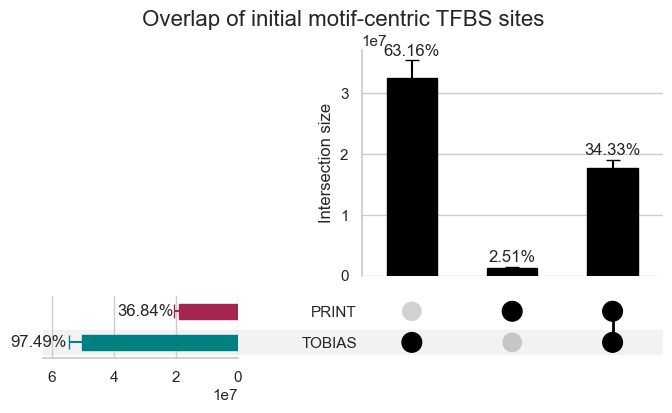

In [10]:
fig = plt.figure(figsize=(8, 4))

upset = UpSet(df_all["mean"], 
              show_percentages="{:.2%}",
             element_size=None)
upset.style_categories("TOBIAS", bar_facecolor=color_scheme_prog["tobias"])
upset.style_categories("PRINT", bar_facecolor=color_scheme_prog["print"])
axes_dict = upset.plot(fig=fig)

#get bar chart x axis,
#add std bars
#move up percentages out of the way. 
bar_ax = axes_dict["intersections"]  # Get bar chart axis
bars = bar_ax.patches 
positions = [bar.get_x() + bar.get_width() / 2 for bar in bars]
heights = [bar.get_height() for bar in bars]
std_values = df_all.set_index("mean").loc[heights]["std"]
bar_ax.errorbar(positions, heights, yerr=std_values, fmt='none', ecolor='black', capsize=5, linewidth=1.5)
annotations = [text for text in bar_ax.texts]
for i, up in zip(annotations, std_values):
    i.set_y(i.get_position()[1] + up)
    
    
# get side bar chart x axis,
# add std bars
# move up percentages out of the way.
bar_ax = axes_dict["totals"] 
bar_ax.set_xlim(sum_df.loc[0]["mean"] + sum_df.loc[0]["sd"]*3, 0)
annotations = [text for text in bar_ax.texts]
for rect, anno in zip(bar_ax.patches, annotations):
    v = anno.get_position()
    newx, newsd, name = sum_df.loc[v[1]][["mean","sd","index"]]

    bar_ax.errorbar(rect.get_width(), v[1], xerr=newsd, 
                    fmt='none', ecolor=color_scheme_prog[name], 
                    capsize=5, linewidth=1.5)
    anno.set_x(newx+newsd*1.2)
    
    
plt.suptitle("Overlap of initial motif-centric TFBS sites", fontsize=16)
plt.show()

TOBIAS  PRINT
True    True     15882593
        False    28343488
False   True      1219075
Name: value, dtype: int64

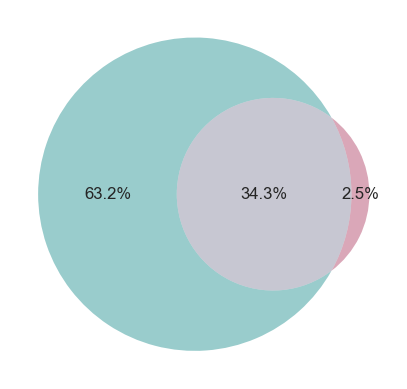

In [11]:

df = res_dict[cl]
display(df)
venn2(subsets = (df_all.loc[(True,False)]["mean"], 
                 df_all.loc[(False,True)]["mean"],
                 df_all.loc[(True,True)]["mean"]), 
      #set_labels = ('TOBIAS', 'PRINT'),
      set_labels = None,
      set_colors=(color_scheme_prog["tobias"], color_scheme_prog["print"]),
      subset_label_formatter=lambda x: f"{(x/df_all['mean'].sum())*100:.1f}%")

plt.show()

## 1.1 What if we match on PWM p-val? <a class="anchor" id="first1-bullet"></a>

In [10]:
def _standardize(file, region_array, pwm_array):
    df = pd.read_csv(file, sep="\t", index_col=0)

    df2 = df.pivot_table(index="region_atac", columns="motif", aggfunc='size', fill_value=0)
    df2 = df2.reindex(pwm_array, axis=1, fill_value=0)
    df2 = df2.reindex(region_array, axis=0, fill_value=0)
    if df.shape[0] == df2.sum().sum():
        return df2
    else: 
        print("ERROR")
        return

res_dict = {}

for cl in ["HEPG2", "K562"]:
    print(cl)
    
    #get indexes to pivot dataframes on, build them, and quality check
    region_array, pwm_array = _get_cellline_arrays(cl)
    
    #tobias
    f = f"../08_acrosstools/pwm_match_pval/{cl}-cellFilt.bed"
    tobias_mat = _standardize(f, region_array, pwm_array)
    f = f"../06_dataquality/print/cleaned/{cl}-cellFilt.bed"
    print_mat = _standardize(f, region_array, pwm_array)

    if not (tobias_mat.index.equals(print_mat.index)) and (tobias_mat.columns.equals(print_mat.columns)):
        print("ERROR")
    
    #flatten into 2 column df, remove all zero rows, 
    data = {'TOBIAS': tobias_mat.to_numpy().flatten(),
            'PRINT': print_mat.to_numpy().flatten()
           }
    df = pd.DataFrame(data)
    df_nonZero = df.loc[~(df==0).all(axis=1)].copy()

    df_nonZero.loc[:, 'common'] = df_nonZero.min(axis=1) #make column of common sites.
    df_nonZero["TOBIAS"] = df_nonZero["TOBIAS"]- df_nonZero['common'] #remove common values from each
    df_nonZero["PRINT"] = df_nonZero["PRINT"]- df_nonZero['common']
    
    upset_data = pd.Series(
        [df_nonZero["common"].sum(), df_nonZero["TOBIAS"].sum(), df_nonZero["PRINT"].sum()],
        index=pd.MultiIndex.from_tuples(
            [(True, True),
             (True, False),
             (False, True),
            ],
            names=['TOBIAS', 'PRINT']
        ),
        name='value'
        )
    
    res_dict[cl] = upset_data

print("done")

HEPG2
K562
done


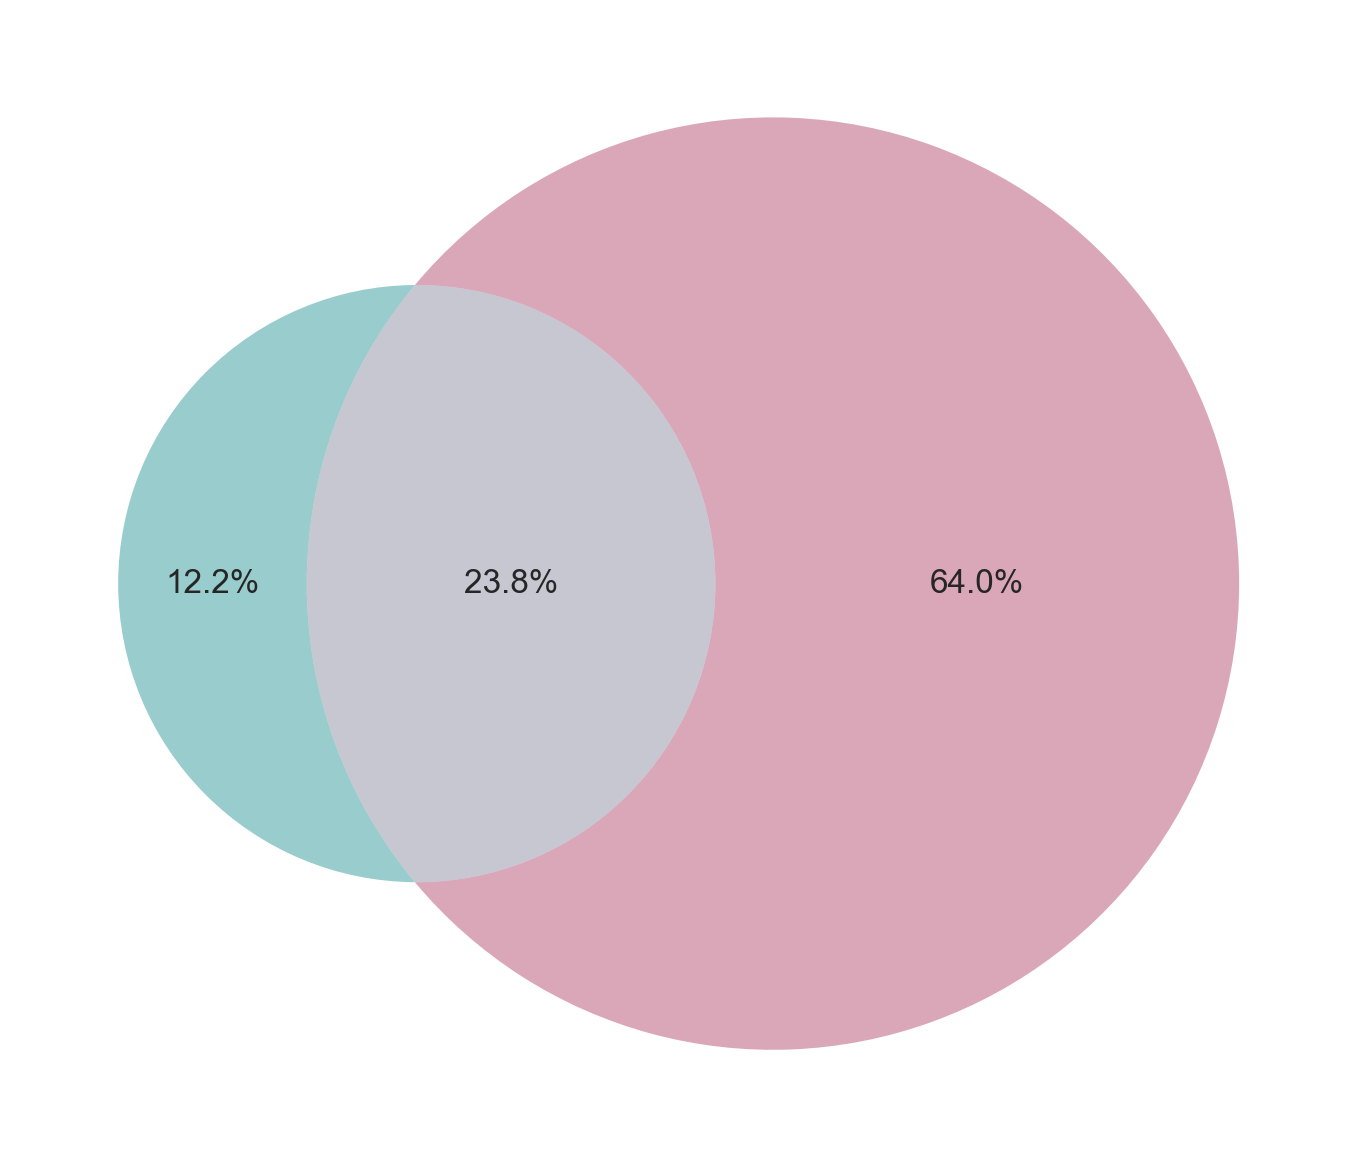

In [11]:
df_all = pd.concat([res_dict["HEPG2"], 
           res_dict["K562"]], axis=1)

df_all.columns = ["HEPG2", "K562"]
df_all["mean"] = df_all.mean(axis=1)
df_all["std"] = df_all.std(axis=1)
venn2(subsets = (df_all.loc[(True,False)]["mean"], 
                 df_all.loc[(False,True)]["mean"],
                 df_all.loc[(True,True)]["mean"]), 
      #set_labels = ('TOBIAS', 'PRINT'),
      set_labels = None,
      set_colors=(color_scheme_prog["tobias"], color_scheme_prog["print"]),
      subset_label_formatter=lambda x: f"{(x/df_all['mean'].sum())*100:.1f}%")
plt.show()


# 2. How many region-PWM pairs overlap <a class="anchor" id="second-bullet"></a>

In [12]:
def BuildUpsetData(df_nonZero):
    
    df = df_nonZero.copy()
    cols = df.columns.tolist()
    if len(cols) != 3:
        print("ERROR; can only handle 3"); return
    
    i = cols[0]
    j = cols[1]
    k = cols[2]
    
    #calculate those in common and then remove them. 
    df.loc[:, 'common'] = df.min(axis=1)
    df[i] = df[i]- df['common']
    df[j] = df[j]- df['common']
    df[k] = df[k]- df['common']
    
    #calculate the overlaps between them
    df.loc[:, f'{i}:{j}'] = np.where((df[i] != 0) & (df[j] != 0) & (df[k] ==0), df[[i, j]].min(axis=1), 0)
    df.loc[:, f'{i}:{k}'] = np.where((df[i] != 0) & (df[k] != 0) & (df[j] ==0), df[[i, k]].min(axis=1), 0)
    df.loc[:, f'{j}:{k}'] = np.where((df[j] != 0) & (df[k] != 0) & (df[i] ==0), df[[j, k]].min(axis=1), 0)

    #remove the ones above and the resulting entries are unique. 
    df[i] = df[i] - df[f'{i}:{j}'] - df[f'{i}:{k}']
    df[j] = df[j] - df[f'{i}:{j}'] - df[f'{j}:{k}']
    df[k] = df[k] - df[f'{i}:{k}'] - df[f'{j}:{k}']

    #check if they overlap. 
    o_total = df_nonZero.sum().sum()
    n_total = df[[i, j, k]].sum().sum() + \
        np.sum(df["common"]*3) + \
        np.sum(df[f"{i}:{j}"]*2) + \
        np.sum(df[f"{i}:{k}"] *2) + \
        np.sum(df[f"{j}:{k}"] *2)
    
    if o_total != n_total:
        print(f"Error: something went wrong, totals don't match o:{o_total}, n:{n_total}"); return 
    
    return df


def reformat(data):
    df = pd.DataFrame(data)
    df_nonZero = df.loc[~(df==0).all(axis=1)]
    data_sep = BuildUpsetData(df_nonZero)
    return data_sep


def check_identical(df1,df2,df3):
    val =  (df1.index.equals(df2.index)) and \
           (df1.index.equals(df3.index)) and \
           (df1.columns.equals(df2.columns)) and \
           (df1.columns.equals(df3.columns))
    return val
        

res = {}
core_dir = "../06_dataquality/"

for cl in ["HEPG2", "K562", "MCF7", "SKNSH"]:
    print(cl)
    hint_df =   pd.read_csv(f"{core_dir}/hint/mats/{cl}-cellFilt.mat", index_col=0)
    tobias_df = pd.read_csv(f"{core_dir}/tobias/mats/{cl}-cellFilt.mat", index_col=0)
    print_df =  pd.read_csv(f"{core_dir}/print/mats/{cl}-cellFilt.mat", index_col=0)
    
    if not check_identical(hint_df, tobias_df, print_df):
        print("ERROR"); break
    
    #all peaks
    data = {
    'HINT': hint_df.to_numpy().flatten(),
    'TOBIAS': tobias_df.to_numpy().flatten(),
    'PRINT': print_df.to_numpy().flatten()
    }
    res[f"{cl}:allpeaks"] = reformat(data)
     
    #peaks above a threshold
    peak_df = pd.read_csv(f"{core_dir}/tfbs_universe/PeakCoverage_{cl}.csv", index_col=0)
    keep_peaks = peak_df[peak_df[cl] >= 100].index
    data = {
    'HINT': hint_df.loc[keep_peaks].to_numpy().flatten(),
    'TOBIAS': tobias_df.loc[keep_peaks].to_numpy().flatten(),
    'PRINT': print_df.loc[keep_peaks].to_numpy().flatten()
    }
    res[f"{cl}:subpeaks"] = reformat(data)
    
    #TF-agnosic
    data = {
    'HINT': hint_df.sum(axis=1).to_numpy().flatten(),
    'TOBIAS': tobias_df.sum(axis=1).to_numpy().flatten(),
    'PRINT': print_df.sum(axis=1).to_numpy().flatten()
    }
    res[f"{cl}:tf-agnostic"] = reformat(data)
    
    
print(res.keys())

HEPG2
K562
MCF7
SKNSH
dict_keys(['HEPG2:allpeaks', 'HEPG2:subpeaks', 'HEPG2:tf-agnostic', 'K562:allpeaks', 'K562:subpeaks', 'K562:tf-agnostic', 'MCF7:allpeaks', 'MCF7:subpeaks', 'MCF7:tf-agnostic', 'SKNSH:allpeaks', 'SKNSH:subpeaks', 'SKNSH:tf-agnostic'])


In [13]:
overlaps = {}
for k, data_sep in res.items():
    val = (data_sep["common"].sum()/data_sep.sum().sum())*100
    overlaps[k] = val
    print(f"{k}:{val}")
    
for cond in ["allpeaks", "subpeaks", "tf-agnostic"]:
    tmp = np.array([overlaps[k] for k in overlaps if cond in k])
    print(f"{cond}: {round(tmp.mean(),2)}, {round(tmp.std(), 2)}")
    

HEPG2:allpeaks:3.4562334188864328
HEPG2:subpeaks:4.002131802844424
HEPG2:tf-agnostic:8.48629034132802
K562:allpeaks:3.624389305842299
K562:subpeaks:4.043906909246607
K562:tf-agnostic:8.713687641501387
MCF7:allpeaks:3.493362939514776
MCF7:subpeaks:4.232329037623487
MCF7:tf-agnostic:8.555088863447589
SKNSH:allpeaks:3.3623338013835555
SKNSH:subpeaks:3.3629017692044636
SKNSH:tf-agnostic:8.363076641789661
allpeaks: 3.48, 0.09
subpeaks: 3.91, 0.33
tf-agnostic: 8.53, 0.13


## show as Upset Plots

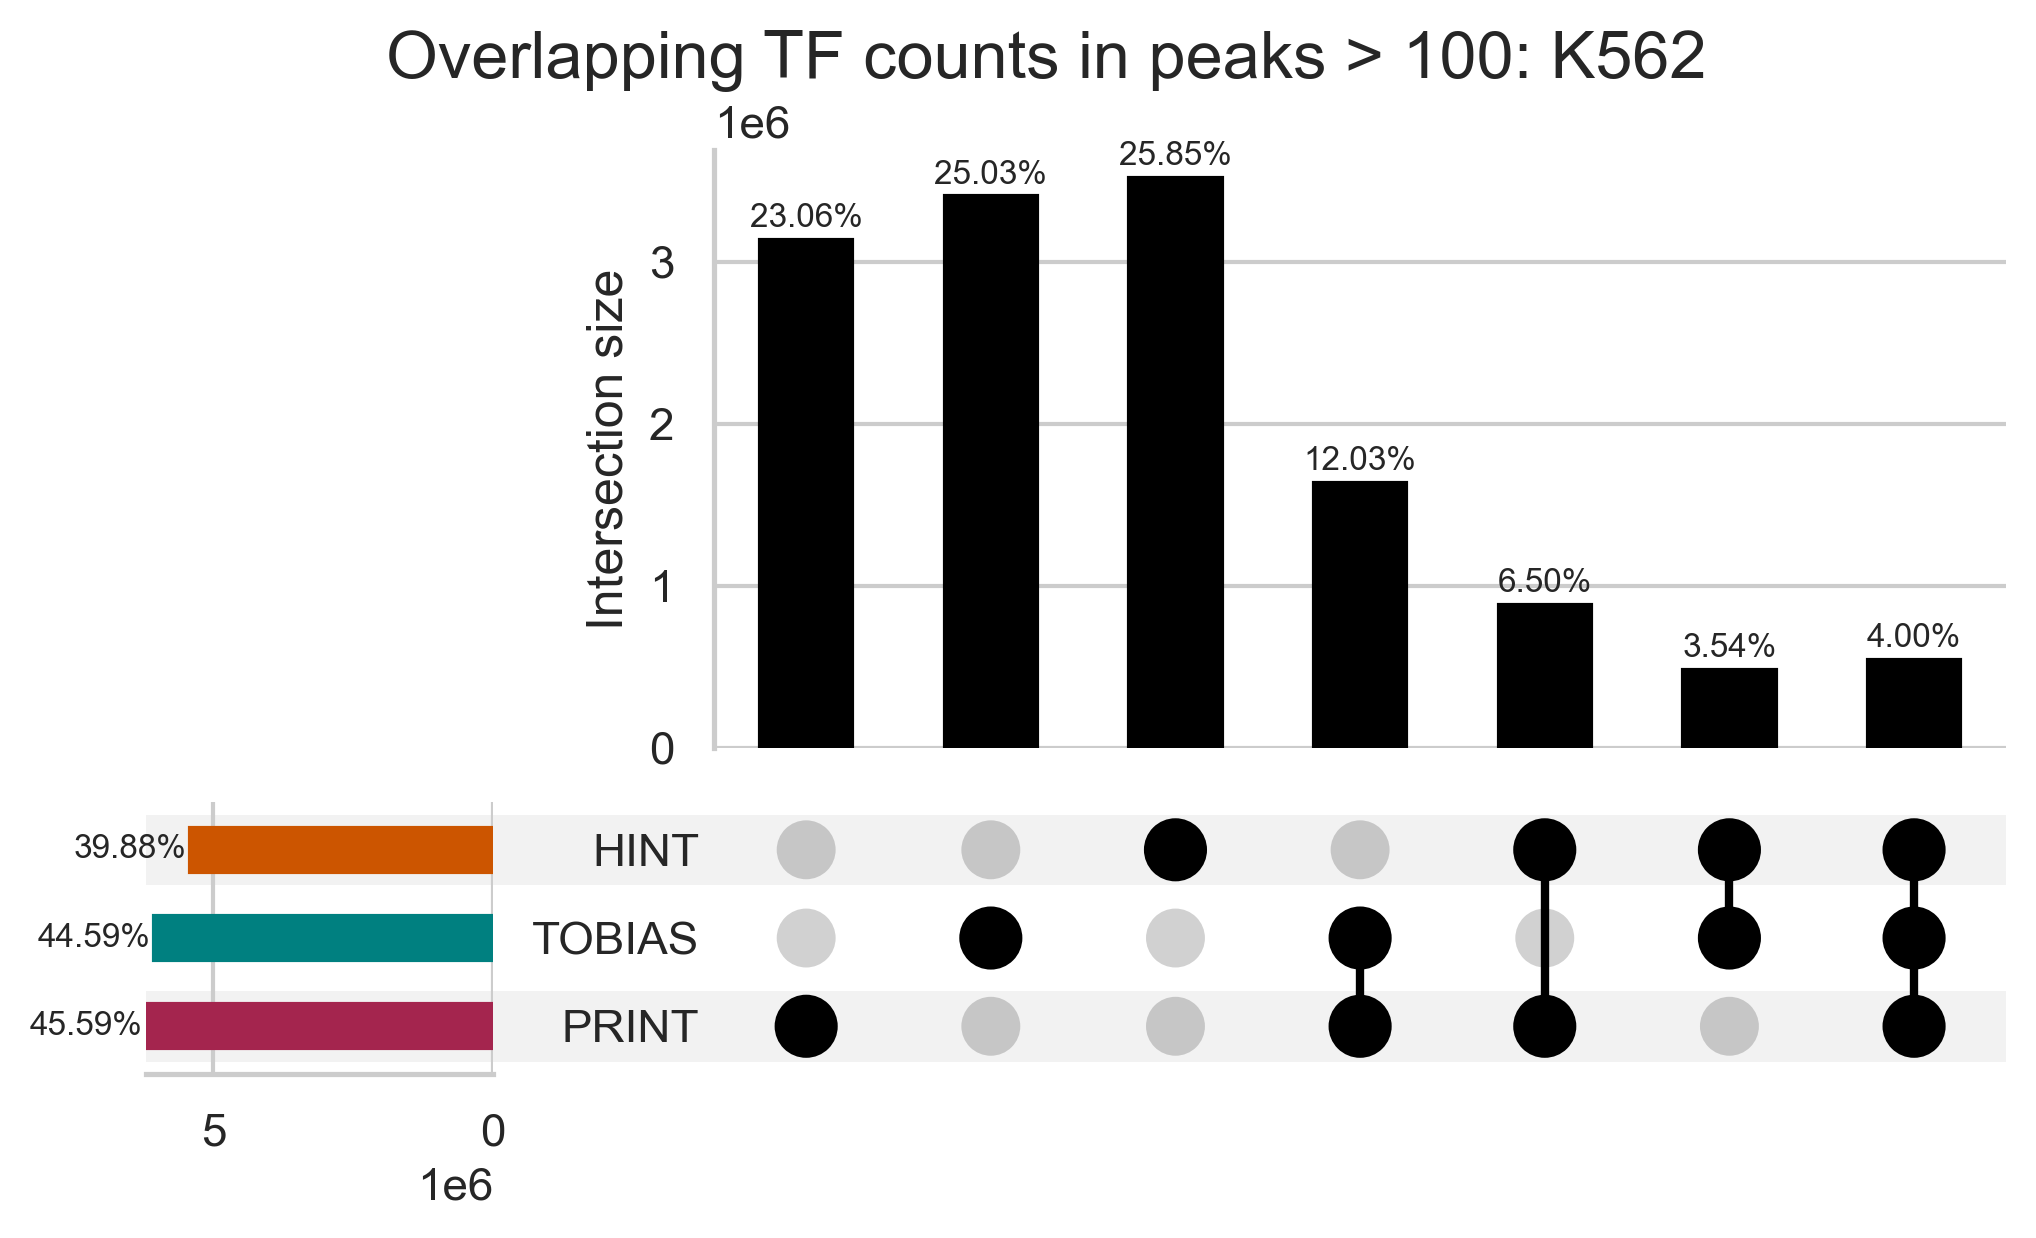

In [14]:
def reformatDF(df):
    upset_data = pd.Series(
        [df["common"].sum(), 
         df["HINT"].sum(), df["TOBIAS"].sum(), df["PRINT"].sum(), 
         df["HINT:TOBIAS"].sum(), df["HINT:PRINT"].sum(), df["TOBIAS:PRINT"].sum()],
        index=pd.MultiIndex.from_tuples(
            [
                (True, True, True),
                (True, False, False),
                (False, True, False),
                (False, False, True),
                (True, True, False),
                (True, False, True),
                (False, True, True),  
            ],
            names=['HINT', 'TOBIAS', 'PRINT']
        ),
        name='value'
    )
    return upset_data

matplotlib.rcParams["font.size"] = 8
fig = plt.figure(figsize=(8, 4))

upset = UpSet(reformatDF(res["HEPG2:subpeaks"]), 
              show_percentages="{:.2%}",
             element_size=None)
upset.style_categories("HINT", bar_facecolor=color_scheme_prog["hint"])
upset.style_categories("TOBIAS", bar_facecolor=color_scheme_prog["tobias"])
upset.style_categories("PRINT", bar_facecolor=color_scheme_prog["print"])
upset.plot(fig=fig)
plt.suptitle("Overlapping TF counts in peaks > 100: K562", fontsize=16)
plt.show()

In [15]:
df_all = pd.DataFrame([reformatDF(res["HEPG2:subpeaks"]), 
                       reformatDF(res["K562:subpeaks"]),
                       reformatDF(res["MCF7:subpeaks"]),
                       reformatDF(res["SKNSH:subpeaks"])]).T

df_all.columns = ["HEPG2", "K562", "MCF7", "SKNSH"]
df_all["mean"] = df_all.mean(axis=1)
df_all["std"] = df_all.std(axis=1)
display(df_all)

HEPG2     K562     MCF7    SKNSH        mean  \
HINT  TOBIAS PRINT                                                   
True  True   True    544130   593880   545606   528960   553144.00   
      False  False  3514175  4103354  2413177  4995076  3756445.50   
False True   False  3402966  3823420  3526092  4360699  3778294.25   
      False  True   3135865  3046137  3239316  2887161  3077119.75   
True  True   False   480677   511978   422129   506284   480267.00   
      False  True    883135   817406   869420   806338   844074.75   
False True   True   1635056  1789623  1875649  1644755  1736270.75   

                              std  
HINT  TOBIAS PRINT                 
True  True   True    24404.718765  
      False  False  937765.466570  
False True   False  369360.561068  
      False  True   129231.270800  
True  True   False   35576.210289  
      False  True    32800.035651  
False True   True   101109.244469

In [16]:
tmp = {}
for cl in df_all.index.names:
    l = df_all[df_all.index.get_level_values(cl) == True].sum()
    tmp[cl.lower()] = [round(l.loc[["HEPG2", "K562", "MCF7", "SKNSH"]].mean()),
               round(l.loc[["HEPG2", "K562", "MCF7", "SKNSH"]].std())]
sum_df = pd.DataFrame.from_dict(tmp).T
sum_df.columns = ["mean", "sd"]
sum_df = sum_df.sort_values(by='mean', ascending=False).reset_index()
display(sum_df)

,index,mean,sd
0,tobias,6547976,423958
1,print,6210609,271666
2,hint,5633931,1089337


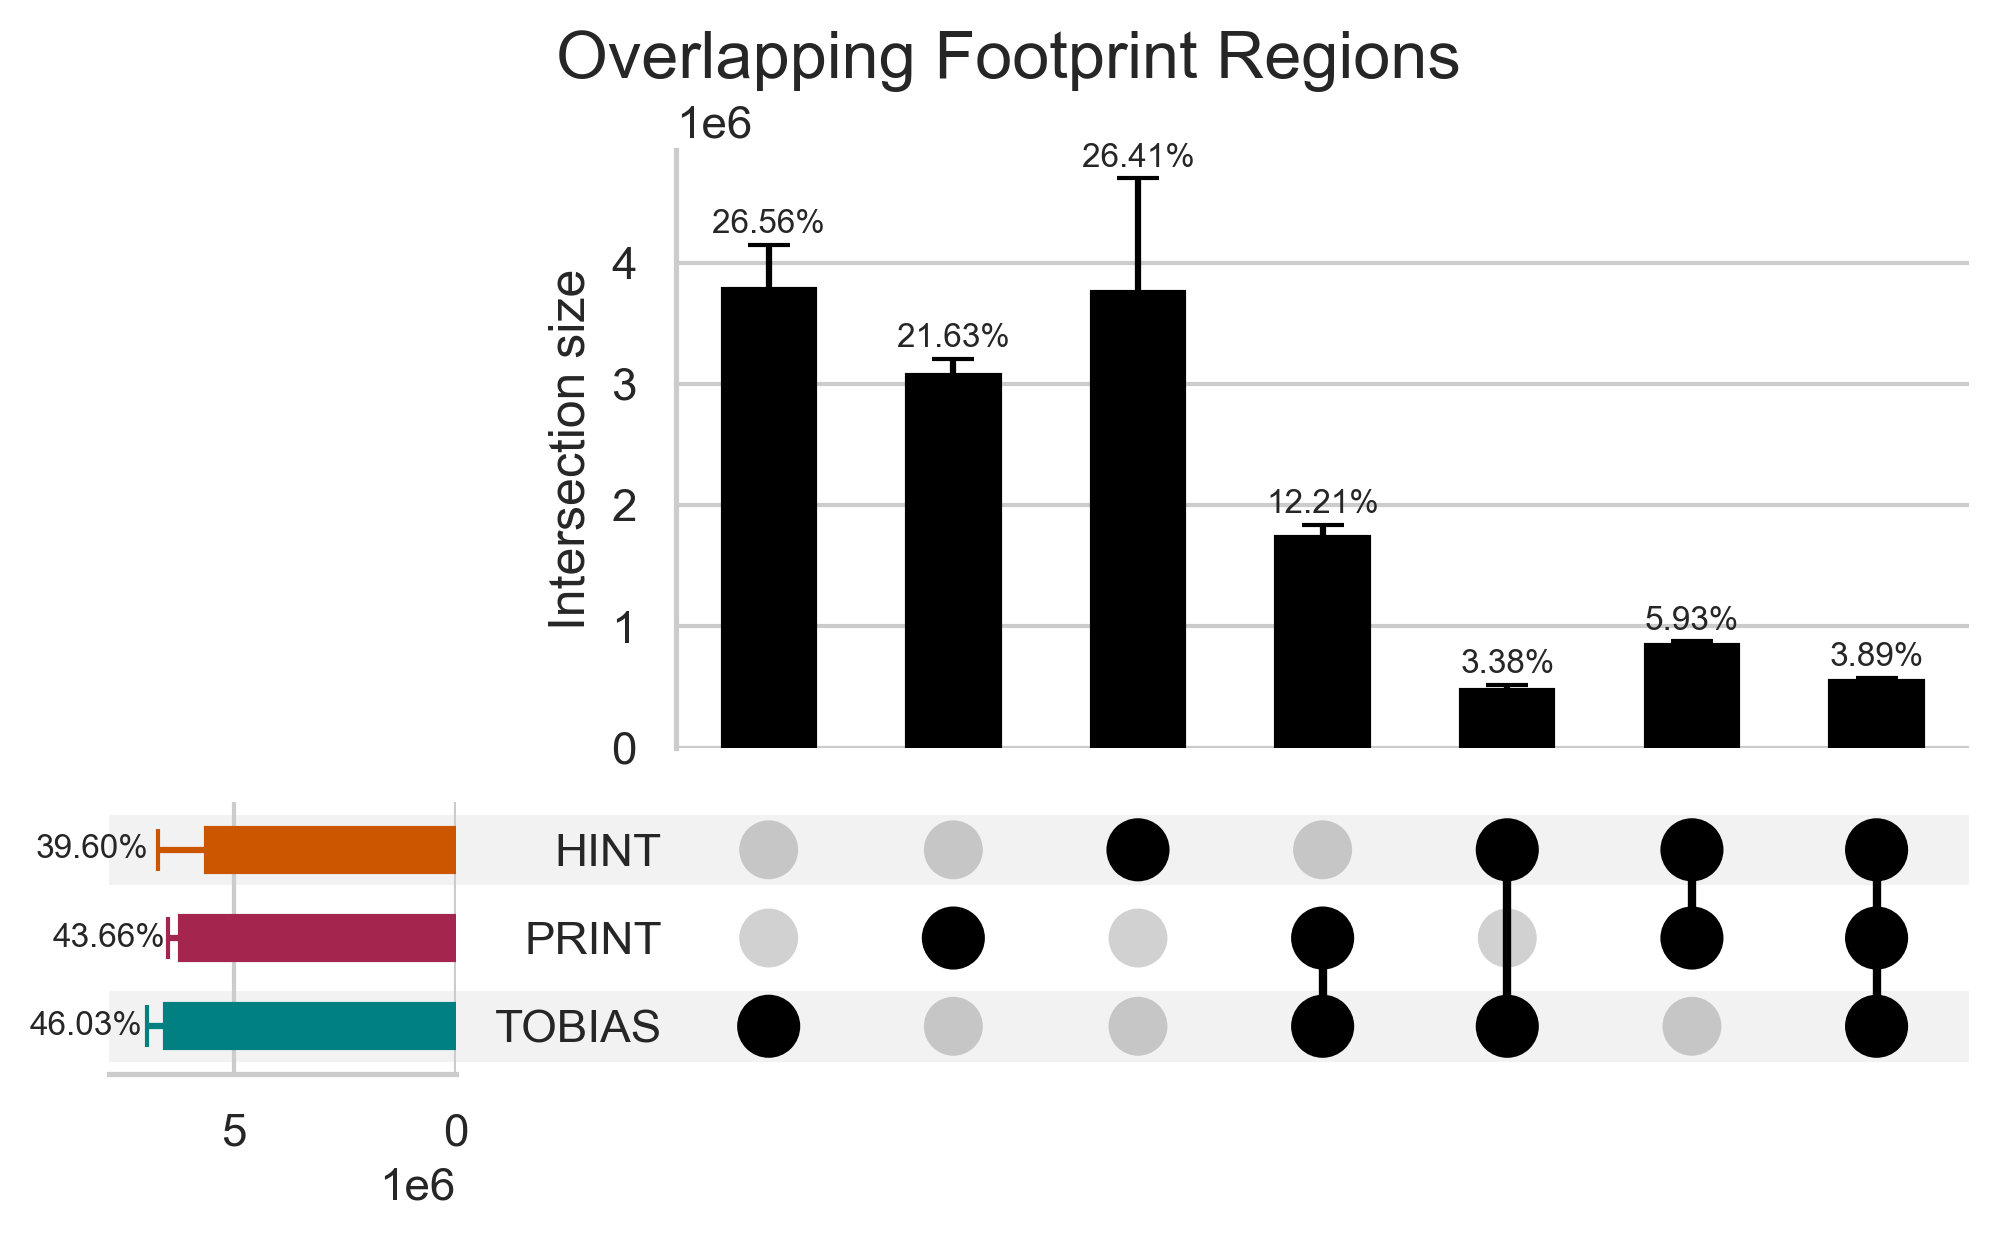

In [17]:
fig = plt.figure(figsize=(8, 4))

upset = UpSet(df_all["mean"], 
              show_percentages="{:.2%}",
             element_size=None)
             #subset_size="sum", show_counts=True)
upset.style_categories("HINT", bar_facecolor=color_scheme_prog["hint"])
upset.style_categories("TOBIAS", bar_facecolor=color_scheme_prog["tobias"])
upset.style_categories("PRINT", bar_facecolor=color_scheme_prog["print"])
axes_dict = upset.plot(fig=fig)

#get bar chart x axis,
#add std bars
#move up percentages out of the way. 
bar_ax = axes_dict["intersections"]  # Get bar chart axis
bars = bar_ax.patches 
positions = [bar.get_x() + bar.get_width() / 2 for bar in bars]
heights = [bar.get_height() for bar in bars]
std_values = df_all.set_index("mean").loc[heights]["std"]
bar_ax.errorbar(positions, heights, yerr=std_values, fmt='none', ecolor='black', capsize=5, linewidth=1.5)
annotations = [text for text in bar_ax.texts]
for i, up in zip(annotations, std_values):
    i.set_y(i.get_position()[1] + up)
    
    
#get side bar chart x axis,
#add std bars
#move up percentages out of the way.
bar_ax = axes_dict["totals"] 
bar_ax.set_xlim(sum_df.loc[0]["mean"] + sum_df.loc[0]["sd"]*3, 0)
annotations = [text for text in bar_ax.texts]
for rect, anno in zip(bar_ax.patches, annotations):
    v = anno.get_position()
    newx, newsd, name = sum_df.loc[v[1]][["mean","sd","index"]]

    bar_ax.errorbar(rect.get_width(), v[1], xerr=newsd, 
                    fmt='none', ecolor=color_scheme_prog[name], 
                    capsize=5, linewidth=1.5)
    anno.set_x(newx+newsd*1.2)
    
    
plt.savefig("../12_manuscript_figures/svg/Fig3_upset.svg")
plt.savefig("../12_manuscript_figures/pdf/Fig3_upset.pdf", bbox_inches='tight')

plt.suptitle("Overlapping Footprint Regions", fontsize=16)
plt.show()

# 2. How similar are scoring systems? <a class="anchor" id="third-bullet"></a>

## 2.1 TOBIAS bound threshold <a class="anchor" id="third1-bullet"></a>

In [16]:
infile="../08_acrosstools/tobias_thresholds.txt"
thresh_file = pd.read_csv(infile, sep=" ", header=None, names=["file", "threshold"])

In [17]:
##### FORMAT STANDARD FILES #####
normal = thresh_file.loc[~thresh_file.file.str.contains("combo|cellFilt", regex=True)].copy()
normal[["cell_line", "tmp", "seed"]] = normal.file.str.split('_', expand=True)
normal["group"] = [s[:1] for s in normal["tmp"]]
normal["value"] = [s[1:] for s in normal["tmp"]]
normal.loc[normal.group == "f", "value"] = [f"0.{i[1:]}" for i in normal.loc[normal.group == "f"]["value"]]
normal = normal[["cell_line", "value","group", "threshold"]]
normal[["value"]] = normal[["value"]].apply(pd.to_numeric)
normal["type"] = "normal"
#display(normal)

In [18]:
##### FORMAT BASELINE  #####
baseline = thresh_file.loc[thresh_file.file.str.contains("cellFilt")].copy()
baseline[["cell_line", "tmp"]] = baseline.file.str.split('-', expand=True)


baseline_info = pd.read_csv("../04_downsampling/sampling_stats.csv", sep=",", index_col=0)
baseline_info = baseline_info[baseline_info.sampling_type == "baseline"]
baseline_info["cell_line"] = [re.sub(".summary.txt" , "", x) for x in baseline_info.cell_line]
baseline_info[["file"]] = "baseline"

tmp = baseline_info[["cell_line", "Ncells"]].copy()
tmp.columns = ["cell_line", "value"]; tmp[["group"]] = "c"
add1 = baseline[["cell_line", "threshold"]].merge(tmp, on="cell_line", how="left")

tmp = baseline_info[["cell_line", "Nreadpairs"]].copy()
tmp.columns = ["cell_line", "value"]; tmp[["group"]] = "r"
add2 = baseline[["cell_line", "threshold"]].merge(tmp, on="cell_line", how="left")

tmp = baseline_info[["cell_line", "FRIP"]].copy()
tmp.columns = ["cell_line", "value"]; tmp[["group"]] = "f"
add3 = baseline[["cell_line", "threshold"]].merge(tmp, on="cell_line", how="left")

baseline = pd.concat([add1,add2, add3])
baseline[["value"]] = baseline[["value"]].apply(pd.to_numeric)
baseline["type"] = "baseline"
#display(baseline)

In [19]:
##### FORMAT COMBOS  #####
combos = thresh_file.loc[thresh_file.file.str.contains("combo")].copy()
combos["ComboID"] = combos.file.str.split('_', expand=True)[1].astype(int)

baseline_info = pd.read_csv("../04_downsampling/sampling_stats_cellsim.csv", sep=",")
baseline_info[["group"]] = "cs"


combos = combos.merge(baseline_info, left_on="ComboID", right_on="ComboID", how="outer")
combos["type"] = "combos"
#display(combos)

In [20]:
thresh_df = pd.concat([baseline, normal, combos]) 
display(thresh_df)

,cell_line,threshold,value,group,type,file,ComboID,Npeakpairs,mean_pearson_corr,sse_pearson_corr,...,dominant_cell_line_perc,closest_cell_line,cell_line_dist,Ncells,dist_to_*,sampling_type,filename,Nreadpairs,Nnonpeakpairs,FRIP
0,GM12878,0.02951,30246.0,c,baseline,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HEPG2,0.18492,25043.0,c,baseline,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,K562,0.13426,48060.0,c,baseline,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MCF7,0.19234,32303.0,c,baseline,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,SKNSH,0.16365,60714.0,c,baseline,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,NaN,0.01115,200000000.0,cs,combos,combo_61_TOBIAS.qsub.sh.o2311190,61.0,200044819.0,0.599969,0.012166,...,100.000000,GM12878,0.225203,19500.0,MCF7,cell_sim,combo_61.bam,9.178922e+08,717847348.0,0.217939
76,NaN,0.01916,200000000.0,cs,combos,combo_62_TOBIAS.qsub.sh.o2311191,62.0,200046531.0,0.342354,0.029086,...,32.631579,GM12878,0.606731,19000.0,HEPG2,cell_sim,combo_62.bam,1.013251e+09,813204688.0,0.197430
77,NaN,0.01299,200000000.0,cs,combos,combo_63_TOBIAS.qsub.sh.o2311192,63.0,200092114.0,0.435195,0.040165,...,61.176471,PC9,0.492815,17000.0,HEPG2,cell_sim,combo_63.bam,1.035843e+09,835750873.0,0.193168
78,NaN,0.01335,200000000.0,cs,combos,combo_64_TOBIAS.qsub.sh.o2311193,64.0,200380485.0,0.463882,0.037845,...,72.777778,CALU3,0.348167,18000.0,K562,cell_sim,combo_64.bam,1.034169e+09,833788375.0,0.193760


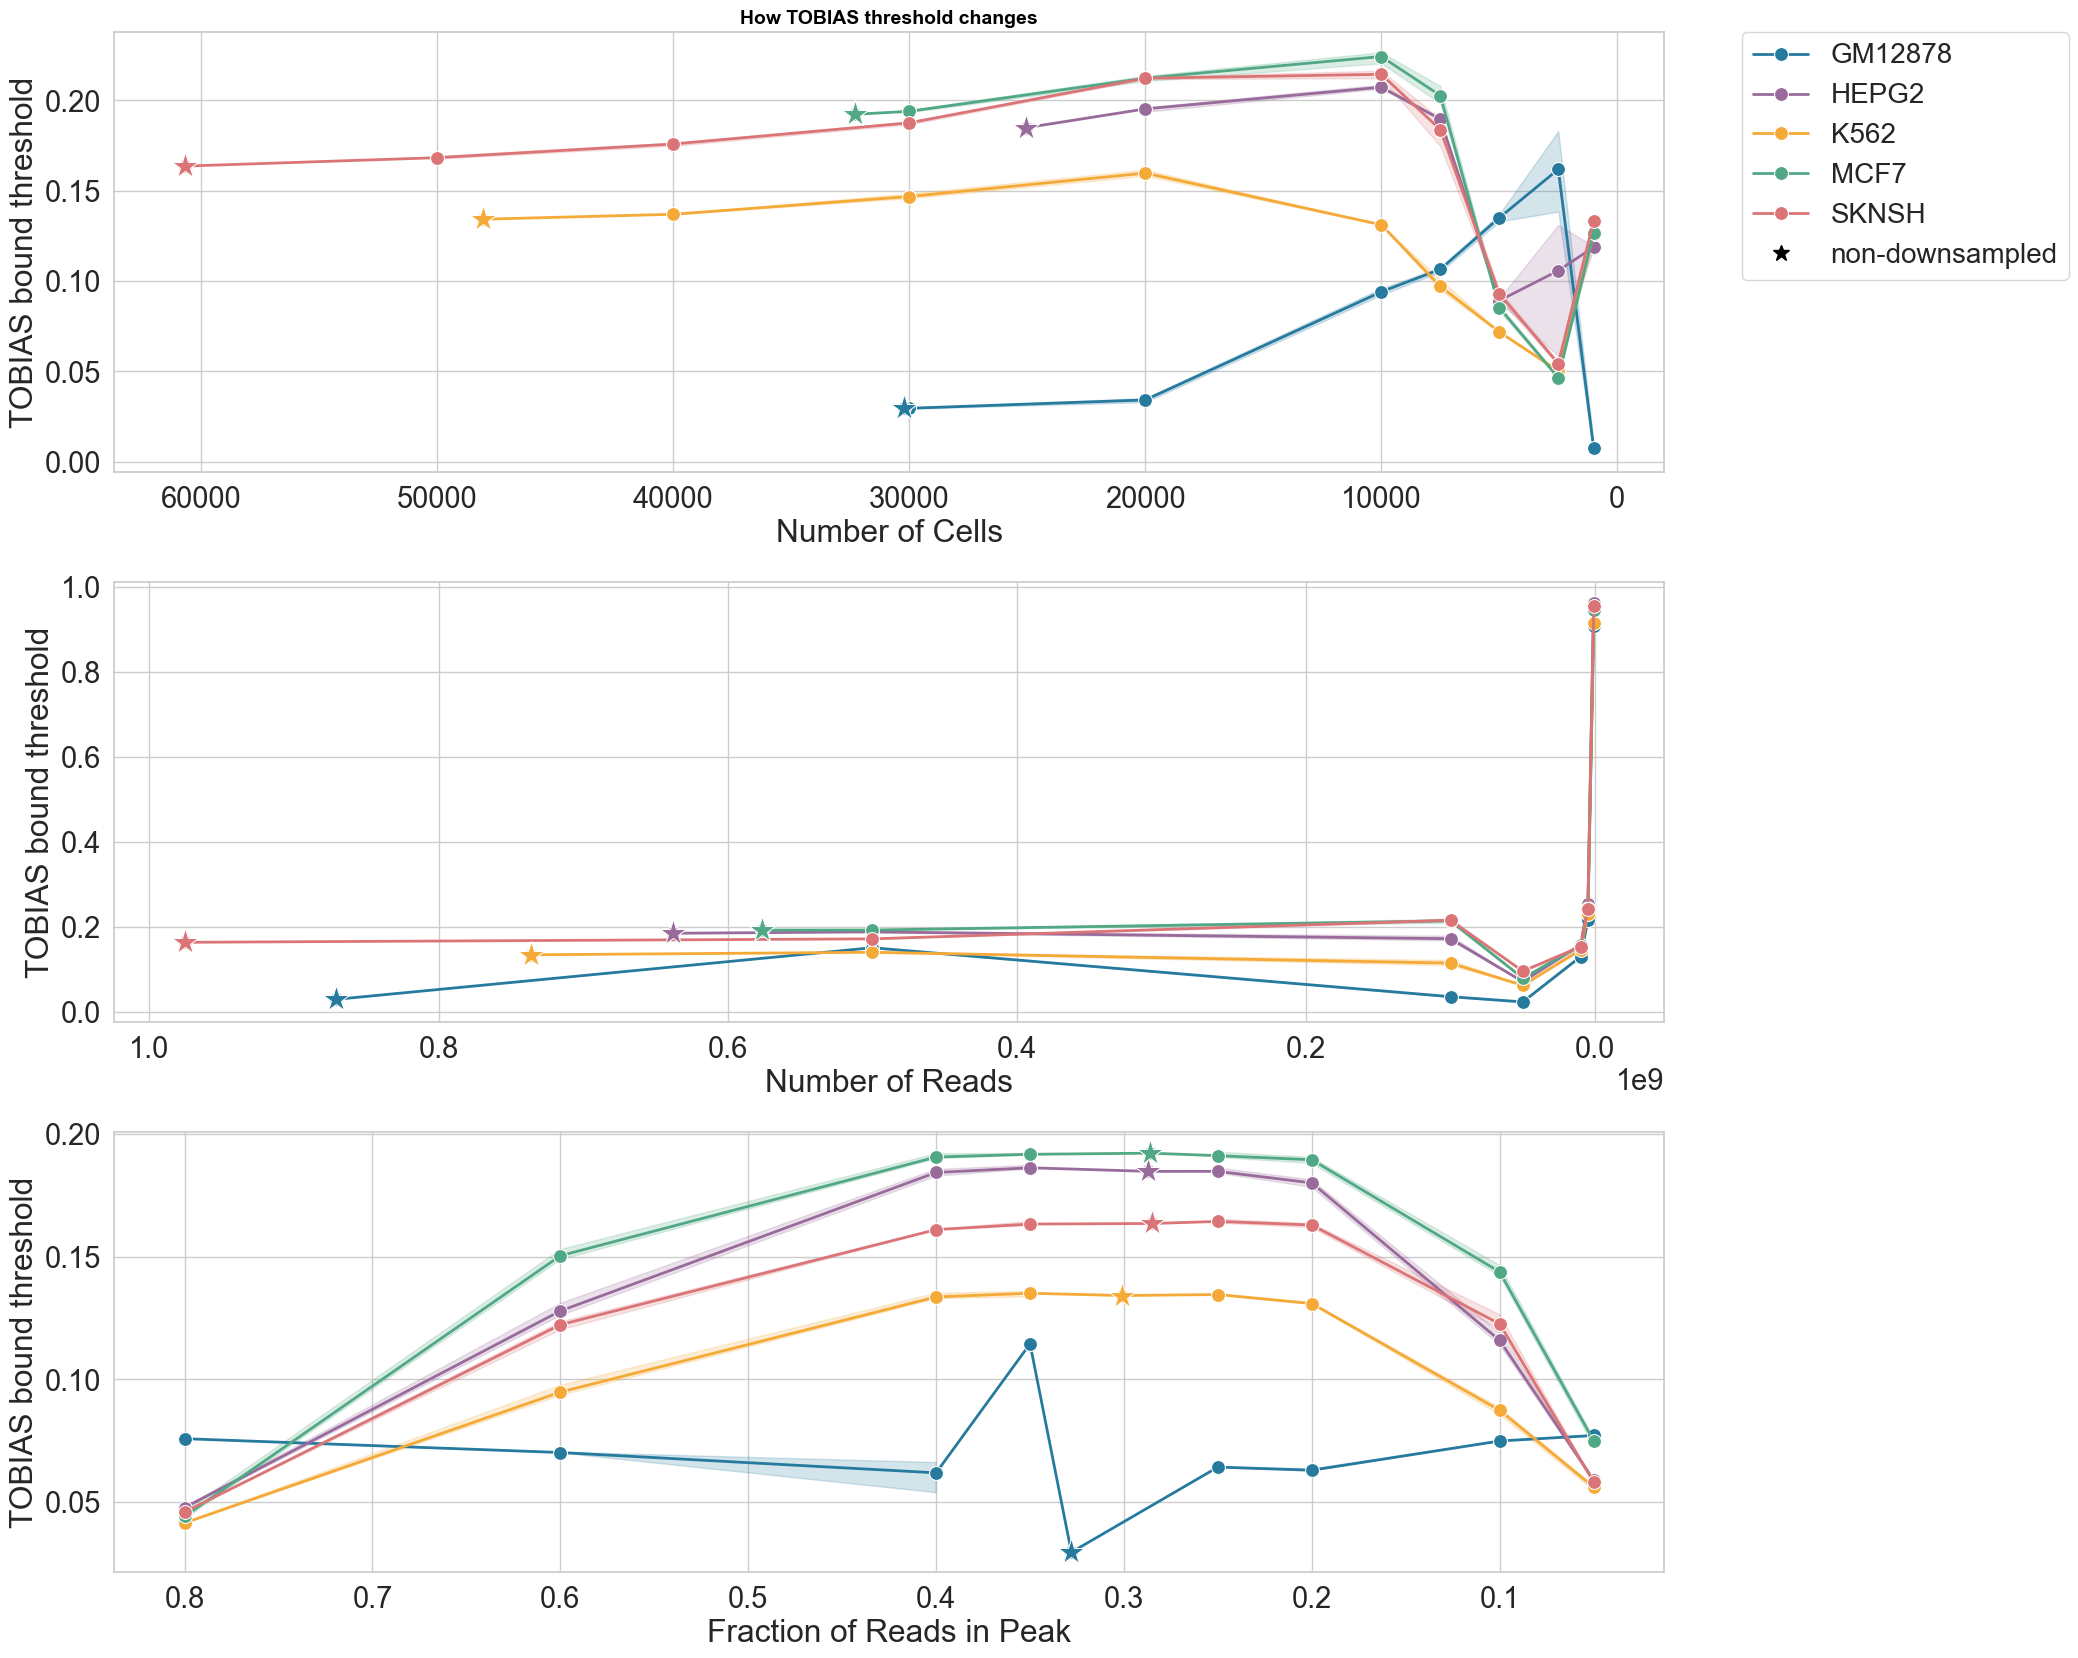

In [21]:
sns.set(font_scale=1.9, style='whitegrid')
fig = plt.figure(figsize=(20, 20))
gs = GridSpec(3, 1, figure=fig, wspace=0.25, hspace=0.25)

ax = fig.add_subplot(gs[0])
tmp = thresh_df[thresh_df.group=="c"].copy()
g = sns.lineplot(data=tmp, 
                 x="value", y="threshold", hue="cell_line",
                 marker="o", linewidth=2, ax=ax, markersize=10, palette=color_scheme_cl)
g = sns.lineplot(data=tmp[tmp.type=="baseline"], 
                 x="value", y="threshold", hue="cell_line",
                 marker="*", ax=ax, markersize=20, palette=color_scheme_cl, legend=False)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
ax.invert_xaxis()
ax.set_xlabel("Number of Cells")
ax.set_ylabel("TOBIAS bound threshold")
ax.set_title("How TOBIAS threshold changes", fontsize=14, color='black', weight='bold')

handles, labels = ax.get_legend_handles_labels() 
star_legend = Line2D([0], [0], color='black', marker='*', linestyle='None', markersize=12)
handles.append(star_legend)
labels.append('non-downsampled')
ax.legend(handles=handles, labels=labels,bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, prop={"size":20})


ax = fig.add_subplot(gs[1])
tmp = thresh_df[thresh_df.group=="r"].copy()
g = sns.lineplot(data=tmp, 
                 x="value", y="threshold", hue="cell_line",
                 marker="o", linewidth=2, ax=ax, markersize=10, palette=color_scheme_cl)
g = sns.lineplot(data=tmp[tmp.type=="baseline"], 
                 x="value", y="threshold", hue="cell_line",
                 marker="*", ax=ax, markersize=20, palette=color_scheme_cl, legend=False)
ax.invert_xaxis()
ax.set_xlabel("Number of Reads")
ax.set_ylabel("TOBIAS bound threshold")
ax.get_legend().remove()


ax = fig.add_subplot(gs[2])
tmp = thresh_df[thresh_df.group=="f"].copy()
g = sns.lineplot(data=tmp, 
                 x="value", y="threshold", hue="cell_line",
                 marker="o", linewidth=2, ax=ax, markersize=10, palette=color_scheme_cl)
g = sns.lineplot(data=tmp[tmp.type=="baseline"], 
                 x="value", y="threshold", hue="cell_line",
                 marker="*", ax=ax, markersize=20, palette=color_scheme_cl, legend=False)
ax.invert_xaxis()
ax.set_xlabel("Fraction of Reads in Peak")
ax.set_ylabel("TOBIAS bound threshold")
ax.get_legend().remove()

plt.show()

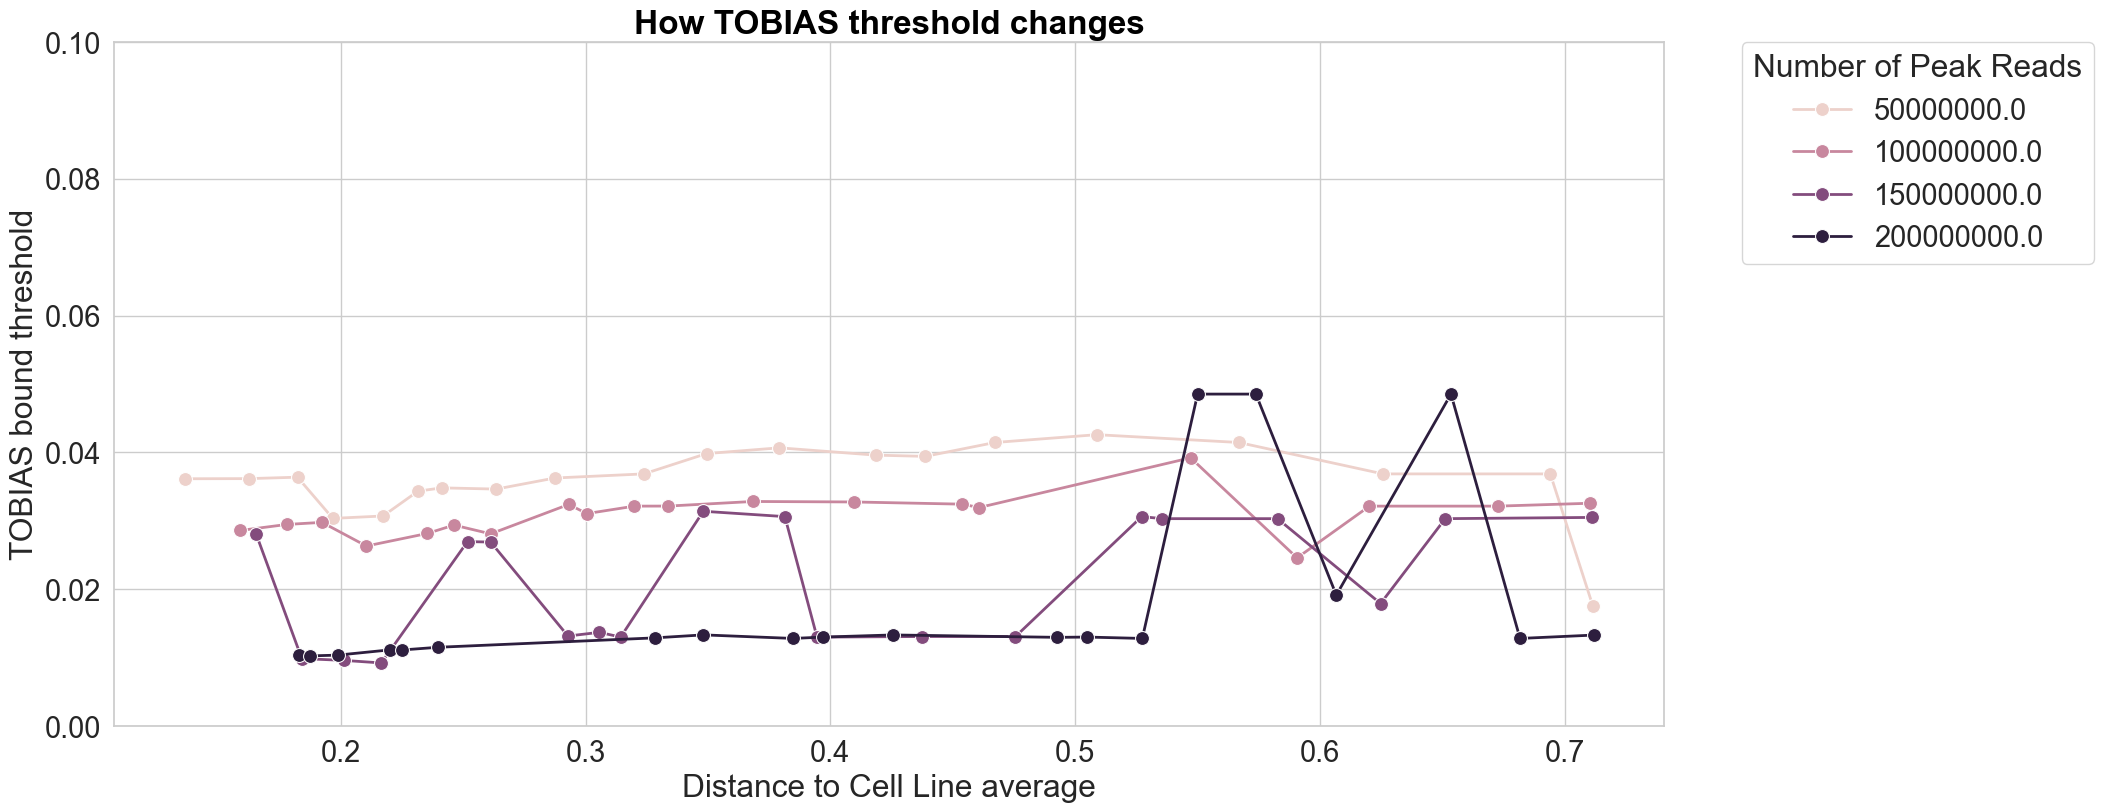

In [22]:
sns.set(font_scale=1.9, style='whitegrid')
fig = plt.figure(figsize=(20, 20))
gs = GridSpec(2, 1, figure=fig, wspace=0.25, hspace=0.25)

ax = fig.add_subplot(gs[0])
tmp = thresh_df[thresh_df.type=="combos"].copy()
tmp.dropna(subset=['value'], inplace=True)

g = sns.lineplot(data=tmp,
                 y="threshold", x="cell_line_dist", hue="value",
                 marker="o", linewidth=2, ax=ax, markersize=10)#, palette=color_scheme_cl)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, title="Number of Peak Reads")
#ax.invert_xaxis()
ax.set_xlabel("Distance to Cell Line average")
ax.set_ylim(0, 0.1)
ax.set_ylabel("TOBIAS bound threshold")
ax.set_title("How TOBIAS threshold changes", fontsize=24, color='black', weight='bold')

plt.show()

## 2.2 Jaccard of threshold pairs <a class="anchor" id="third2-bullet"></a>

In [25]:
##### MAKE THE MATS WITH DIFFERENT THRESHOLD LIMITS ##### 

def _process_chunk(args):
    cl, tool, all_tfs = args
    
    core_dir = "../06_dataquality/"
    out_dir = "../08_acrosstools/mats_by_score/"
    peak_file = f"../03_peakcalls/{cl}_filt_500bp.exclusion.bed"
    
    df = pd.read_csv(f"{peak_file}", header=None, sep="\t")
    df["region_atac"] = df[0].astype(str) + ":" + df[1].astype(str) + "-" + df[2].astype(str)
    all_atac_regions = df["region_atac"].tolist()
    
    df = pd.read_csv(f"{core_dir}/{tool}/cleaned/{cl}-cellFilt.bed", sep="\t")
    if tool == "hint": df["score"] = df["tag_count"]
    thresholds = np.quantile(df["score"], np.linspace(0,1,11))

    for t in thresholds:
        sub = df[df["score"] >= t]
        df_observed = sub.pivot_table(index="region_atac", columns="motif", aggfunc='size', fill_value=0)
        df_observed = df_observed.reindex(all_tfs, axis=1, fill_value=0)
        df_observed = df_observed.reindex(all_atac_regions, axis=0, fill_value=0)
        
        if sub.shape[0] == df_observed.sum().sum():
            df_observed.to_csv(f"{out_dir}/{tool}/{cl}_{round(t,4)}.mat", index=True)
        else:
            print(f"ERRORRRRR: {cl}: {t}")
    return


def main():
    from multiprocessing import Pool

    infile="../05_footprinting/program_input_files/jaspar2022_motifs_to_clusters.txt"
    TF_df = pd.read_csv(infile, sep=" ", header=None, usecols = [0], names=["motif"])
    TF_df["motif"] = [i.upper() for i in TF_df["motif"]] 
    all_tfs = TF_df["motif"].tolist()

    cell_lines = ["HEPG2", "K562", "MCF7", "SKNSH"]
    tools = ["hint", "tobias", "print"]

    tasks = [(cl, tool, all_tfs) for cl in cell_lines for tool in tools]

    with Pool(processes=12) as pool: 
        pool.map(_process_chunk, tasks)

    print("done")
    
#main()

In [26]:
##### CALCULATE METRICS FOR ALL PAIRWISE COMBINATIONS ##### 

def _calculate_jaccard(df):
    df["min"] = df.min(axis=1)
    u = df[["df1","df2"]].sum().sum()
    i = df["min"].sum()
    return i/u, (i/df["df1"].sum()*100), (i/df["df2"].sum()*100)

def _gather_metrics(df1, df2):
    data = {
    'df1': df1.to_numpy().flatten(),
    'df2': df2.to_numpy().flatten()
    }
    df = pd.DataFrame(data)
    df_nonZero = df.loc[~(df==0).all(axis=1)]
    df_nonZero.reset_index(drop=True, inplace=True)

    a,b,c = _calculate_jaccard(df_nonZero.copy())
    vals = [pearsonr(df_nonZero["df1"], df_nonZero["df2"])[0],
            spearmanr(df_nonZero["df1"], df_nonZero["df2"])[0],
            mean_squared_error(df_nonZero["df1"], df_nonZero["df2"]),
            a,b,c]
    
    return vals

def process_chunk(args):
    i, j, tool1, tool2 = args
    
    core_dir = "../08_acrosstools/mats_by_score/"
    df1 = pd.read_csv(f"{core_dir}/{tool1}/{i}", index_col=0)
    df2 = pd.read_csv(f"{core_dir}/{tool2}/{j}", index_col=0)
    totalA = df1.sum().sum()
    totalB = df2.sum().sum()
    info = [tool1, tool2, 
            re.sub(".mat", "", i.split("_")[1]), re.sub(".mat", "", j.split("_")[1]),
            totalA, totalB]
    
    if (totalA == 0) | (totalB == 0):
        info2 = [np.nan]*6
    else:
        info2 = _gather_metrics(df1, df2)
    return info + info2


def main():
    for cl in ["HEPG2"]:
        core_dir = "../08_acrosstools/mats_by_score/"
        files_hint = [x for x in os.listdir(f"{core_dir}/hint/") if cl in x ]
        files_tobias = [x for x in os.listdir(f"{core_dir}/tobias/") if cl in x ]
        files_print = [x for x in os.listdir(f"{core_dir}/print/") if cl in x ]

        combinations = list([i + ("hint", "tobias") for i in product(files_hint, files_tobias)] +
                            [i + ("hint", "print") for i in product(files_hint, files_print)] +
                            [i + ("tobias", "print") for i in product(files_tobias, files_print)])

        with Pool(processes=12) as pool:  
            results = pool.map(process_chunk, combinations)

    output_df = pd.DataFrame(results, columns=['tool1', 'tool2', 'thresh1', 'thresh2', "NumTFBS_a", "NumTFBS_b",
                                                'pearsonr', "spearmanr", "mse", "jaccard", "%a", "%b"])

    output_df.to_csv(f"{core_dir}/{cl}_metrics.csv", index=False)
    print("done")
#main()

In [27]:
core_dir = "../08_acrosstools/mats_by_score/"
df = pd.read_csv(f"{core_dir}/HEPG2_metrics.csv")
display(df)

print(np.unique(df[df.tool1=="hint"]["thresh1"]))
print(np.unique(df[df.tool1=="tobias"]["thresh1"]))
print(np.unique(df[df.tool2=="print"]["thresh2"]))

,tool1,tool2,thresh1,thresh2,NumTFBS_a,NumTFBS_b,pearsonr,spearmanr,mse,jaccard,%a,%b
0,hint,tobias,200088.000,0.0590,3,15117338,0.000485,0.000814,1.581986,1.984476e-07,100.000000,0.000020
1,hint,tobias,200088.000,0.0000,3,50385304,0.000289,0.000427,1.541055,5.954117e-08,100.000000,0.000006
2,hint,tobias,200088.000,0.2285,3,5038580,0.000681,0.001300,1.756218,5.954055e-07,100.000000,0.000060
3,hint,tobias,200088.000,39.3915,3,2,-1.000000,-1.000000,1.000000,0.000000e+00,0.000000,0.000000
4,hint,tobias,200088.000,0.0983,3,10077076,0.000549,0.000969,1.641993,2.977053e-07,100.000000,0.000030
...,...,...,...,...,...,...,...,...,...,...,...,...
358,tobias,print,0.029,0.0746,30234661,16927653,-0.020061,-0.210963,0.945784,2.394825e-01,37.356298,66.722481
359,tobias,print,0.029,0.5775,30234661,1880851,0.118376,0.080483,1.394504,5.457185e-02,5.796668,93.181384
360,tobias,print,0.029,0.1466,30234661,13165953,0.022393,-0.150618,0.995545,2.214414e-01,31.787008,72.996569
361,tobias,print,0.029,0.1114,30234661,15046803,-0.001868,-0.184996,0.967276,2.315386e-01,34.676784,69.678642


[1.40000e+01 1.82000e+02 2.16000e+02 2.52000e+02 2.98000e+02 3.63000e+02
 4.67000e+02 6.61000e+02 1.11900e+03 2.50400e+03 2.00088e+05]
[0.00000e+00 1.64000e-02 2.08000e-02 2.47000e-02 2.90000e-02 3.44000e-02
 4.28000e-02 5.90000e-02 9.83000e-02 2.28500e-01 3.93915e+01]
[0.     0.0746 0.1114 0.1466 0.1842 0.2276 0.2799 0.3467 0.4374 0.5775
 1.    ]


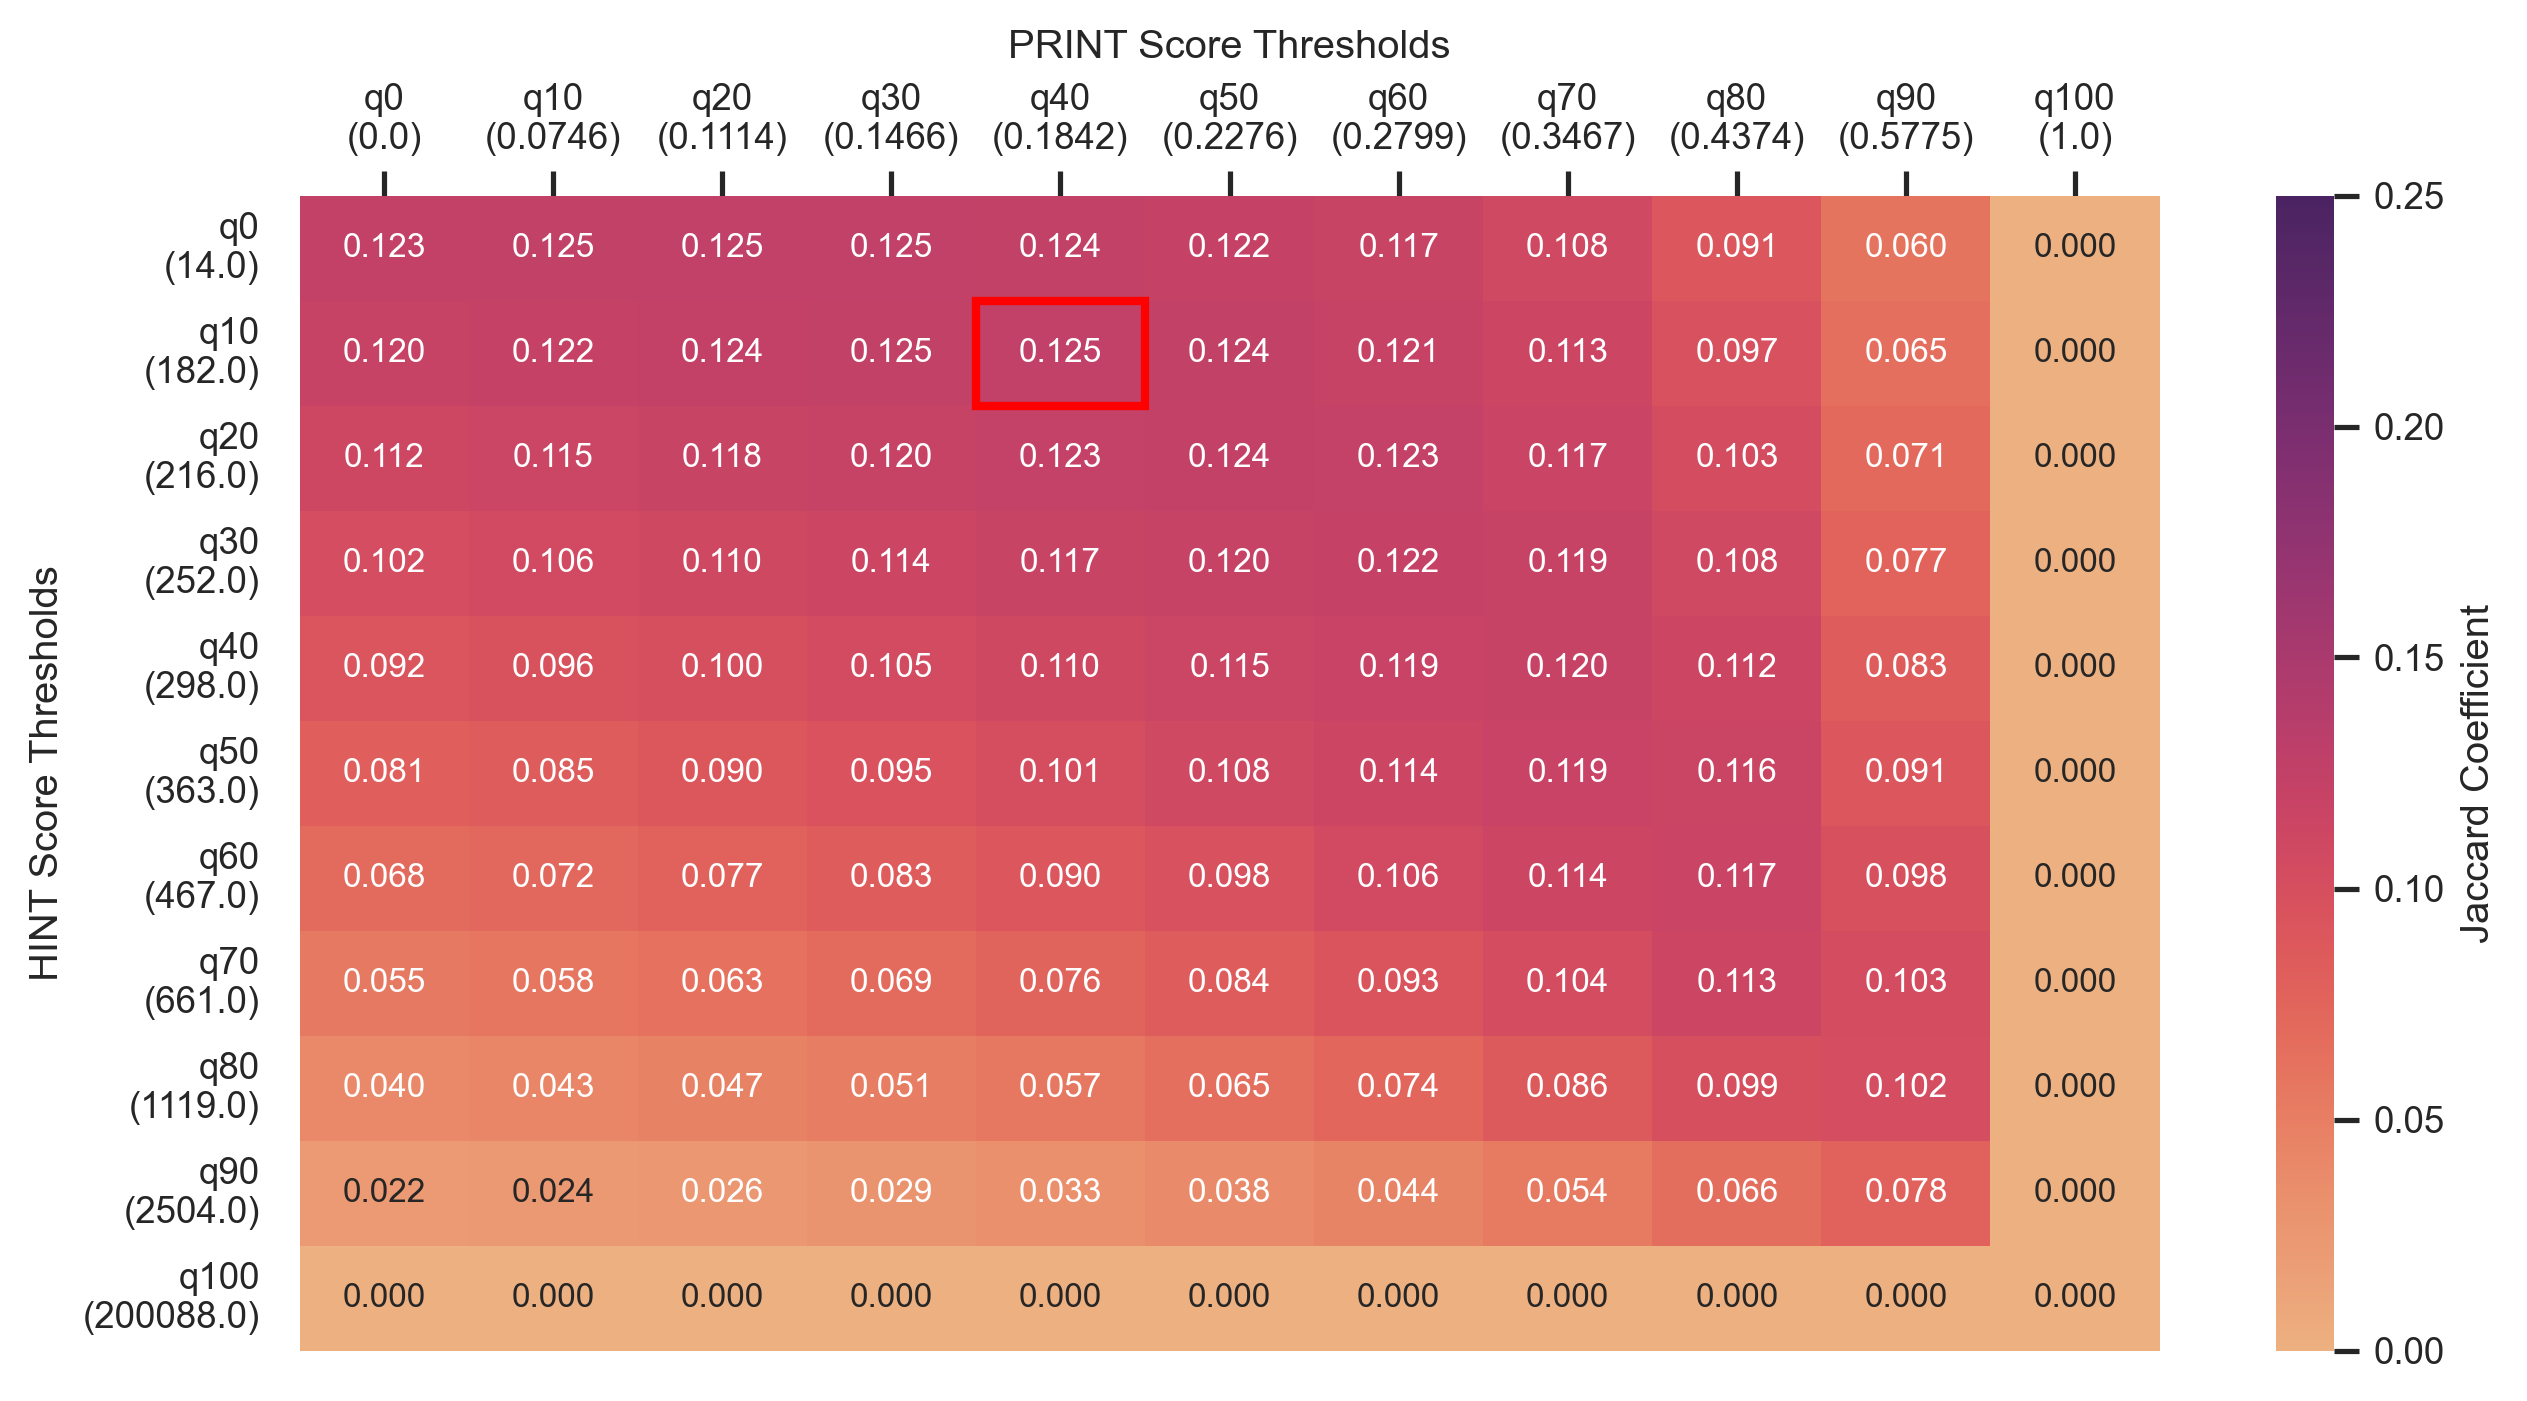

In [32]:
sns.set(font_scale=0.8, style='whitegrid')
fig = plt.figure(figsize=(10,5))
gs = GridSpec(1, 1, figure=fig, wspace=0.25, hspace=0.45)

ax = fig.add_subplot(gs[0])
a = "hint"
b = "print"
tmp = df[(df.tool1==a) & (df.tool2==b)]
v = "jaccard"
pivot_tmp = tmp.pivot_table(index='thresh1', columns='thresh2', values=v)
pivot_tmp.columns = [f"q{round(i*100)}\n({j})" for i,j in zip(np.linspace(0,1,11), pivot_tmp.columns)]
pivot_tmp.index = [f"q{round(i*100)}\n({j})" for i,j in zip(np.linspace(0,1,11), pivot_tmp.index)]

g = sns.heatmap(pivot_tmp,
            annot=True, fmt=".3f", cmap="flare",
            annot_kws={"size":8}, vmin=0, vmax=0.25, cbar=True)
cbar = g.collections[0].colorbar
cbar.set_label("Jaccard Coefficient")

max_row, max_col = pivot_tmp.values.argmax() // pivot_tmp.shape[1], pivot_tmp.values.argmax() % pivot_tmp.shape[1]
plt.gca().add_patch(plt.Rectangle((max_col, max_row), 1, 1, fill=False, edgecolor='red', lw=2))

ax.xaxis.tick_top()
ax.set_ylabel(f"{a.upper()} Score Thresholds")
ax.set_title(f"{b.upper()} Score Thresholds")

plt.savefig("../12_manuscript_figures/svg/FigS3_PRINTvHINT.svg")
plt.savefig("../12_manuscript_figures/png/FigS3_PRINTvHINT.png")
plt.savefig("../12_manuscript_figures/pdf/FigS3_PRINTvHINT.pdf", bbox_inches='tight')

plt.show()

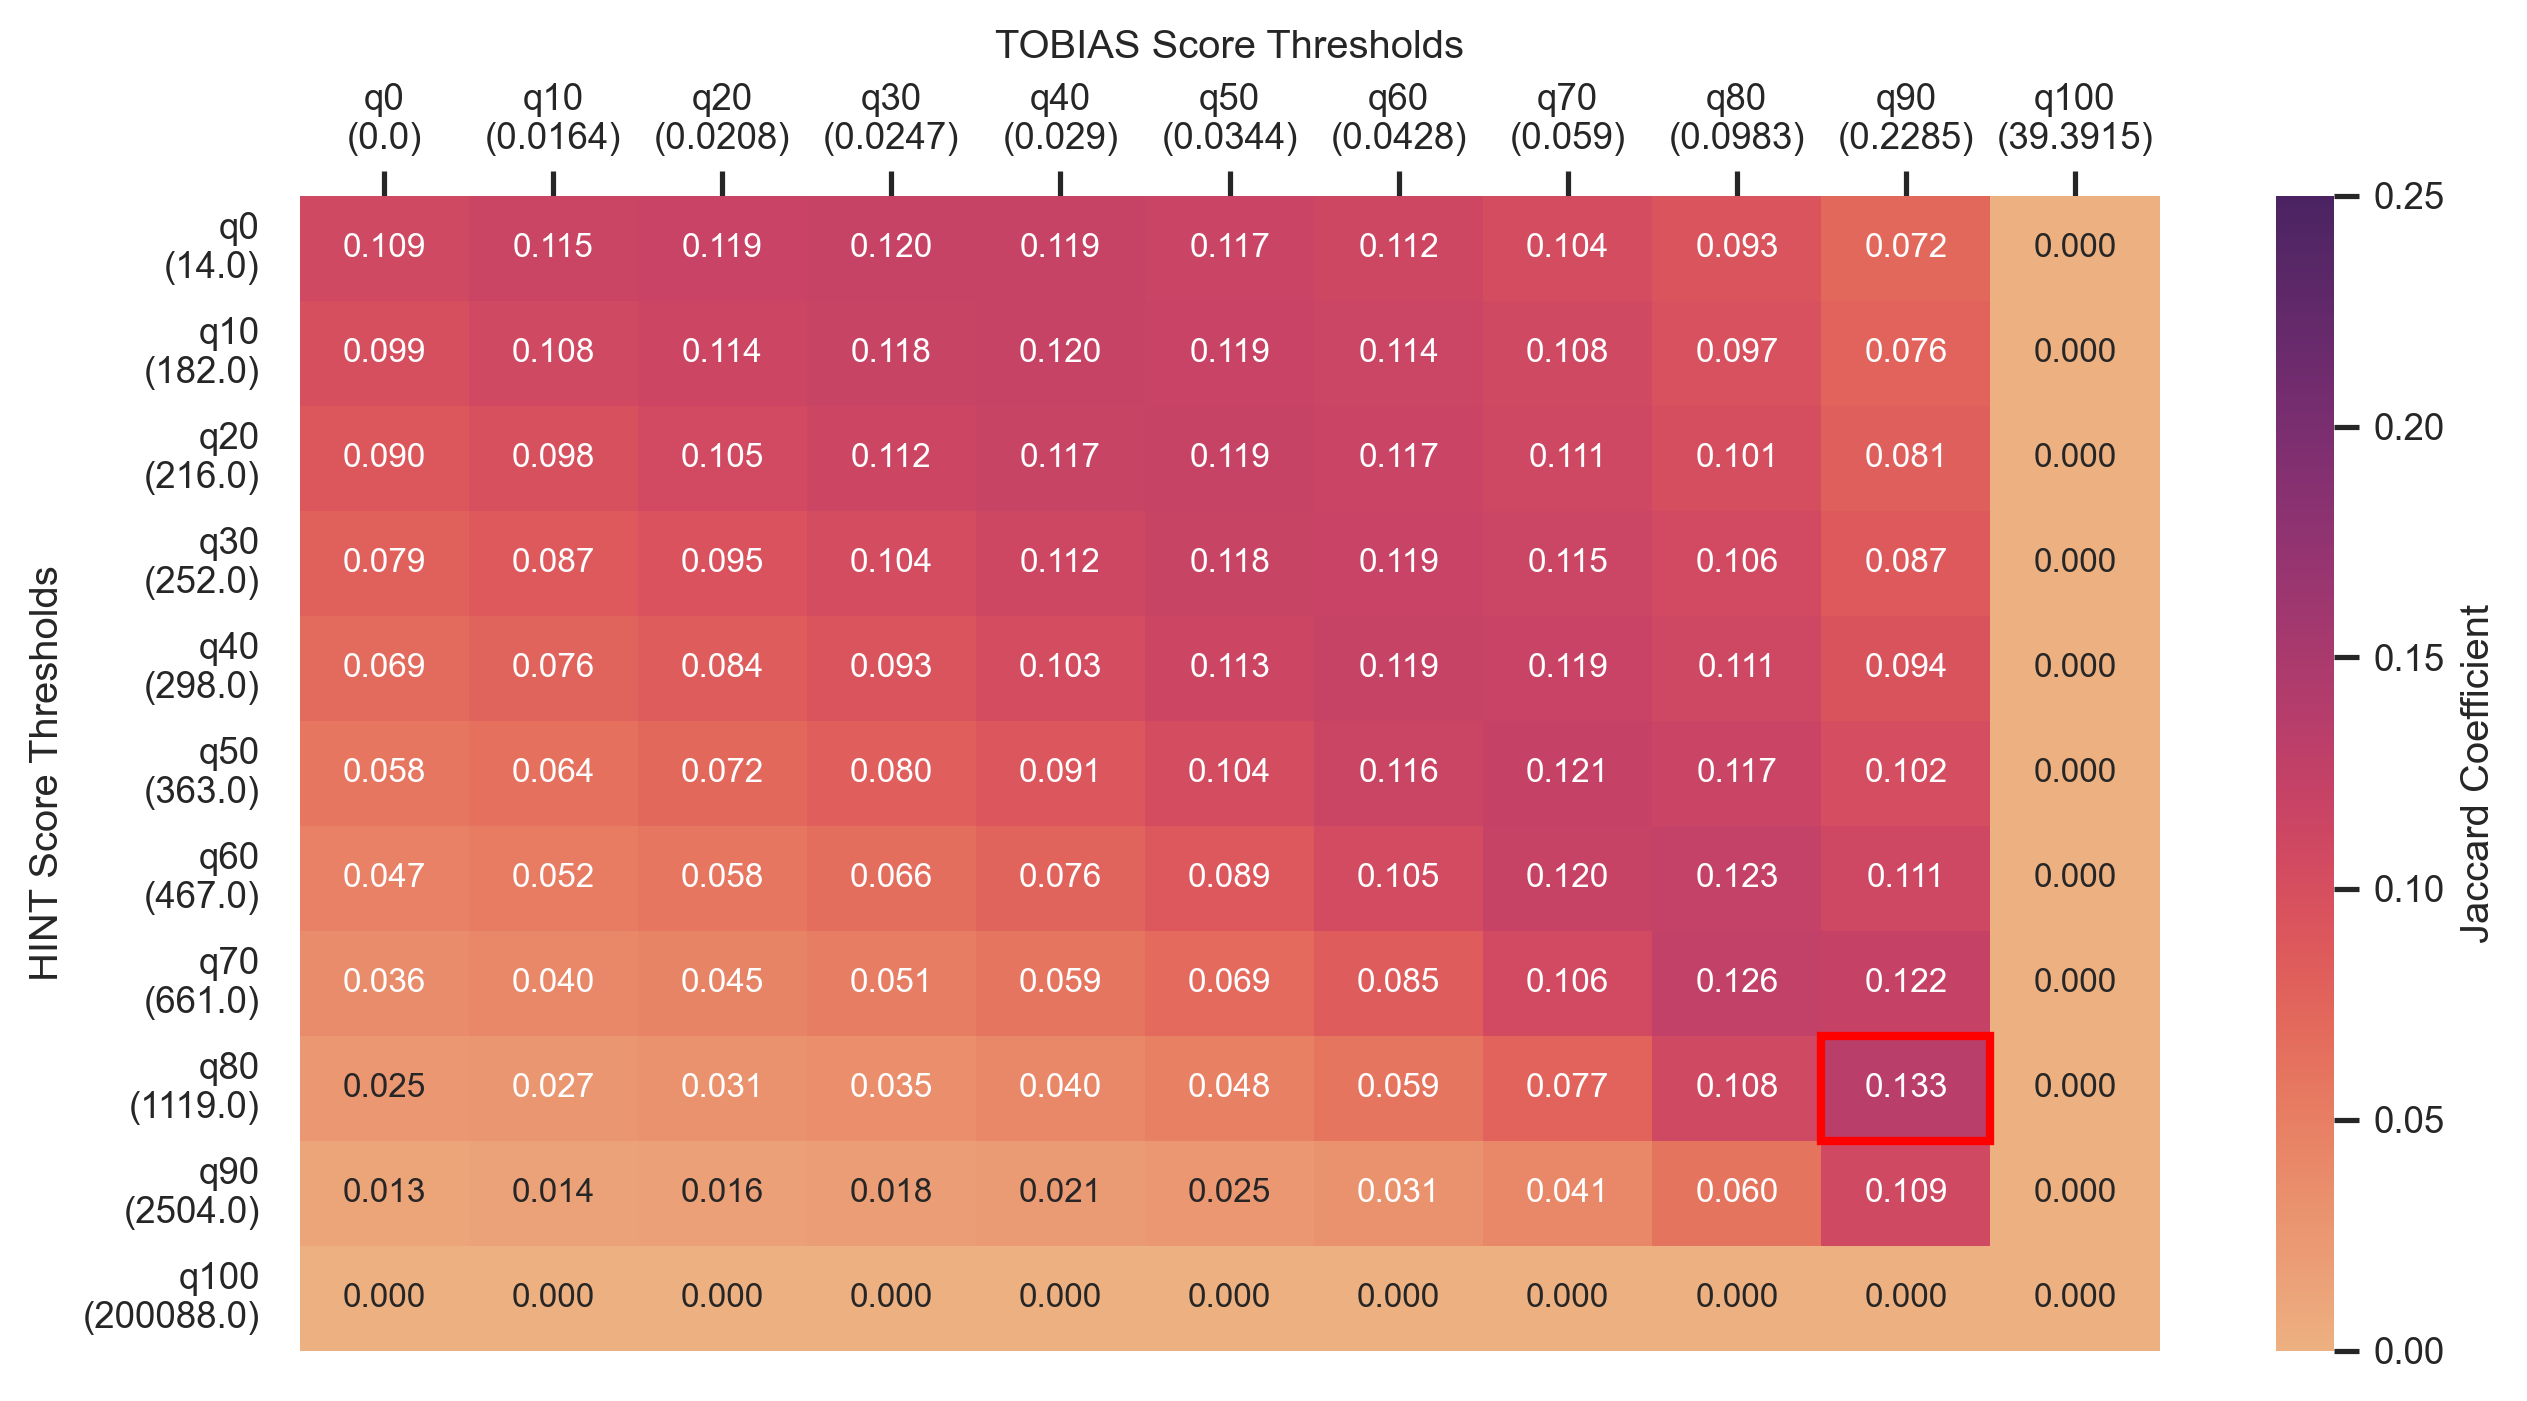

In [33]:
sns.set(font_scale=0.8, style='whitegrid')
fig = plt.figure(figsize=(10,5))
gs = GridSpec(1, 1, figure=fig, wspace=0.25, hspace=0.45)

ax = fig.add_subplot(gs[0])
a = "hint"
b = "tobias"
tmp = df[(df.tool1==a) & (df.tool2==b)]
v = "jaccard"
pivot_tmp = tmp.pivot_table(index='thresh1', columns='thresh2', values=v)
pivot_tmp.columns = [f"q{round(i*100)}\n({j})" for i,j in zip(np.linspace(0,1,11), pivot_tmp.columns)]
pivot_tmp.index = [f"q{round(i*100)}\n({j})" for i,j in zip(np.linspace(0,1,11), pivot_tmp.index)]

g = sns.heatmap(pivot_tmp,
            annot=True, fmt=".3f", cmap="flare",
            annot_kws={"size":8}, vmin=0, vmax=0.25, cbar=True)
cbar = g.collections[0].colorbar
cbar.set_label("Jaccard Coefficient")

max_row, max_col = pivot_tmp.values.argmax() // pivot_tmp.shape[1], pivot_tmp.values.argmax() % pivot_tmp.shape[1]
plt.gca().add_patch(plt.Rectangle((max_col, max_row), 1, 1, fill=False, edgecolor='red', lw=2))

ax.xaxis.tick_top()
ax.set_ylabel(f"{a.upper()} Score Thresholds")
ax.set_title(f"{b.upper()} Score Thresholds")

plt.savefig("../12_manuscript_figures/svg/FigS3_TOBIASvHINT.svg")
plt.savefig("../12_manuscript_figures/png/FigS3_TOBIASvHINT.png")
plt.savefig("../12_manuscript_figures/pdf/FigS3_TOBIASvHINT.pdf", bbox_inches='tight')
plt.show()

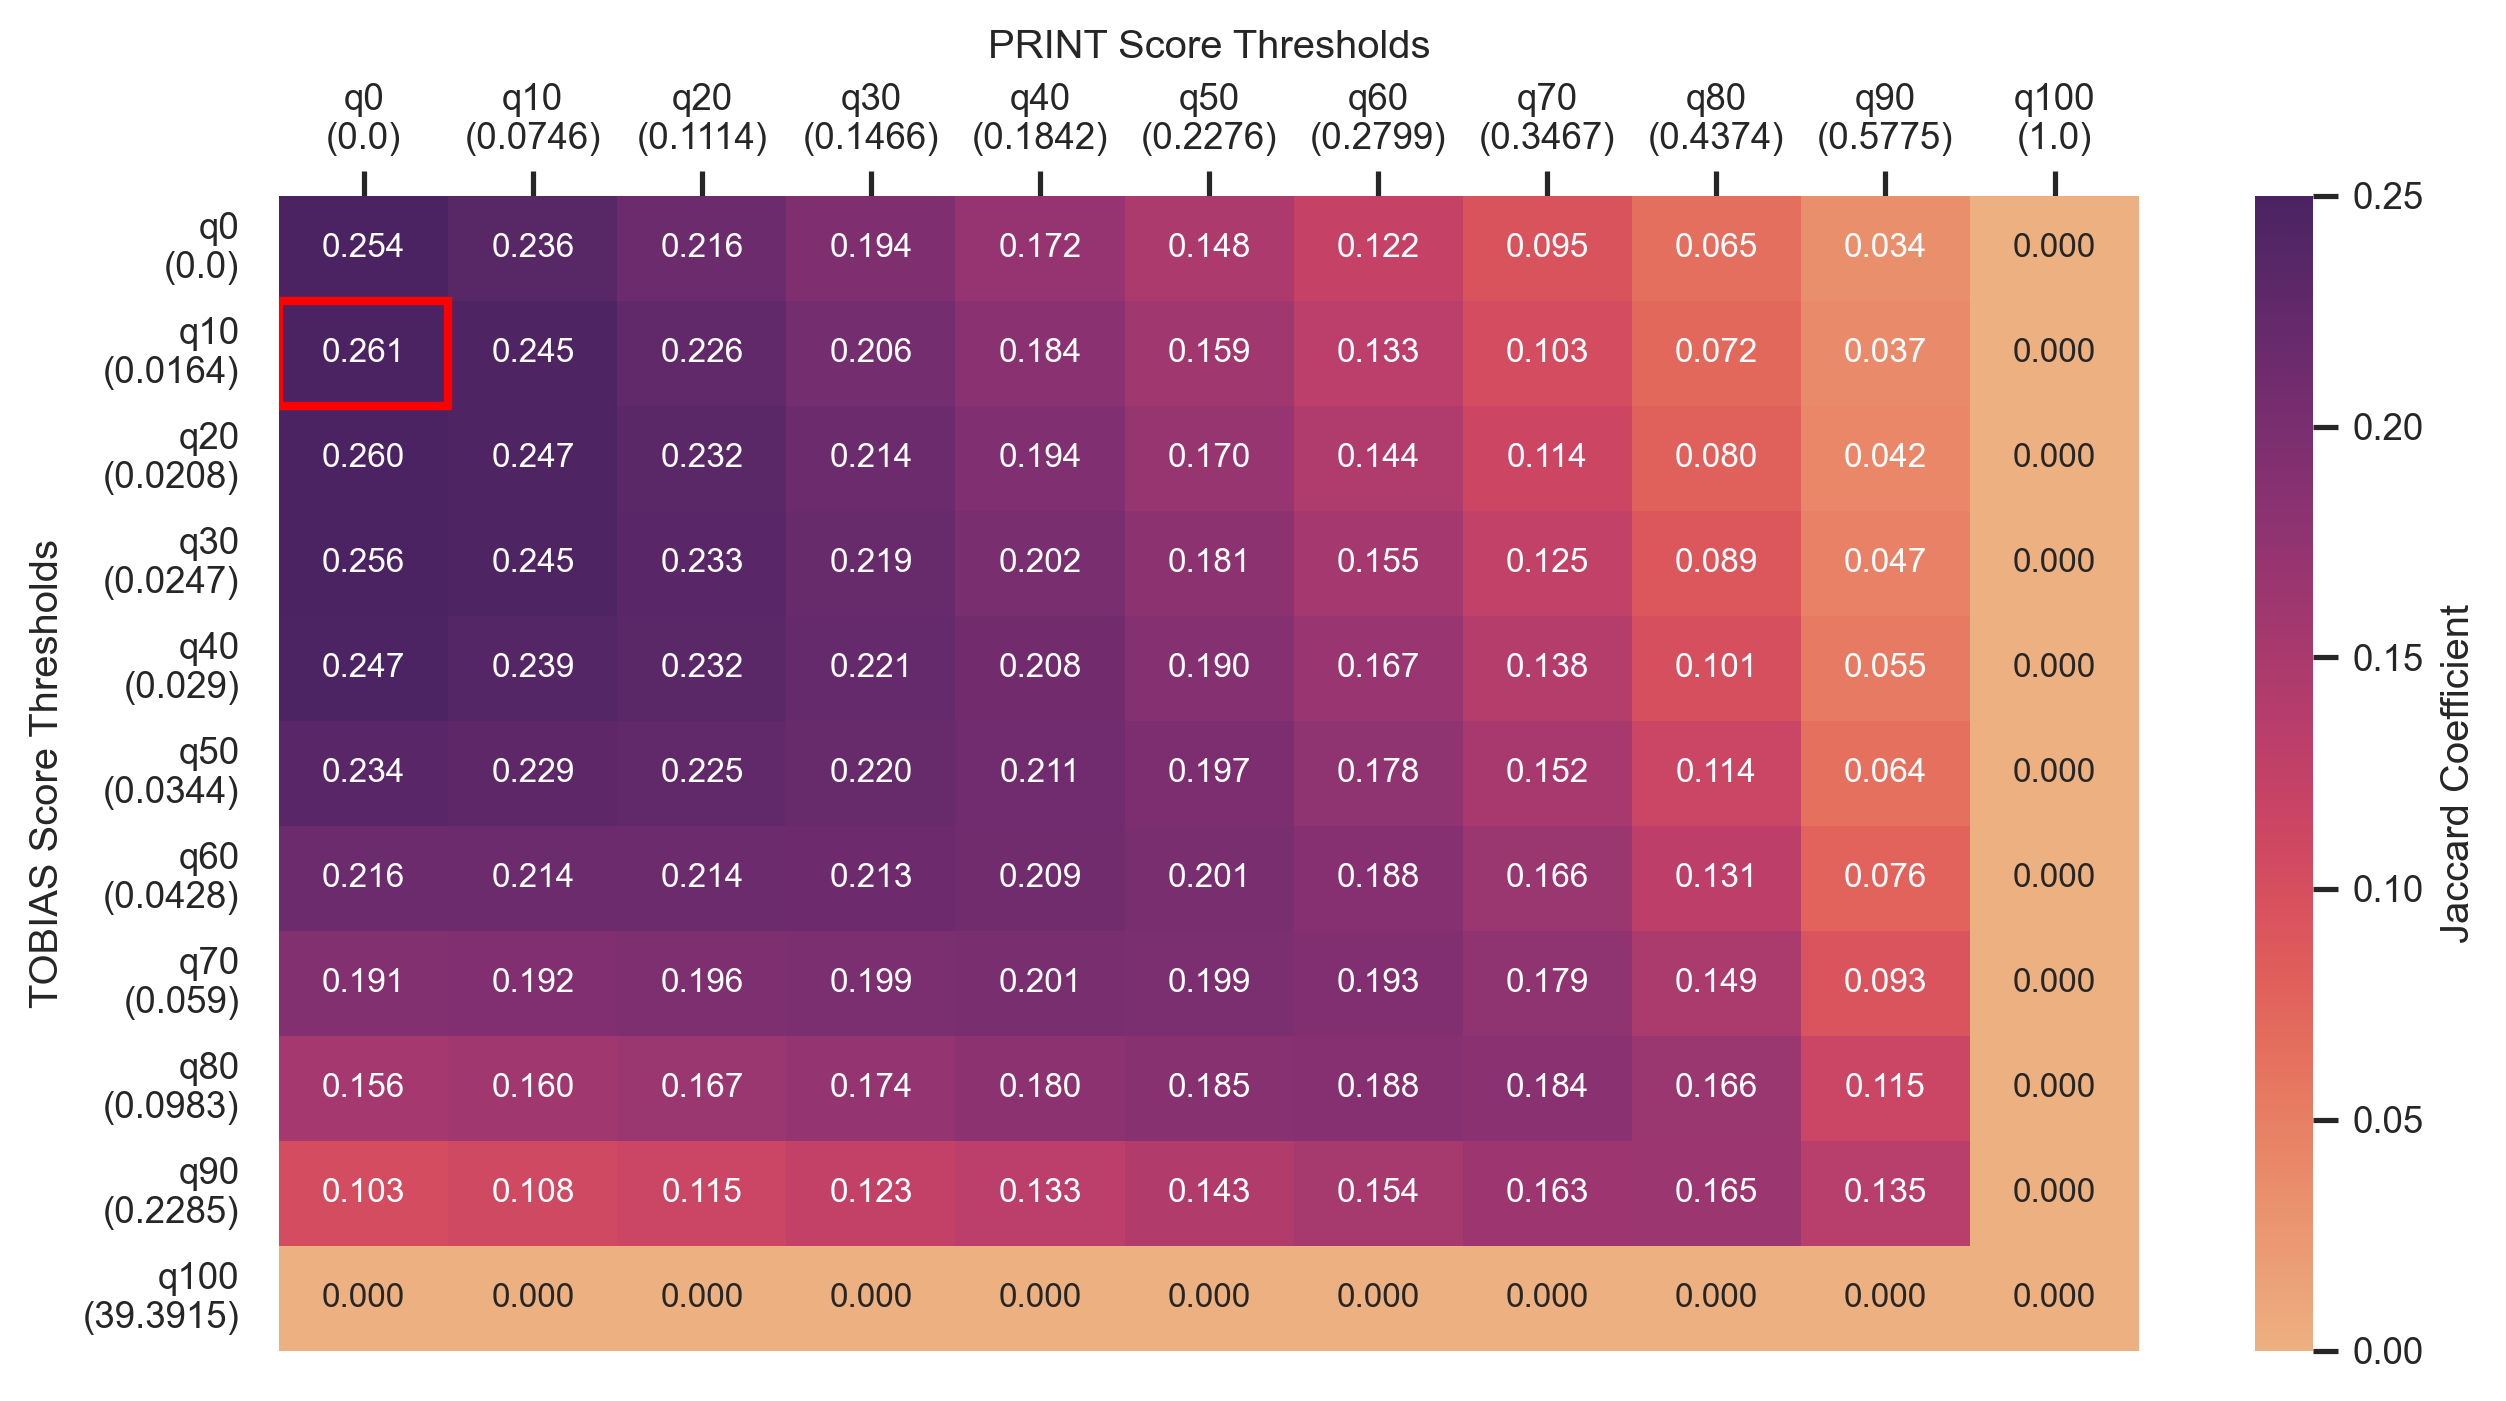

In [34]:
sns.set(font_scale=0.8, style='whitegrid')
fig = plt.figure(figsize=(10,5))
gs = GridSpec(1, 1, figure=fig, wspace=0.25, hspace=0.45)

ax = fig.add_subplot(gs[0])
a = "tobias"
b = "print"
tmp = df[(df.tool1==a) & (df.tool2==b)]
v = "jaccard"
pivot_tmp = tmp.pivot_table(index='thresh1', columns='thresh2', values=v)
pivot_tmp.columns = [f"q{round(i*100)}\n({j})" for i,j in zip(np.linspace(0,1,11), pivot_tmp.columns)]
pivot_tmp.index = [f"q{round(i*100)}\n({j})" for i,j in zip(np.linspace(0,1,11), pivot_tmp.index)]

g = sns.heatmap(pivot_tmp,
            annot=True, fmt=".3f", cmap="flare",
            annot_kws={"size":8}, vmin=0, vmax=0.25, cbar=True)
cbar = g.collections[0].colorbar
cbar.set_label("Jaccard Coefficient")

max_row, max_col = pivot_tmp.values.argmax() // pivot_tmp.shape[1], pivot_tmp.values.argmax() % pivot_tmp.shape[1]
plt.gca().add_patch(plt.Rectangle((max_col, max_row), 1, 1, fill=False, edgecolor='red', lw=2))

ax.xaxis.tick_top()
ax.set_ylabel(f"{a.upper()} Score Thresholds")
ax.set_title(f"{b.upper()} Score Thresholds")


plt.savefig("../12_manuscript_figures/svg/FigS3_TOBIASvPRINT.svg")
plt.savefig("../12_manuscript_figures/png/FigS3_TOBIASvPRINT.png")
plt.savefig("../12_manuscript_figures/pdf/FigS3_TOBIASvPRINT.pdf", bbox_inches='tight')
plt.show()

# 4. Genome-wide trends <a class="anchor" id="fourth-bullet"></a>

In [80]:
def _get_cellline_arrays(cl):
    peak_file = f"../03_peakcalls/{cl}_filt_500bp.exclusion.bed"
    df = pd.read_csv(f"{peak_file}", header=None, sep="\t")
    df["region_atac"] = df[0].astype(str) + ":" + df[1].astype(str) + "-" + df[2].astype(str)
    all_atac_regions = df["region_atac"].tolist()
    
    return all_atac_regions

    
def _addHINTdenovo(cl):
    peak_file = f"../03_peakcalls/{cl}_filt_500bp.exclusion.bed"
    foot_file = f"../05_footprinting/01_original/hint/{cl}-cellFilt.bed"
    tmp_file = f"current_hint_{random.randint(1, 1000)}.bed" #bc multiprocessing
    
    ! bedtools intersect \
        -a {peak_file} \
        -b <(awk '{{sub(/[ \t]+$$/, ""); print}}' {foot_file}) \
        -F 0.5 -wb -wa -sorted > {tmp_file}

    tmp = pd.read_csv(tmp_file, header=None, sep="\t")
    tmp["region_atac"] = tmp[0].astype(str) + ":" + tmp[1].astype(str) + "-" + tmp[2].astype(str)
    all_atac_regions = _get_cellline_arrays(cl)
    
    if len(set(tmp["region_atac"]) - set(all_atac_regions)) != 0:
        print("uh oh"); return
    else:
        ! rm {tmp_file}
    
    value_counts_df = (
        tmp["region_atac"]
        .value_counts()
        .reindex(all_atac_regions, fill_value=0)  # Reindex with the external vector, filling missing values with 0
        .reset_index()  # Reset index to make it a proper dataframe
    )

    value_counts_df.columns = ['region_atac', '#footprints']
    value_counts_df["tool"] = "hint-denovo"
    value_counts_df["cell_line"] = cl
    return value_counts_df[['region_atac', '#footprints', 'tool',  'cell_line']]


def _addPRINTdenovo(cl):
    peak_file = f"../03_peakcalls/{cl}_filt_500bp.exclusion.bed"
    foot_file = f"../05_footprinting/01_original/print/{cl}/{cl}_denovo_granges.bed"
    tmp_file = f"current_print_{random.randint(1, 1000)}.bed" #bc multiprocessing
    
    ! bedtools intersect \
        -a {peak_file} \
        -b <(tail -n+2 {foot_file} | tr " " "\t" | sort -k1,1 -k2,2n) \
        -F 0.5 -wb -wa -sorted > {tmp_file}

    #read in df and merge by tag count. 
    df = pd.read_csv(tmp_file, sep="\t", header=None) 
    df = df.drop_duplicates()
    df["region_atac"] = df[0].astype(str) + ":" + df[1].astype(str) + "-" + df[2].astype(str)
    df["region_TFBS"] = df[6].astype(str) + ":" + df[7].astype(str) + "-" + df[8].astype(str)
    df["score"] = df[13]
    df = df[df["score"] >= 0.3]
    
    all_atac_regions = _get_cellline_arrays(cl)

    if len(set(df["region_atac"]) - set(all_atac_regions)) != 0:
        print("uh oh"); return
    else:
        ! rm {tmp_file}
        
    value_counts_df = (
        df["region_atac"]
        .value_counts()
        .reindex(all_atac_regions, fill_value=0)  # Reindex with the external vector, filling missing values with 0
        .reset_index()  # Reset index to make it a proper dataframe
    )

    value_counts_df.columns = ['region_atac', '#footprints']
    value_counts_df["tool"] = "print-denovo"
    value_counts_df["cell_line"] = cl
    return value_counts_df[['region_atac', '#footprints', 'tool',  'cell_line']]




def _process_chunk(args):
    cl, tool = args
    core_dir = "../06_dataquality/"

    tmp = pd.read_csv(f"{core_dir}/{tool}/mats/{cl}-cellFilt.mat", index_col=0)
    pwm = tmp.sum(axis=0)
    peak = tmp.sum(axis=1)

    pwm_df = pwm.to_frame(name="#footprints").reset_index().rename(columns={"index": "TF"})
    pwm_df["tool"] = tool
    pwm_df["cell_line"] = cl

    peak_df = peak.to_frame(name="#footprints").reset_index().rename(columns={"index": "peak"})
    peak_df["tool"] = tool
    peak_df["cell_line"] = cl
    
    return pwm_df, peak_df

    
def run_parallel(func, args, processes):
    with Pool(processes=processes) as pool:
        return pool.map(func, args)


def main():
    cell_lines = ["HEPG2", "K562", "MCF7", "SKNSH"]
    tools = ["hint", "print", "tobias",  "pwm"]
    
    tasks = [(cl, tool) for cl in cell_lines for tool in tools]
    results = run_parallel(_process_chunk, tasks, processes=12)
    byPWM, byPeak = zip(*results)
    
    byPeak = list(byPeak)
    byPeak += run_parallel(_addHINTdenovo, cell_lines, processes=4) 
    byPeak += run_parallel(_addPRINTdenovo, cell_lines, processes=4)
    
    PEAKdf = pd.concat(byPeak, ignore_index=True)
    PWMdf = pd.concat(byPWM, ignore_index=True)
    
    PEAKdf.to_csv('baseline_peakdf.csv')  
    PWMdf.to_csv('baseline_pwmdf.csv')  
    print("done")

from multiprocessing import Pool
import random

main()

done


In [10]:
genome_wide_PWM = pd.read_csv("baseline_pwmdf.csv", index_col=0)
genome_wide_Peak = pd.read_csv("baseline_peakdf.csv", index_col=0)
genome_wide = pd.DataFrame(genome_wide_Peak.groupby(["tool", "cell_line"])["#footprints"].sum()).reset_index()
display(genome_wide_PWM)

,TF,#footprints,tool,cell_line
0,BATF::JUN_MA0462.2,13253,hint,HEPG2
1,BATF_MA1634.1,13409,hint,HEPG2
2,FOSB::JUNB_MA1135.1,15636,hint,HEPG2
3,FOSL2::JUNB_MA1138.1,15616,hint,HEPG2
4,FOSL2::JUND_MA1144.1,15660,hint,HEPG2
...,...,...,...,...
13451,ZSCAN31_MA1722.1,5085,pwm,SKNSH
13452,REST_MA0138.2,50388,pwm,SKNSH
13453,RREB1_MA0073.1,552041,pwm,SKNSH
13454,THRB_MA1575.1,76195,pwm,SKNSH


In [4]:
print(genome_wide.groupby(["tool", "cell_line"])["#footprints"].sum())
print(genome_wide.groupby(["tool"])["#footprints"].sum())

tool          cell_line
hint          HEPG2          7038431
              K562           7300691
              MCF7           6100542
              SKNSH          6838516
hint-denovo   HEPG2          2618481
              K562           2653327
              MCF7           2219668
              SKNSH          2449579
print         HEPG2          6902219
              K562           6802510
              MCF7           7697761
              SKNSH          5868209
print-denovo  HEPG2          6430895
              K562           6643879
              MCF7           6355809
              SKNSH          5540309
pwm           HEPG2        359130479
              K562         406670333
              MCF7         317910388
              SKNSH        369344200
tobias        HEPG2          6062833
              K562           6718939
              MCF7           6369493
              SKNSH          7040698
Name: #footprints, dtype: int64
tool
hint              27278180
hint-denovo        99410

In [5]:
print(genome_wide.groupby(["tool", "cell_line"])["#footprints"].mean())
print(genome_wide.groupby(["tool"])["#footprints"].mean())

tool          cell_line
hint          HEPG2          7038431.0
              K562           7300691.0
              MCF7           6100542.0
              SKNSH          6838516.0
hint-denovo   HEPG2          2618481.0
              K562           2653327.0
              MCF7           2219668.0
              SKNSH          2449579.0
print         HEPG2          6902219.0
              K562           6802510.0
              MCF7           7697761.0
              SKNSH          5868209.0
print-denovo  HEPG2          6430895.0
              K562           6643879.0
              MCF7           6355809.0
              SKNSH          5540309.0
pwm           HEPG2        359130479.0
              K562         406670333.0
              MCF7         317910388.0
              SKNSH        369344200.0
tobias        HEPG2          6062833.0
              K562           6718939.0
              MCF7           6369493.0
              SKNSH          7040698.0
Name: #footprints, dtype: float64
tool
h

In [6]:
print(genome_wide_Peak.groupby(["tool", "cell_line"])["#footprints"].mean())
print(genome_wide_Peak.groupby(["tool"])["#footprints"].mean())

tool          cell_line
hint          HEPG2         16.078397
              K562          14.671188
              MCF7          16.163416
              SKNSH         15.712924
hint-denovo   HEPG2          5.981586
              K562           5.332024
              MCF7           5.881021
              SKNSH          5.628421
print         HEPG2         15.767238
              K562          13.670062
              MCF7          20.395256
              SKNSH         13.483440
print-denovo  HEPG2         14.690559
              K562          13.351283
              MCF7          16.839747
              SKNSH         12.730021
pwm           HEPG2        820.387747
              K562         817.229042
              MCF7         842.305143
              SKNSH        848.645730
tobias        HEPG2         13.849768
              K562          13.502121
              MCF7          16.876003
              SKNSH         16.177480
Name: #footprints, dtype: float64
tool
hint             15.60516

In [8]:
print(genome_wide_PWM.groupby(["tool", "cell_line"])["#footprints"].mean())
print(genome_wide_PWM.groupby(["tool"])["#footprints"].mean())

tool    cell_line
hint    HEPG2          8369.121284
        K562           8680.964328
        MCF7           7253.914388
        SKNSH          8131.410226
print   HEPG2          8207.156956
        K562           8088.596908
        MCF7           9153.104637
        SKNSH          6977.656361
pwm     HEPG2        427027.917955
        K562         483555.687277
        MCF7         378014.730083
        SKNSH        439172.651605
tobias  HEPG2          7209.076100
        K562           7989.225922
        MCF7           7573.713436
        SKNSH          8371.816885
Name: #footprints, dtype: float64
tool
hint        8108.852556
print       8106.628716
pwm       431942.746730
tobias      7785.958086
Name: #footprints, dtype: float64


In [11]:
pwm_values = genome_wide_PWM[genome_wide_PWM["tool"] == "pwm"].set_index(["TF", "cell_line"])["#footprints"]
genome_wide_PWM["pwm_ref"] = genome_wide_PWM.set_index(["TF", "cell_line"]).index.map(pwm_values)
genome_wide_PWM["pct_occupied"] = (genome_wide_PWM["#footprints"] / genome_wide_PWM["pwm_ref"]) * 100

print(genome_wide_PWM.groupby(["tool", "cell_line"])["pct_occupied"].mean())
print(genome_wide_PWM.groupby(["tool"])["pct_occupied"].mean())


tool    cell_line
hint    HEPG2          6.506347
        K562           6.044985
        MCF7           6.278822
        SKNSH          6.326982
print   HEPG2          7.070429
        K562           6.106509
        MCF7           8.516830
        SKNSH          5.919329
pwm     HEPG2        100.000000
        K562         100.000000
        MCF7         100.000000
        SKNSH        100.000000
tobias  HEPG2          6.248195
        K562           6.175825
        MCF7           7.547611
        SKNSH          7.550080
Name: pct_occupied, dtype: float64
tool
hint        6.289284
print       6.903274
pwm       100.000000
tobias      6.880428
Name: pct_occupied, dtype: float64


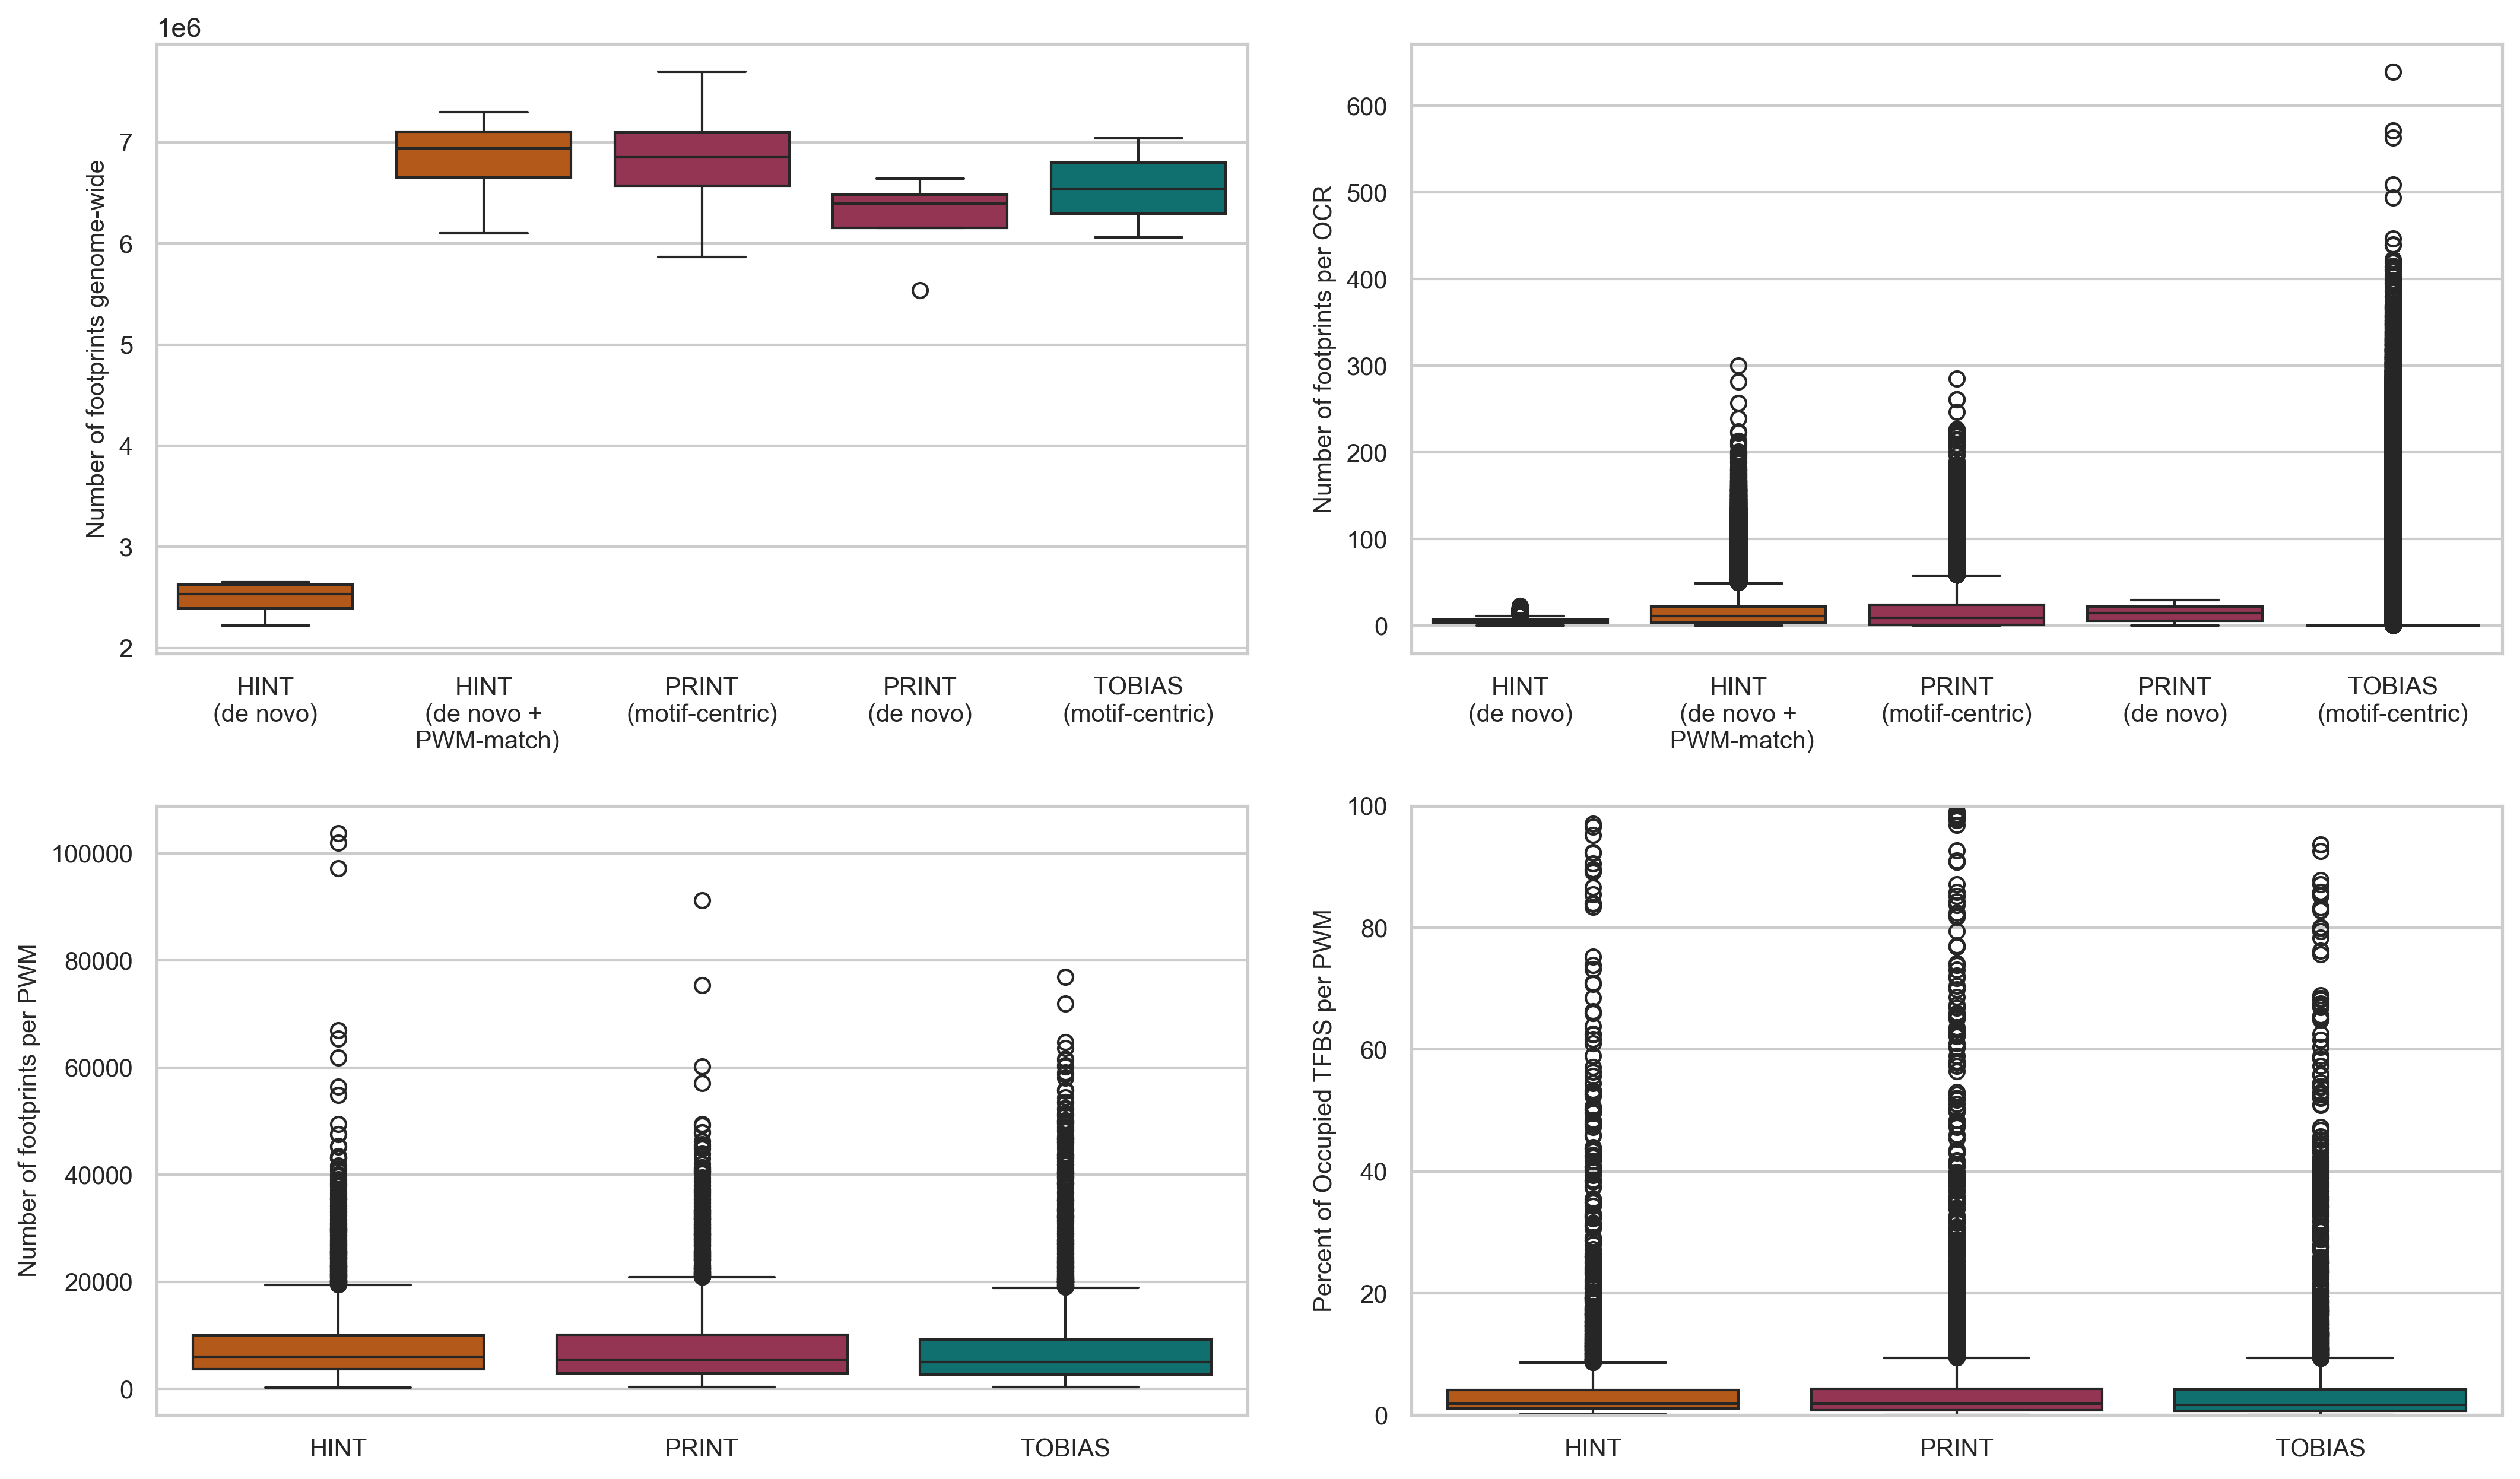

In [11]:
color_scheme_prog = {'tobias': '#008080', 'hint': '#CC5500', 'print': '#A4254E', 'pwm':"grey",
                     'hint-denovo': '#CC5500', 'print-denovo': '#A4254E'}

sns.set(font_scale=1, style='whitegrid')
fig = plt.figure(figsize=(17,10))
gs = GridSpec(2, 2, figure=fig, wspace=0.15, hspace=0.25)

order = ["hint-denovo", "hint",  "print", "print-denovo", "tobias"]
ax0 = fig.add_subplot(gs[0])
sns.boxplot(genome_wide[genome_wide.tool != "pwm"], 
            y="#footprints", x="tool", 
            palette=color_scheme_prog, 
            ax = ax0, order=order)

ax1 = fig.add_subplot(gs[1])
sns.boxplot(genome_wide_Peak[genome_wide_Peak.tool != "pwm"], 
            y="#footprints", x="tool",
            palette=color_scheme_prog, 
            ax = ax1, order=order)

order = ["hint", "print", "tobias"]
ax2 = fig.add_subplot(gs[2])
sns.boxplot(genome_wide_PWM[genome_wide_PWM.tool != "pwm"], 
            y="#footprints", x="tool", 
            palette=color_scheme_prog, 
            ax = ax2, order=order)

ax3 = fig.add_subplot(gs[3])
sns.boxplot(genome_wide_PWM[genome_wide_PWM.tool != "pwm"], 
            y="pct_occupied", x="tool", 
            palette=color_scheme_prog, 
            ax = ax3, order=order)


ax0.set_ylabel("Number of footprints genome-wide", fontsize=10)
ax1.set_ylabel("Number of footprints per OCR", fontsize=10)
ax2.set_ylabel("Number of footprints per PWM", fontsize=10)
ax3.set_ylabel("Percent of Occupied TFBS per PWM", fontsize=10)

prettylabels = ['HINT\n(de novo)', 'HINT\n(de novo +\n PWM-match)', 'PRINT\n(motif-centric)', 'PRINT\n(de novo)', 'TOBIAS\n(motif-centric)']
ax0.set_xticks(ax0.get_xticks()); ax0.set_xticklabels(prettylabels, fontsize=10)#, rotation=25, ha='right')
ax1.set_xticks(ax1.get_xticks()); ax1.set_xticklabels(prettylabels, fontsize=10)#, rotation=25, ha='right')
prettylabels = ["HINT", "PRINT", "TOBIAS"]
ax2.set_xticks(ax2.get_xticks()); ax2.set_xticklabels(prettylabels, fontsize=10)#, rotation=25, ha='right')
ax3.set_xticks(ax3.get_xticks()); ax3.set_xticklabels(prettylabels, fontsize=10)#, rotation=25, ha='right')

ax0.tick_params(labelsize=10)
ax1.tick_params(labelsize=10)
ax2.tick_params(labelsize=10)
ax3.tick_params(labelsize=10)

ax0.set_xlabel("")
ax1.set_xlabel("")
ax2.set_xlabel("")
ax3.set_xlabel("")

ax3.set_ylim(0,100)

plt.show()

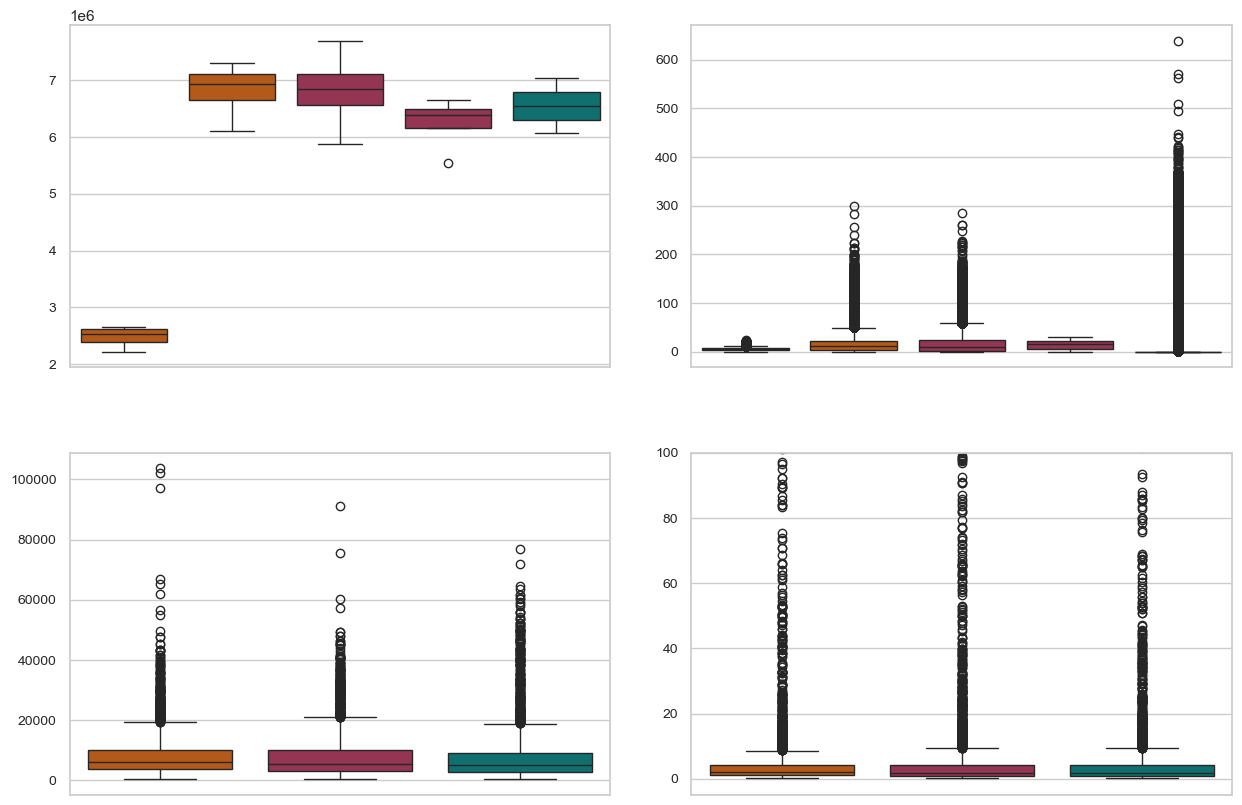

In [12]:
#MANUSCRIPT FORMATTING
def _format(ax):
    ax.set_xlabel("");ax.set_ylabel("") 
    ax.tick_params(labelsize=10)
    ax.set_xticks([])
    return ax
    
color_scheme_prog = {'tobias': '#008080', 'hint': '#CC5500', 'print': '#A4254E', 'pwm':"grey",
                     'hint-denovo': '#CC5500', 'print-denovo': '#A4254E'}

sns.set(font_scale=1, style='whitegrid')
fig = plt.figure(figsize=(15,10))
gs = GridSpec(2, 2, figure=fig, wspace=0.15, hspace=0.25)

order = ["hint-denovo", "hint",  "print", "print-denovo", "tobias"]
ax0 = fig.add_subplot(gs[0])
sns.boxplot(genome_wide[genome_wide.tool != "pwm"], 
            y="#footprints", x="tool", 
            palette=color_scheme_prog, 
            ax = ax0, order=order,
            flierprops=dict(rasterized=True))

ax1 = fig.add_subplot(gs[1])
sns.boxplot(genome_wide_Peak[genome_wide_Peak.tool != "pwm"], 
            y="#footprints", x="tool",
            palette=color_scheme_prog, 
            ax = ax1, order=order,
            flierprops=dict(rasterized=True))
    
order = ["hint", "print", "tobias"]
ax2 = fig.add_subplot(gs[2])
bp = sns.boxplot(genome_wide_PWM[genome_wide_PWM.tool != "pwm"], 
            y="#footprints", x="tool", 
            palette=color_scheme_prog, 
            ax = ax2, order=order,
            flierprops=dict(rasterized=True))

ax3 = fig.add_subplot(gs[3])
bp = sns.boxplot(genome_wide_PWM[genome_wide_PWM.tool != "pwm"], 
            y="pct_occupied", x="tool", 
            palette=color_scheme_prog, 
            ax = ax3, order=order,
            flierprops=dict(rasterized=True))
ax3.set_ylim(-5,100)

ax0 = _format(ax0)
ax1 = _format(ax1)
ax2 = _format(ax2)
ax3 = _format(ax3)

# plt.savefig("../12_manuscript_figures/svg/FigS3_genomewide_stats.svg")
# plt.savefig("../12_manuscript_figures/png/FigS3_genomewide_stats.png")
plt.savefig("../12_manuscript_figures/pdf/FigS3_genomewide_stats.pdf", dpi=300)

plt.show()

# 5. Similarity of TF rankings <a class="anchor" id="fifth-bullet"></a>

In [109]:
genome_wide_PWM = pd.read_csv("baseline_pwmdf.csv", index_col=0)
pwm_values = genome_wide_PWM[genome_wide_PWM["tool"] == "pwm"].set_index(["TF", "cell_line"])["#footprints"]
genome_wide_PWM["pwm_ref"] = genome_wide_PWM.set_index(["TF", "cell_line"]).index.map(pwm_values)
genome_wide_PWM["pct_occupied"] = (genome_wide_PWM["#footprints"] / genome_wide_PWM["pwm_ref"]) * 100
display(genome_wide_PWM)

,TF,#footprints,tool,cell_line,pwm_ref,pct_occupied
0,BATF::JUN_MA0462.2,13253,hint,HEPG2,547468,2.420781
1,BATF_MA1634.1,13409,hint,HEPG2,569718,2.353621
2,FOSB::JUNB_MA1135.1,15636,hint,HEPG2,260314,6.006592
3,FOSL2::JUNB_MA1138.1,15616,hint,HEPG2,241153,6.475557
4,FOSL2::JUND_MA1144.1,15660,hint,HEPG2,260231,6.017730
...,...,...,...,...,...,...
13451,ZSCAN31_MA1722.1,5085,pwm,SKNSH,5085,100.000000
13452,REST_MA0138.2,50388,pwm,SKNSH,50388,100.000000
13453,RREB1_MA0073.1,552041,pwm,SKNSH,552041,100.000000
13454,THRB_MA1575.1,76195,pwm,SKNSH,76195,100.000000


In [154]:
observed_df = pd.DataFrame()

#compare the mean of all other cell lines to one of interest
for cl in ["HEPG2", "MCF7", "K562", "SKNSH"]:
    for t in ["hint", "tobias", "print"]:
        #print(cl, t)
        tmp1 = genome_wide_PWM[
            (genome_wide_PWM["tool"] == t) & 
            (genome_wide_PWM["cell_line"] == cl)
            ].set_index(["TF"])["pct_occupied"]
    
        tmp2 = (
            genome_wide_PWM[
                (genome_wide_PWM["tool"] == t) & 
                (genome_wide_PWM["cell_line"] != cl)
            ]
            .groupby("TF")["pct_occupied"]
            .agg(["mean", "var", "std"]) #get average values across other cell lines. 
        )
        tmp2.columns = ["expected_mean", "expected_var", "expected_sd"]
        tmp2["observed"] = tmp2.index.map(tmp1)
        tmp2["cell_line"] = cl
        tmp2["tool"] = t
        observed_df = pd.concat([observed_df, tmp2])

#add generally needed columns
observed_df["o-e"] = (observed_df["observed"] - observed_df["expected_mean"])/observed_df["expected_sd"]
observed_df["name"] = observed_df.index
observed_df[["TF", "motif"]] = observed_df["name"].str.rsplit("_", n=1, expand=True)
observed_df = observed_df.rename_axis("index", axis=0)

#add RNAseq values.
rnaseq = "../09_simPWMs/ENCODE_bulkRNA/MeanExp.csv"
rnaseq_df = pd.read_csv(rnaseq, sep=",")
rnaseq_df = pd.melt(rnaseq_df, id_vars=['GeneSymbol'], var_name="cell_line", value_name="RNA_expression")
rnaseq_df.columns = ["TF", "cell_line", "RNA_expression"]
observed_df = observed_df.merge(rnaseq_df, on=['TF', 'cell_line'], how='left')
observed_df.index = observed_df.name

#add boolean column for ease. 
observed_df["RNA_expression_bool"] = np.where(observed_df["RNA_expression"].isna(), 
                                              'missing', np.where(observed_df["RNA_expression"] > 2, "expressed", "not_expressed"))
observed_df["RNA_expression_bool"] = observed_df["RNA_expression_bool"].astype('category')
observed_df["RNA_expression_bool"] = observed_df["RNA_expression_bool"].cat.reorder_categories(["expressed", "not_expressed", "missing"])


display(observed_df)

,expected_mean,expected_var,expected_sd,observed,cell_line,tool,o-e,name,TF,motif,RNA_expression,RNA_expression_bool
name,,,,,,,,,,,,
AHR::ARNT_MA0006.1,1.058019,0.000422,0.020545,1.113137,HEPG2,hint,2.682735,AHR::ARNT_MA0006.1,AHR::ARNT,MA0006.1,NaN,missing
ALX1_MA0854.1,0.947828,0.013502,0.116199,0.904354,HEPG2,hint,-0.374143,ALX1_MA0854.1,ALX1,MA0854.1,0.9885,not_expressed
ALX3_MA0634.1,0.380446,0.002197,0.046871,0.311949,HEPG2,hint,-1.461405,ALX3_MA0634.1,ALX3,MA0634.1,0.0000,not_expressed
ALX4_MA0853.1,0.856663,0.013695,0.117024,0.817945,HEPG2,hint,-0.330852,ALX4_MA0853.1,ALX4,MA0853.1,0.0025,not_expressed
ARGFX_MA1463.1,1.074434,0.036841,0.191939,0.933871,HEPG2,hint,-0.732333,ARGFX_MA1463.1,ARGFX,MA1463.1,0.0000,not_expressed
...,...,...,...,...,...,...,...,...,...,...,...,...
ZNF8_MA1718.1,18.661974,22.367220,4.729400,14.424882,SKNSH,print,-0.895905,ZNF8_MA1718.1,ZNF8,MA1718.1,NaN,missing
ZNF93_MA1721.1,4.581833,0.582179,0.763006,4.431018,SKNSH,print,-0.197658,ZNF93_MA1721.1,ZNF93,MA1721.1,NaN,missing
ZSCAN29_MA1602.1,3.097015,0.408023,0.638767,2.510101,SKNSH,print,-0.918823,ZSCAN29_MA1602.1,ZSCAN29,MA1602.1,NaN,missing


## 5.1 by observed-expected <a class="anchor" id="fifth1-bullet"></a>

/tmp/ipykernel_69698/972722823.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(["expressed", "not expressed", "missing"], fontsize=7)


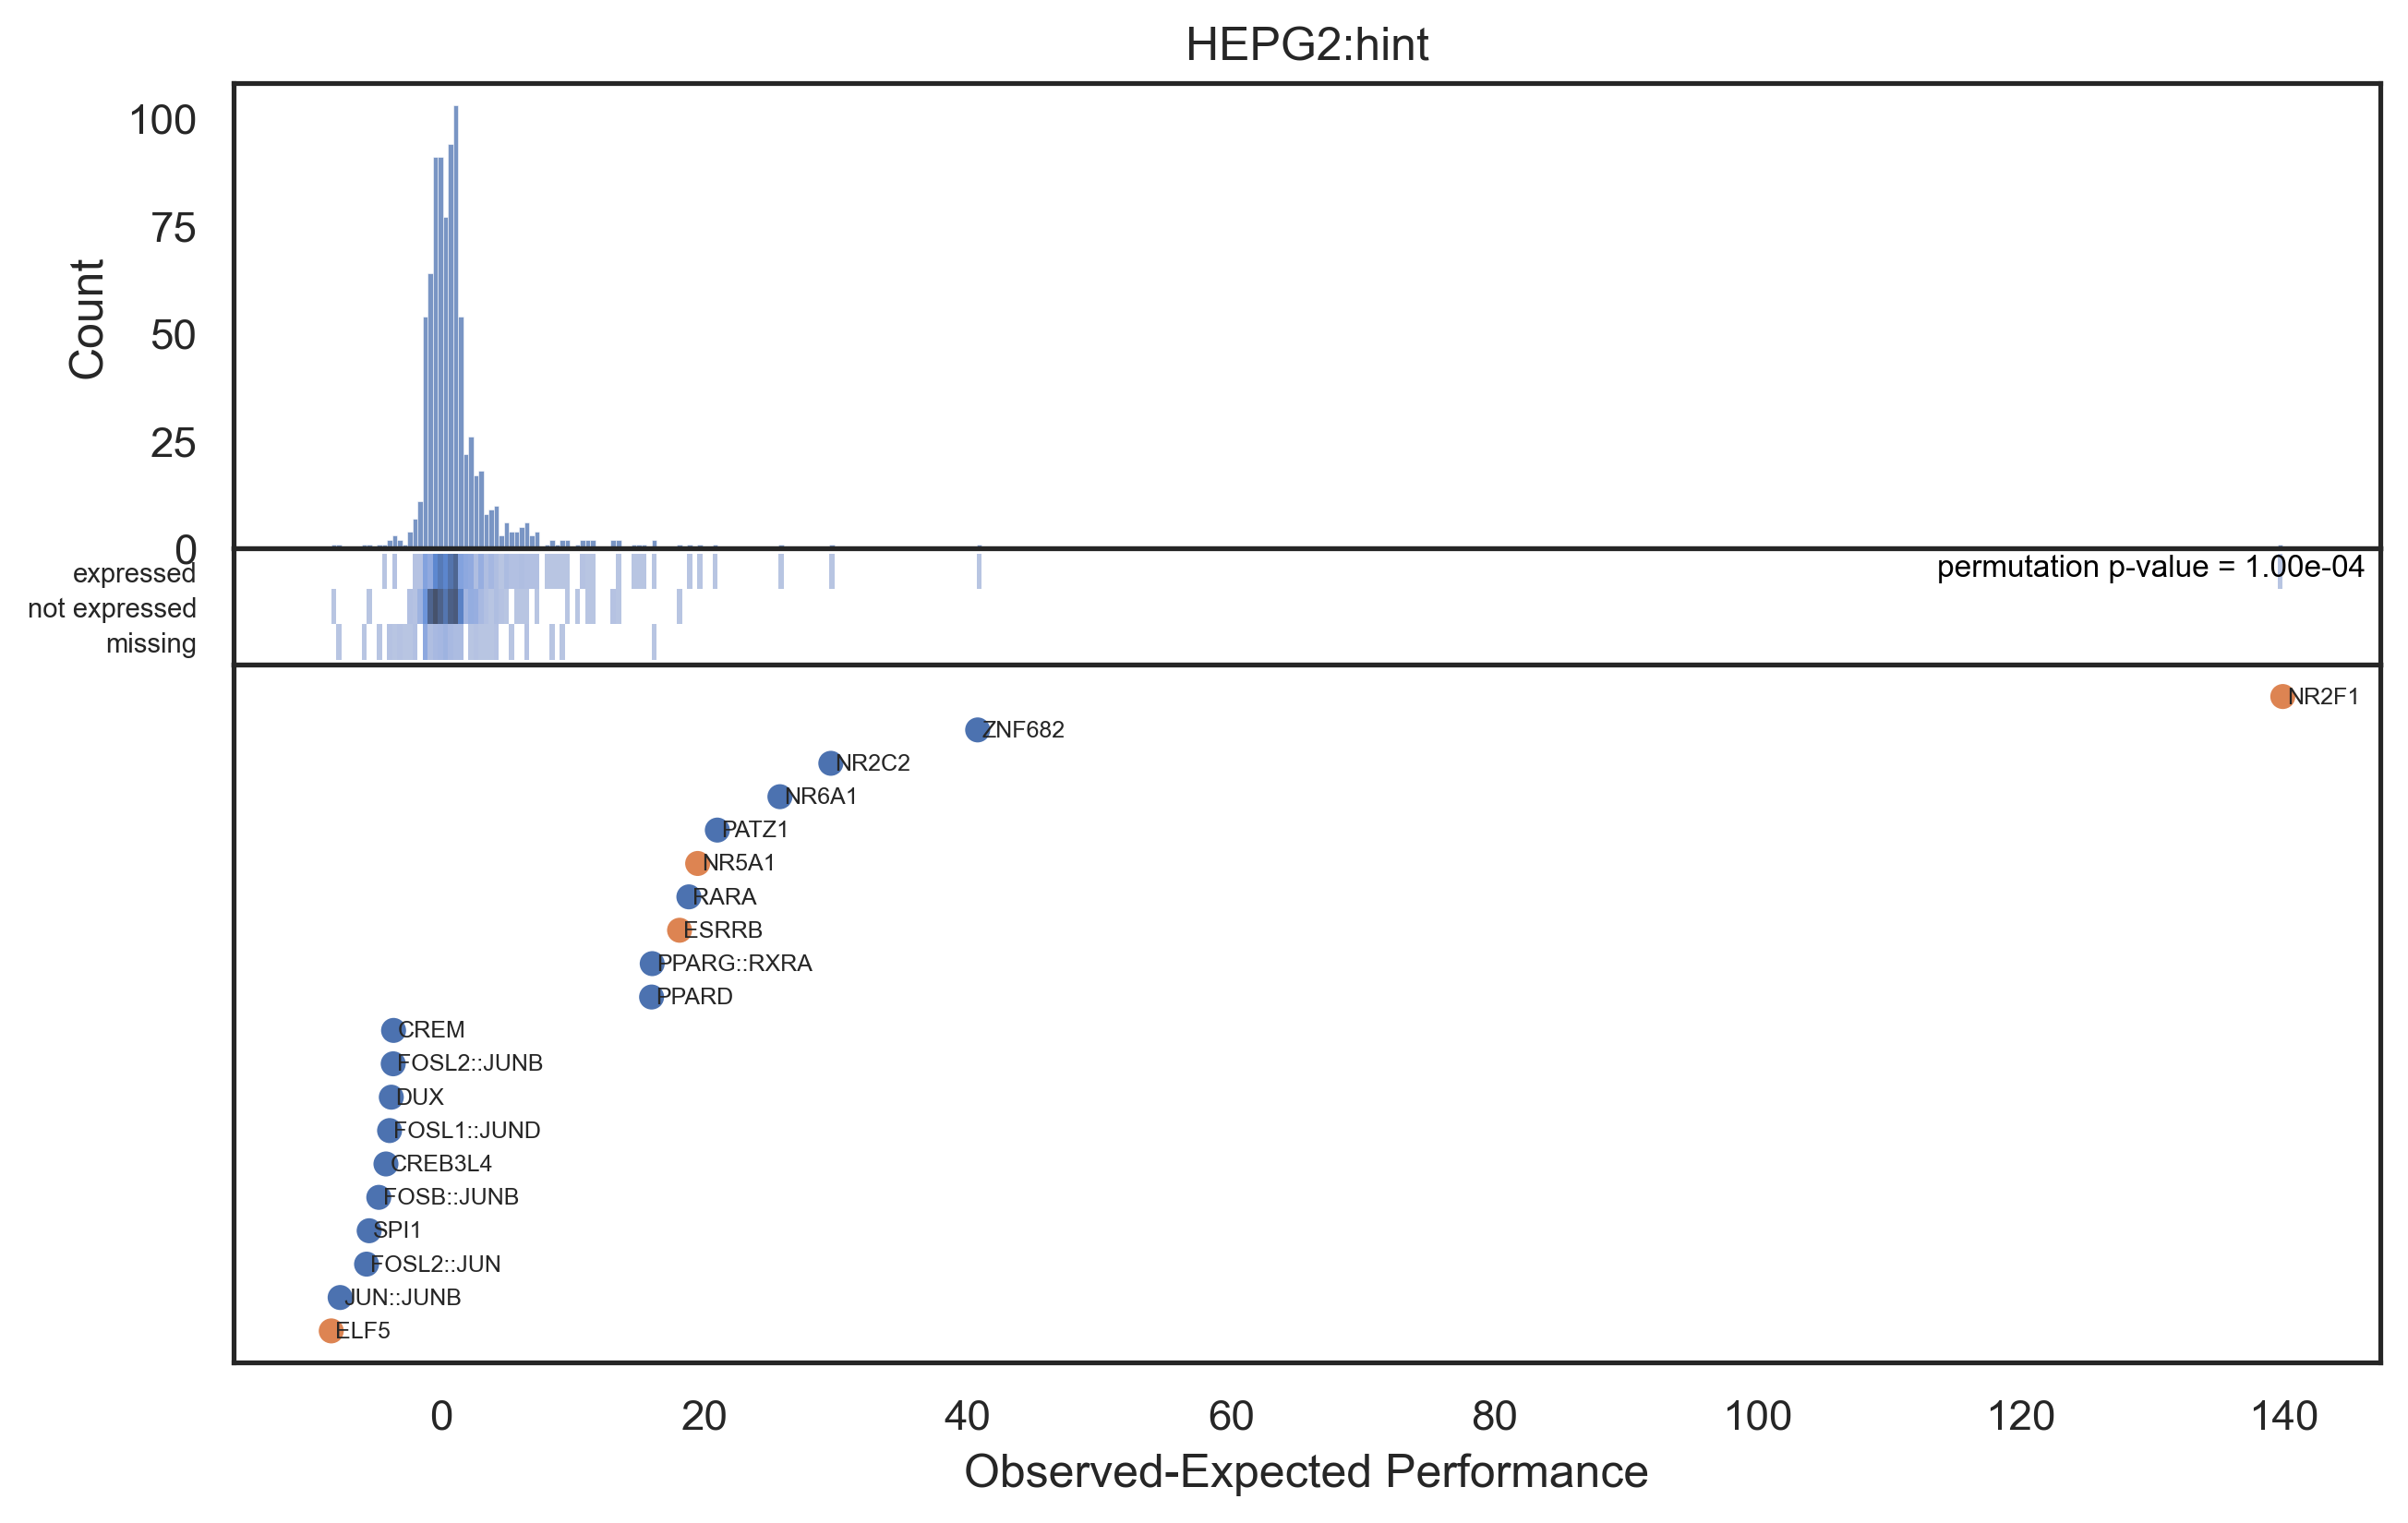

/tmp/ipykernel_69698/972722823.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(["expressed", "not expressed", "missing"], fontsize=7)


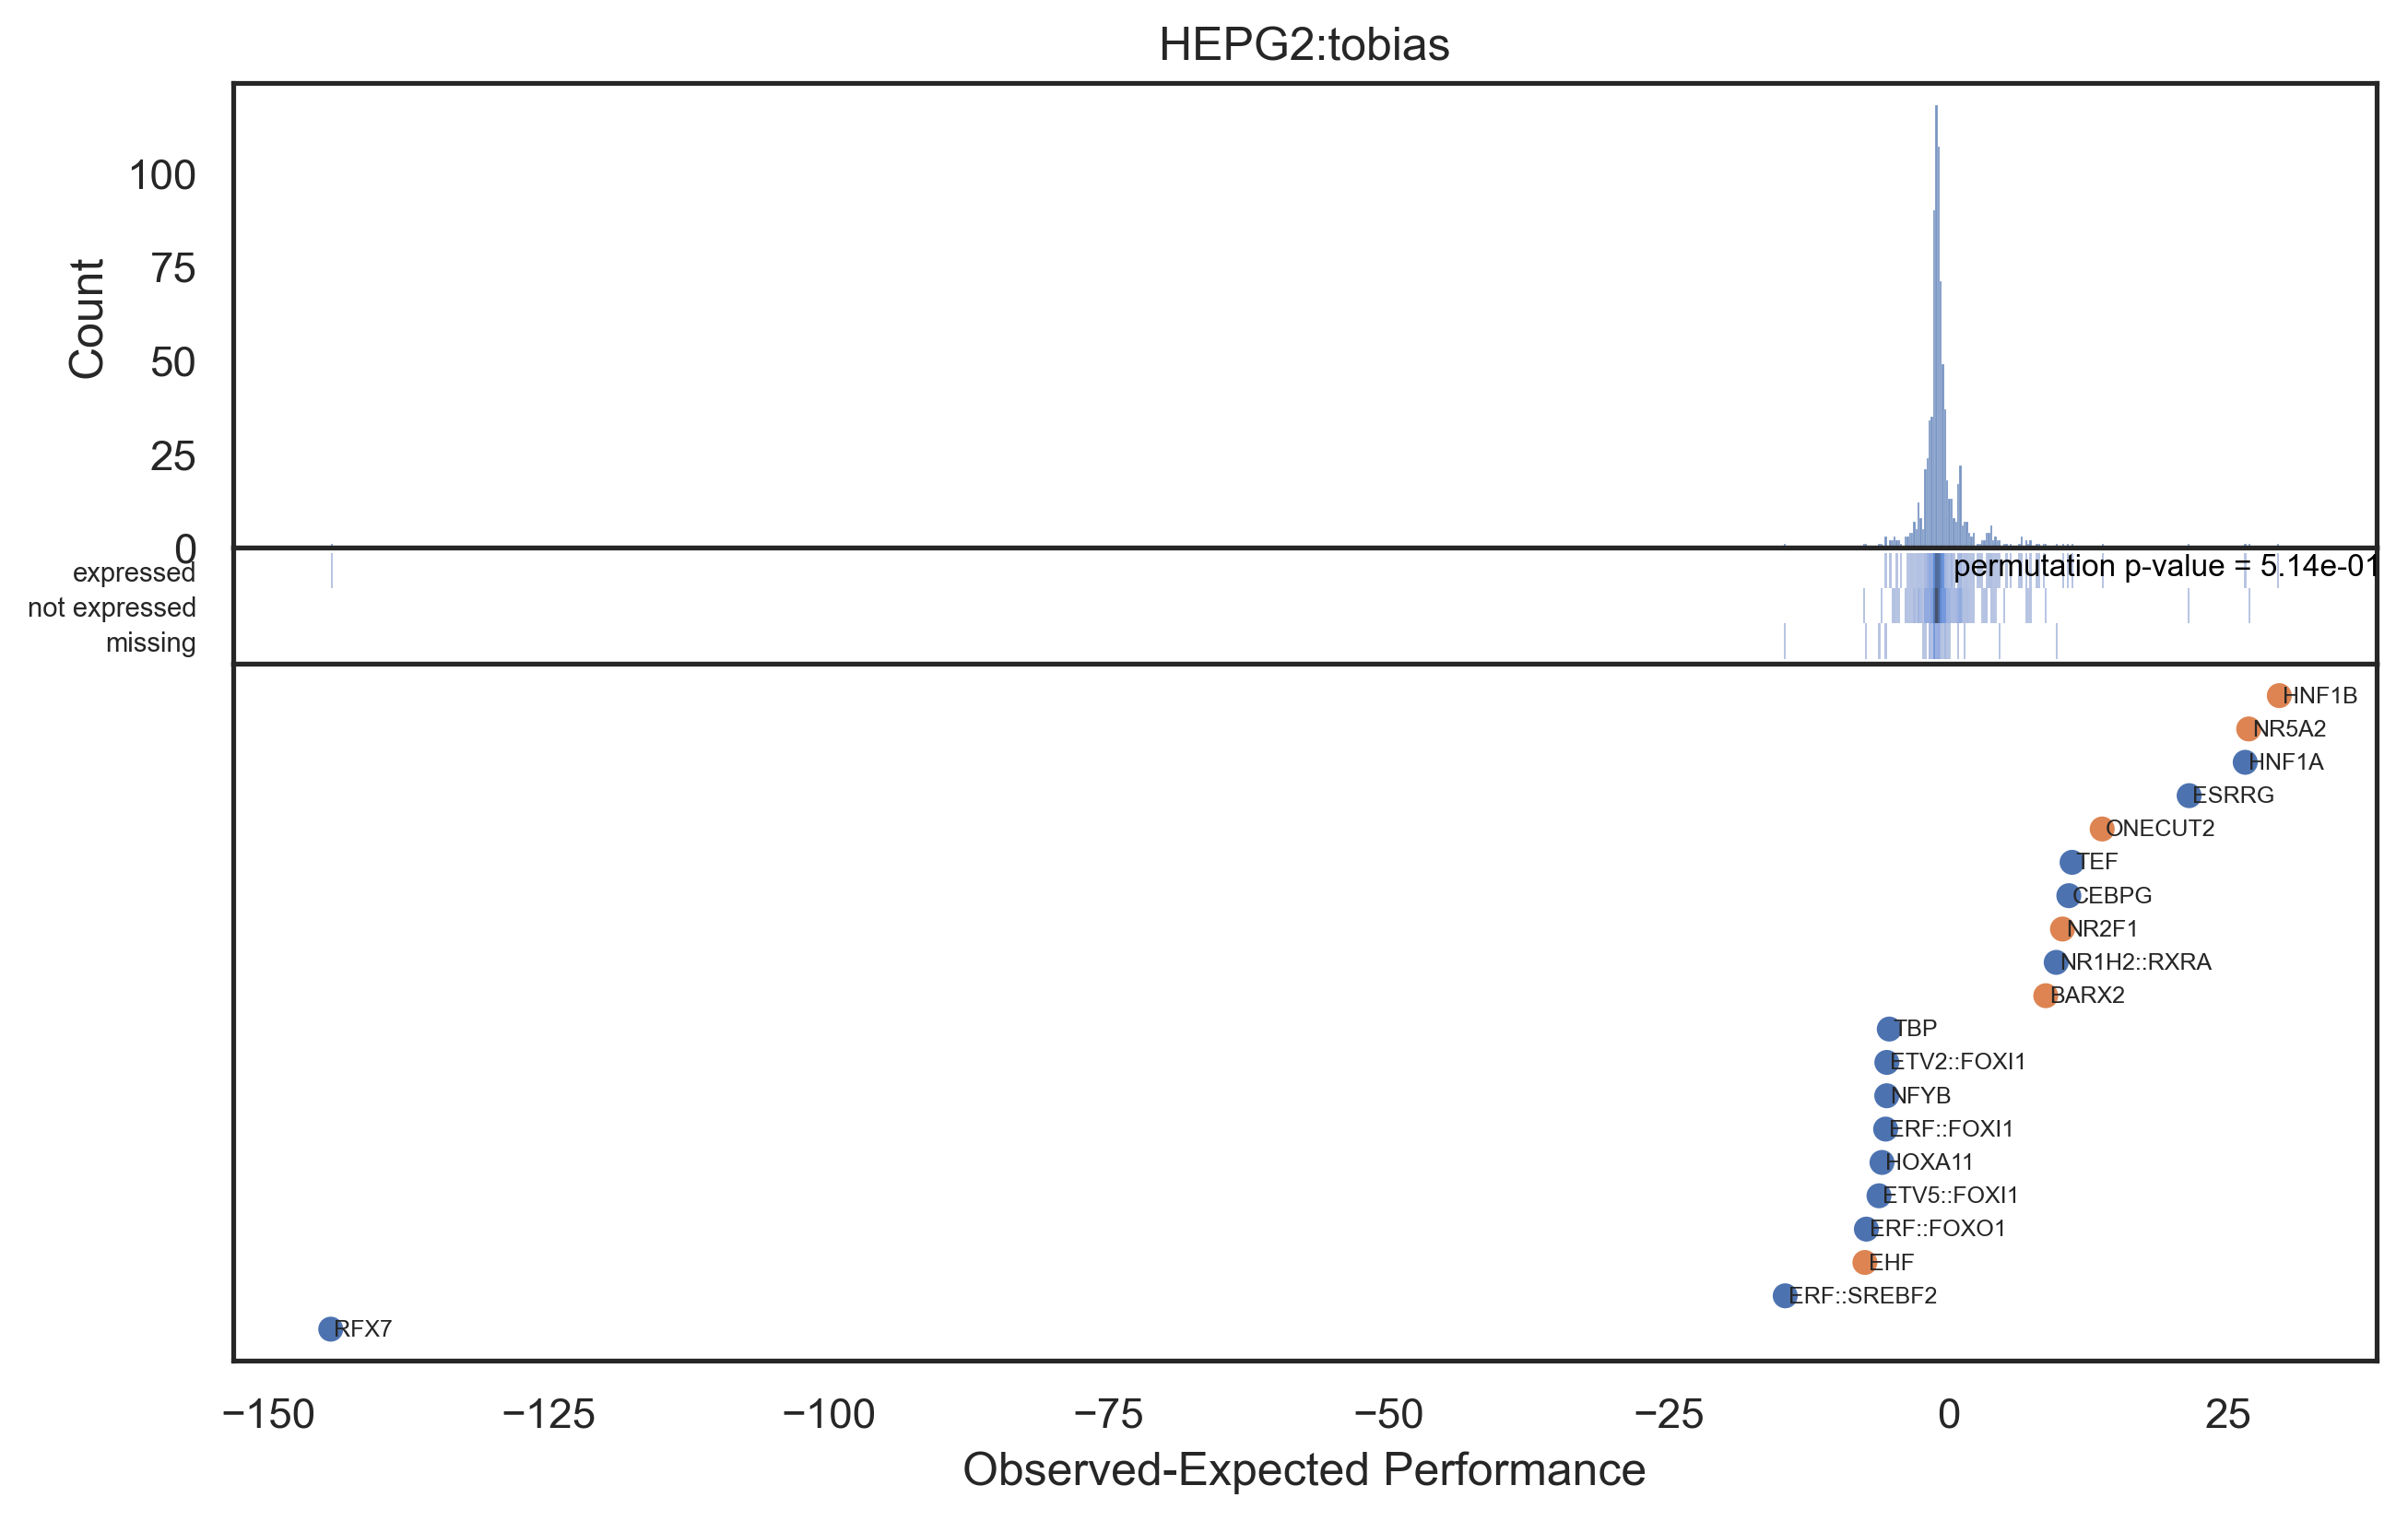

/tmp/ipykernel_69698/972722823.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(["expressed", "not expressed", "missing"], fontsize=7)


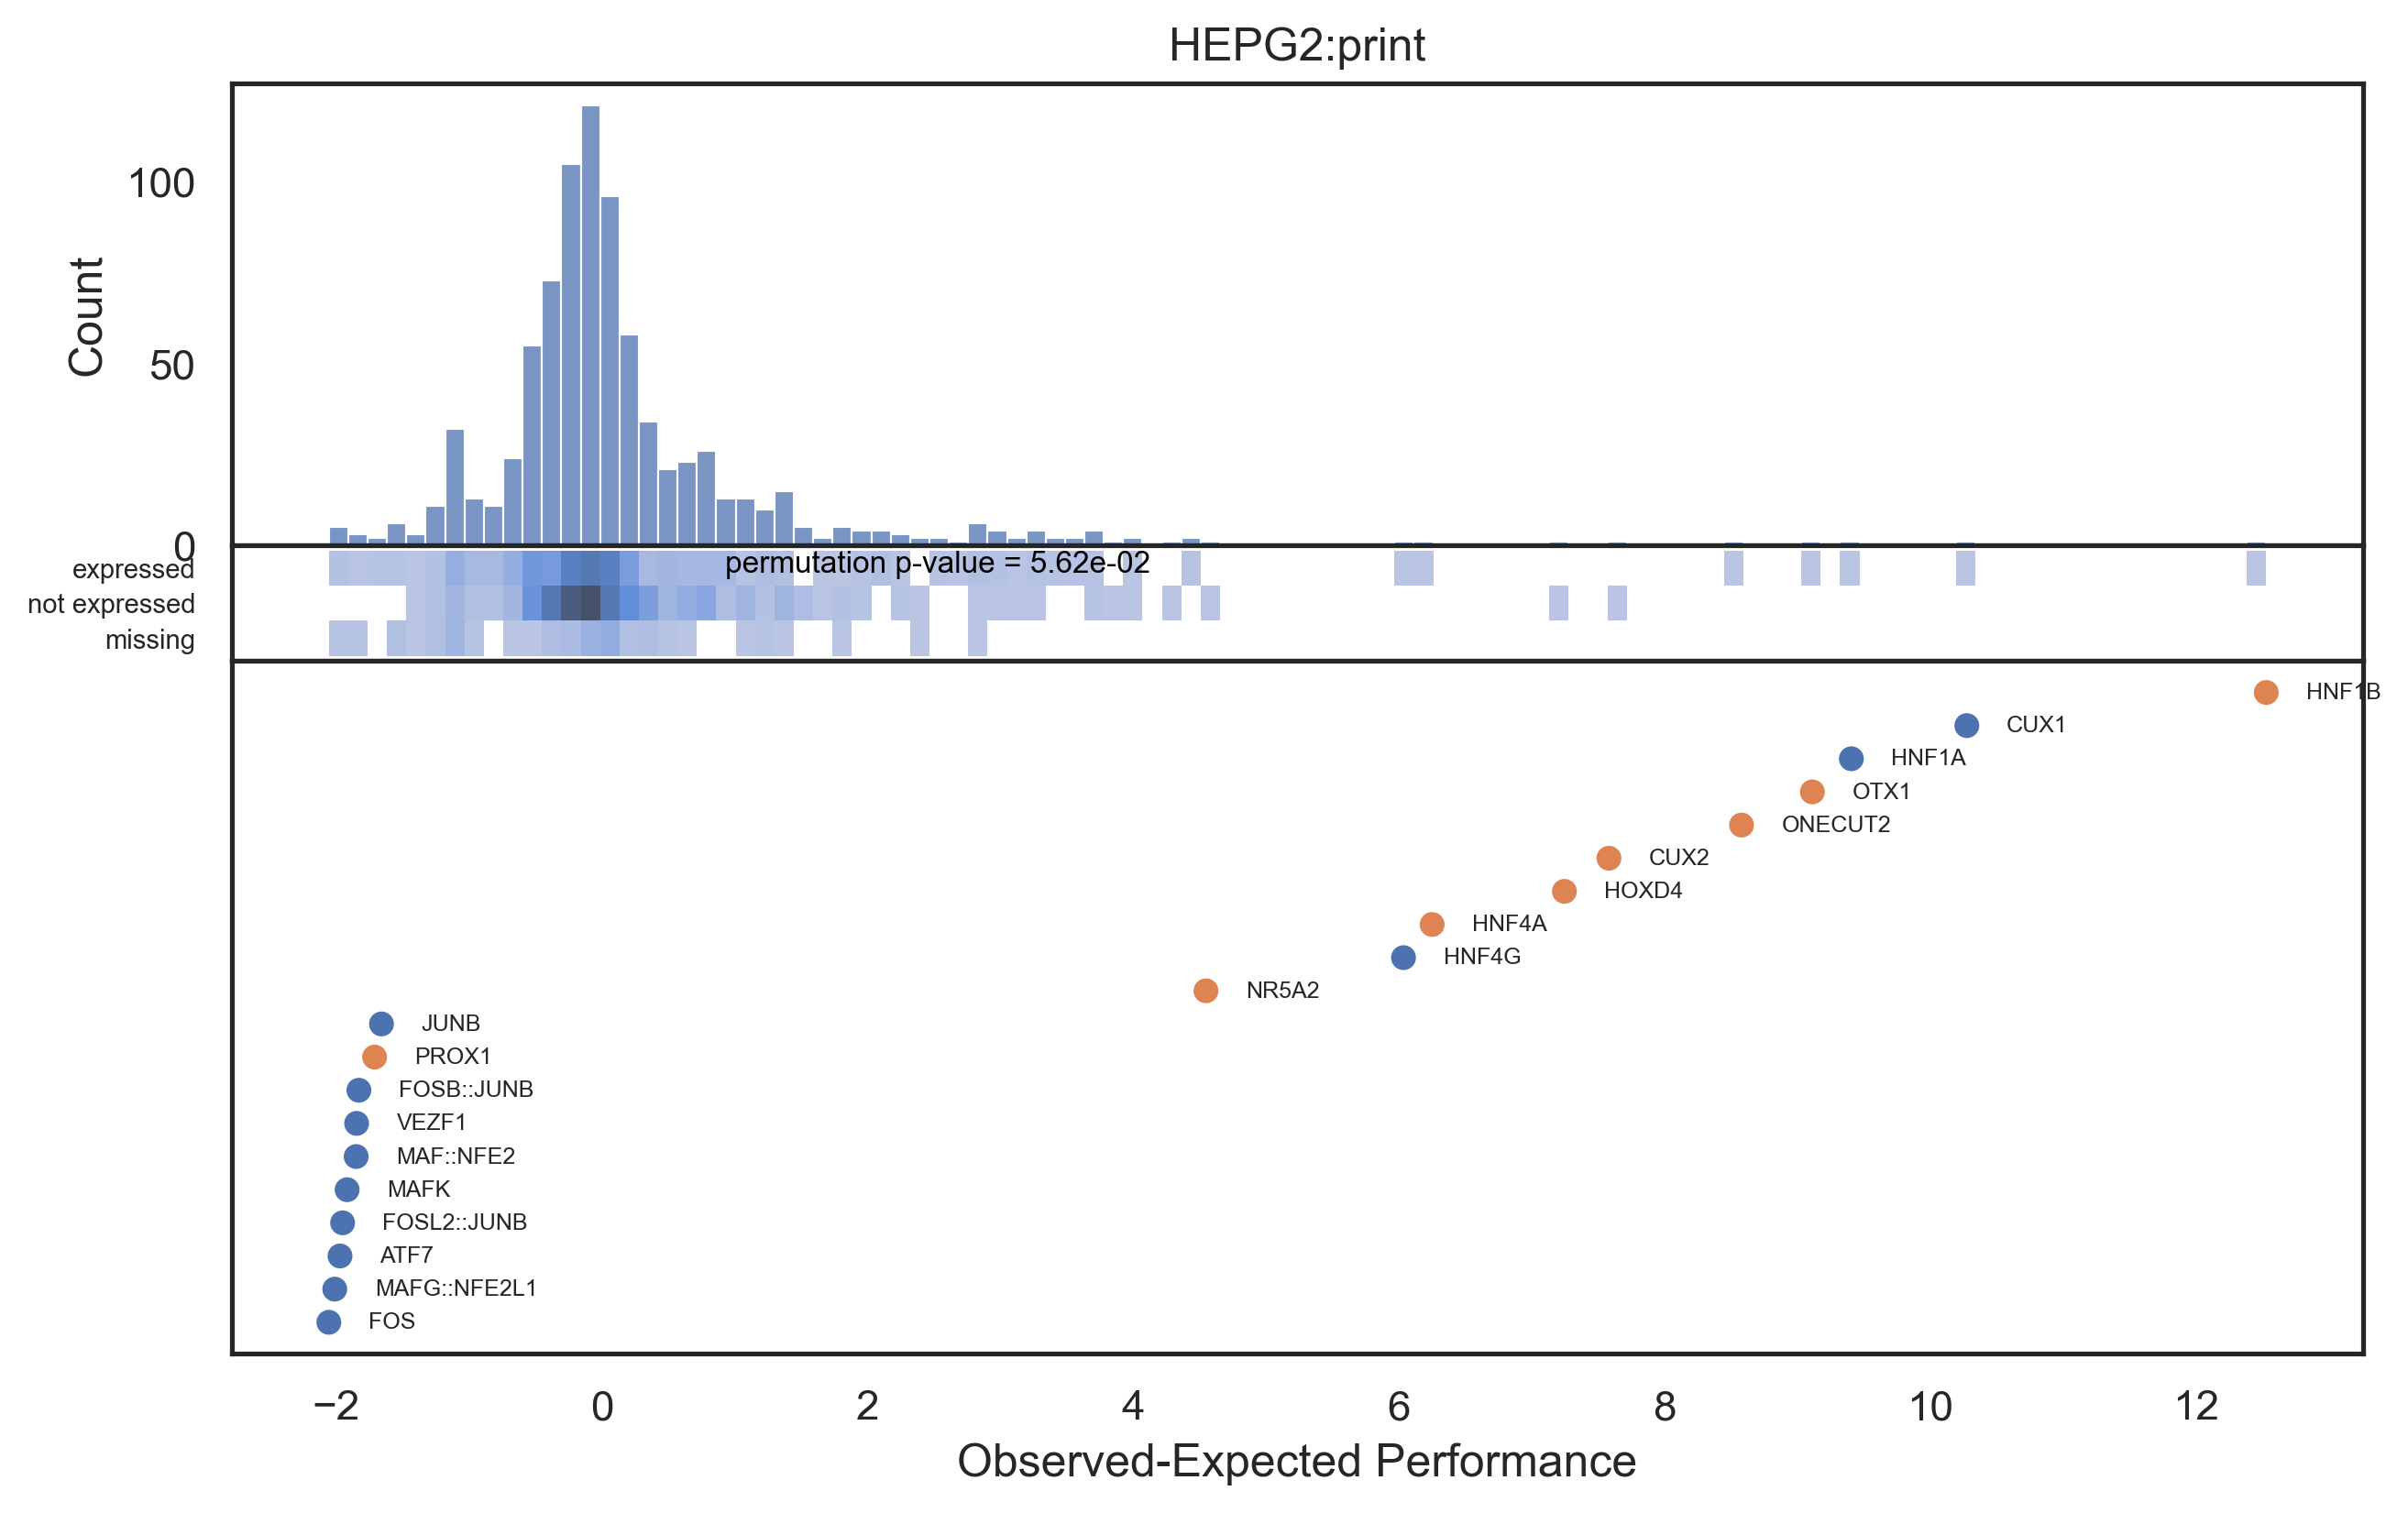

In [155]:
from scipy.stats import permutation_test

def _permtest(group1, group2):
    res = permutation_test((group1, group2), 
                       statistic=lambda x, y: np.mean(x) - np.mean(y), 
                       n_resamples=10000, alternative='greater')
    return res
    

def _check_known_gene(tf_value, knowngenes):
    parts = tf_value.split("::")
    return 1 if any(part in knowngenes for part in parts) else 0


def _load_data(cl, tool, skip=False):
    tmp = observed_df[(observed_df.cell_line==cl) & (observed_df.tool==tool)].copy()
    
    if skip:
        return tmp
    
    else:
        knowngenes = pd.read_csv(f"../06_dataquality/{cl}_genes.txt", sep="\t", comment="#", names=["tf","support"], header=1)
        knowngenes = knowngenes.drop_duplicates(subset=['tf'], keep='first')
        #display(knowngenes)

        tmp["known_gene"] = 0
        tmp.loc[tmp["TF"].isin(knowngenes.tf), "known_gene"] = 1

        tofix = tmp[tmp["TF"].str.contains("::")]
        tmp.loc[tmp["TF"].str.contains("::"), "known_gene"] = tofix["TF"].apply(lambda tf_value: _check_known_gene(tf_value, knowngenes.tf))
        return tmp

    

def _threetierplot(cl, tool):
    
    tmp = _load_data(cl, tool, skip=False)
    
    sns.set(style='white')
    fig = plt.figure(figsize=(10,6))
    gs = GridSpec(3,1, figure=fig, wspace=0, height_ratios=[4,1,6], hspace=0)

    ax0 = fig.add_subplot(gs[0])
    sns.histplot(data=tmp, x='o-e', ax=ax0)
    
    ax1 = fig.add_subplot(gs[1], sharex=ax0)
    sns.histplot(data=tmp, y="RNA_expression_bool", x="o-e", ax=ax1)
    res = _permtest(tmp.loc[tmp["RNA_expression_bool"] == "expressed", "o-e"], 
                   tmp.loc[tmp["RNA_expression_bool"] == "not_expressed", "o-e"])
    plt.text(x=max(tmp["o-e"])-10, y=-0.1, s=f'permutation p-value = {res.pvalue:.2e}', 
             horizontalalignment='center', verticalalignment='center', fontsize=8, color='black')


    ax2 = fig.add_subplot(gs[2], sharex=ax0)
    tmp2 = pd.concat([tmp.nlargest(10, "o-e"),
                     tmp.nsmallest(10, "o-e")])
    tmp2["rank"] = tmp2["o-e"].rank()
    sns.scatterplot(data=tmp2, x='o-e', y="rank", s=50, hue="known_gene", ax=ax2)

    for i, row in tmp2.iterrows():
        ax2.text(row['o-e']+0.3, row['rank']-0.2, row['TF'], fontsize=6) 


    ax0.set_title(f"{cl}:{tool}")
    ax0.set_xlabel("")
    ax0.tick_params(axis="x", labelbottom=False)

    ax1.set_ylabel("")
    #ax1.set_yticks([0,1])
    ax1.set_yticklabels(["expressed", "not expressed", "missing"], fontsize=7)
    ax1.tick_params(axis="x", labelbottom=False)

    ax2.set_ylabel("")
    ax2.set_yticks([])
    ax2.xaxis.set_visible(True)
    ax2.tick_params(axis="x", labelbottom=True)
    ax2.set_xlabel("Observed-Expected Performance")
    ax2.legend_.remove()
    plt.show()
    
l = "HEPG2"
_threetierplot(l, "hint")
_threetierplot(l, "tobias")
_threetierplot(l, "print")

In [156]:
def _plotDendrogram(df, cl, knowngenes, add_related=True):
    tokeep = set(df[(df.cell_line==cl) & (df.rank_global<25)]["name"])
    df_pivot = df[df.cell_line==cl].pivot(index="name", columns="tool", values="o-e")
        
    fig = plt.figure(figsize=(6,6))
    gs = GridSpec(1,2, figure=fig, wspace = 0, hspace=0, width_ratios=[1,4])

    #Make dendrogram.
    ax0 = fig.add_subplot(gs[0]) 
    tmp = df_pivot.loc[list(tokeep)]
    tmp.columns = [i.upper() for i in tmp.columns]
    linkage = hierarchy.linkage(tmp.loc[list(tokeep)], method='average')
    dendrogram = hierarchy.dendrogram(linkage, orientation='left', no_labels=True, 
                                      color_threshold=0, 
                                      above_threshold_color='grey', 
                                      ax=ax0)
    ax0.set_facecolor('white')
    ax0.set_xticks([]); ax0.set_xlabel("")

    reordered_indices = dendrogram['leaves']
    tmp_reorder = tmp.reindex(tmp.index[reordered_indices])

    #Plot heatmap of reordered cells. 
    ax1 = fig.add_subplot(gs[1])
    hm = sns.heatmap(tmp_reorder, 
                yticklabels=True, 
                ax=ax1, 
                cmap='BuPu', 
                #cbar_kws={'label': 'Observed-Expected Performance', 'shrink': .5}, 
                cbar=False,
                linewidth=0.2,
                vmin=0, vmax=10)
    ax1.yaxis.tick_right()  
    ax1.yaxis.set_label_position("right")  
    ax1.yaxis.set_tick_params(labelsize=4, right=True, labelright=True, labelrotation=0) 

    known_motifs = []
    
    yticks = ax1.get_yticklabels()
    for label in yticks:
        text = label.get_text()
        text_tf = text.split("_")[0]
        
        if text_tf in set(knowngenes):
            label.set_color("crimson"); label.set_fontweight("bold")
            known_motifs.append(text)
        
        elif (any(part in set(knowngenes) for part in text_tf.split("::"))):
            label.set_color("crimson"); label.set_fontweight("bold")
            known_motifs.append(text)
            
        else:
            label.set_color("grey")
    
    if add_related:
        pwm_corr = pd.read_csv(f"../09_simPWMs/00_constructing_PWMs/PearsonCorr_jasparPWMs.csv", index_col=0)
        related_pwms = pwm_corr[(pwm_corr > 0.95) & (pwm_corr !=1)].stack().reset_index()
        related_pwms.columns = ["TF1", "TF2", "corr"]
        subdf = related_pwms[(related_pwms["TF1"].isin(known_motifs)) | (related_pwms["TF2"].isin(known_motifs))]
        new_set = set(np.concatenate((subdf["TF1"].values, subdf["TF2"].values))) - set(known_motifs)
        
        for label in yticks:
            text = label.get_text()
            if text in new_set:
                label.set_color("salmon")
            

        
    ax1.set_title(cl, fontsize=10)
    ax1.set_ylabel("")
    ax1.set_xlabel("")

    plt.show()
    return

In [147]:
observed_df["rank_global"] = observed_df.groupby(["cell_line", "tool"])["o-e"].rank(ascending=False)

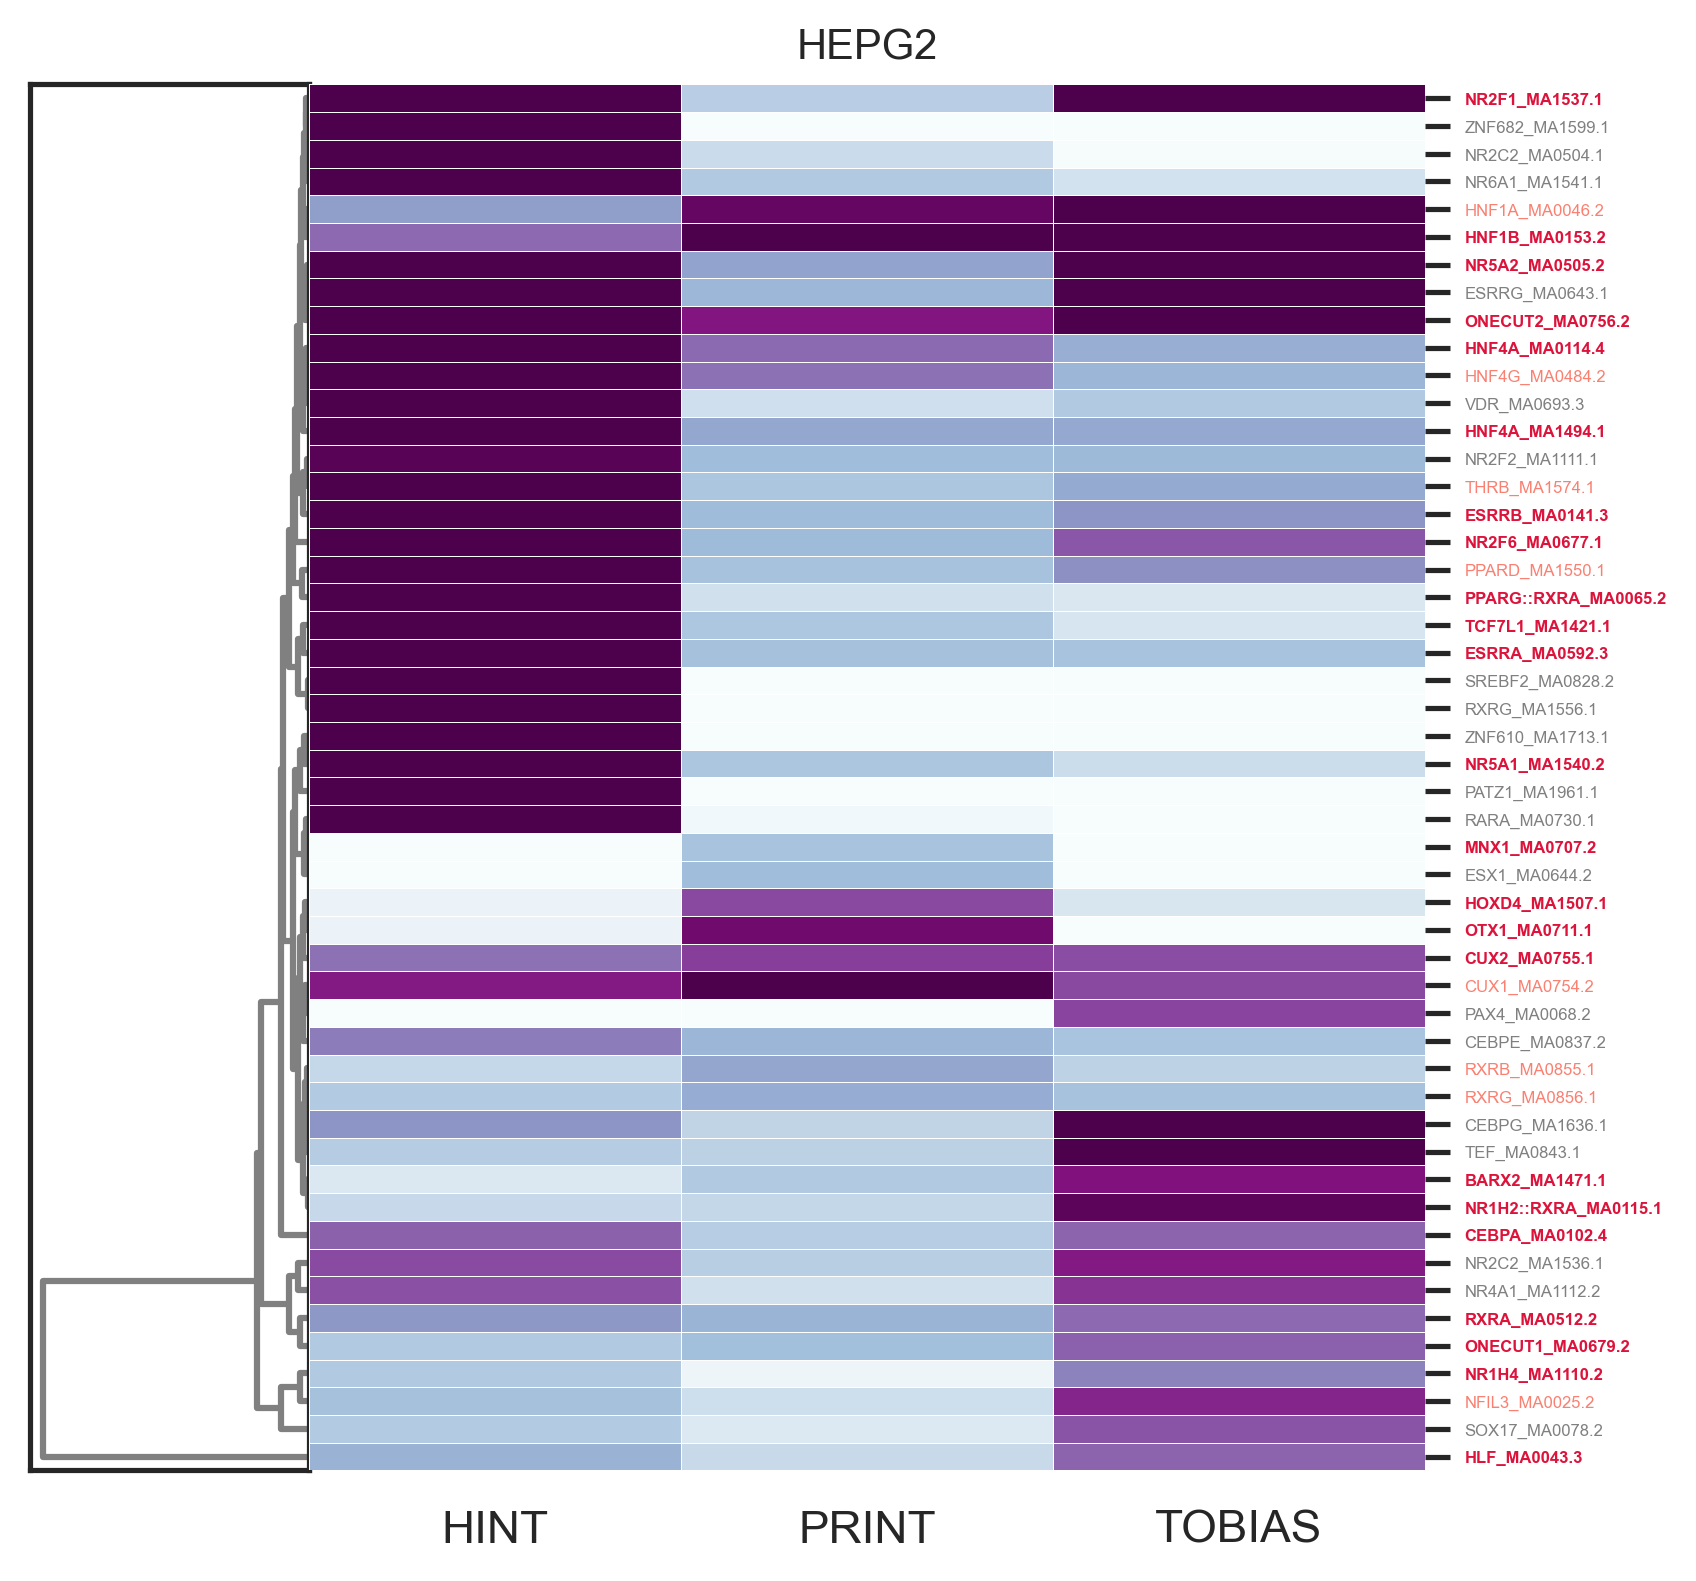

In [148]:
knowngenes = pd.read_csv("../06_dataquality/HEPG2_genes.txt", sep="\t", comment="#", names=["tf","support"], header=1)
knowngenes = knowngenes.drop_duplicates(subset=['tf'], keep='first')

_plotDendrogram(observed_df, "HEPG2", knowngenes.tf)

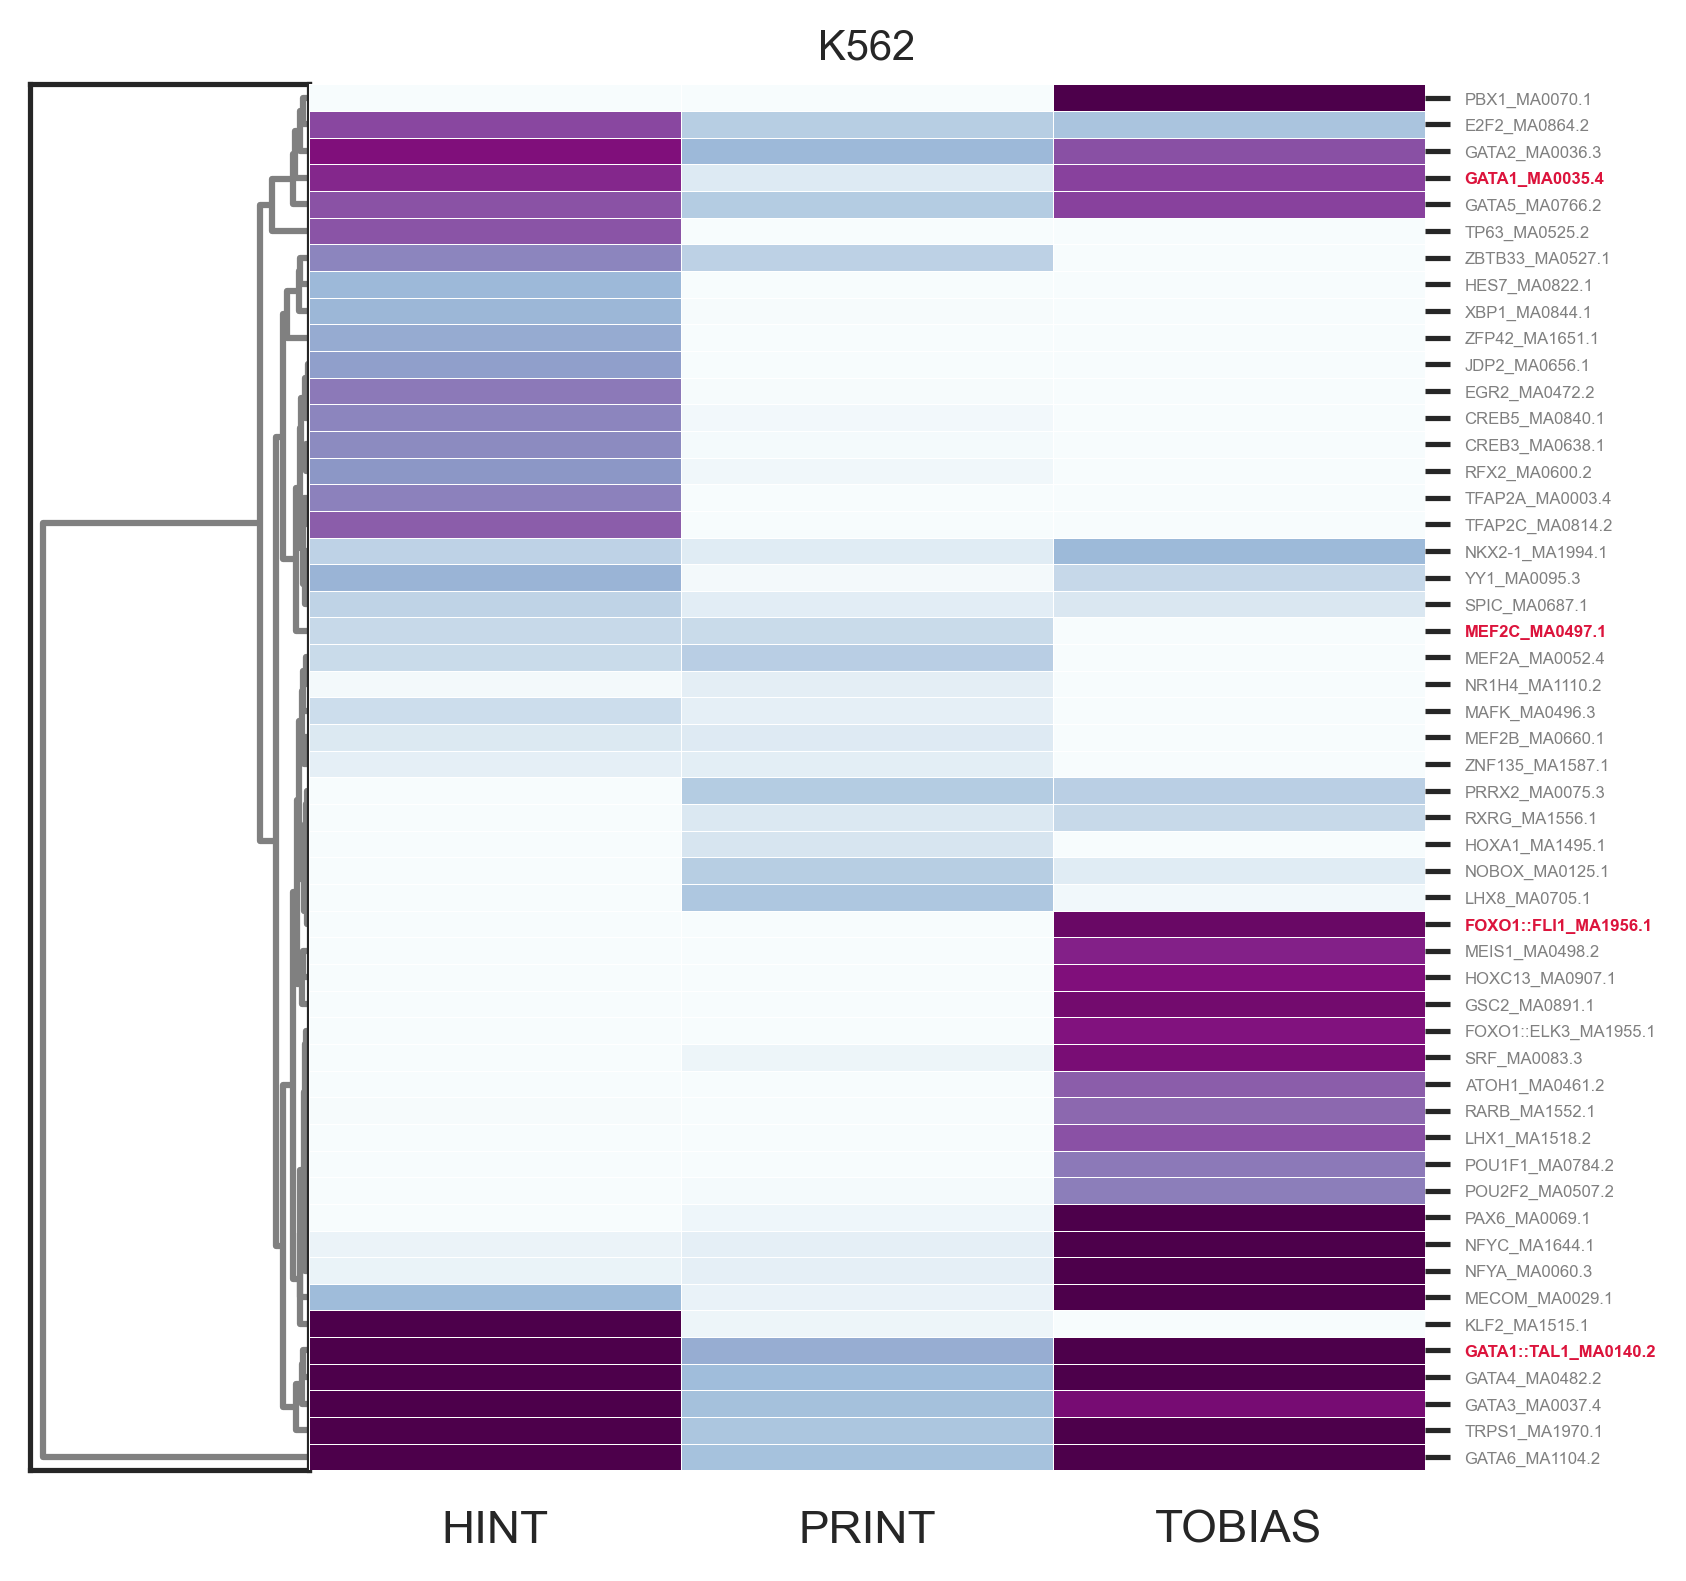

In [149]:
knowngenes = pd.read_csv("../06_dataquality/K562_genes.txt", sep="\t", comment="#", names=["tf","support"], header=1)
knowngenes = knowngenes.drop_duplicates(subset=['tf'], keep='first')

_plotDendrogram(observed_df, "K562", knowngenes.tf)

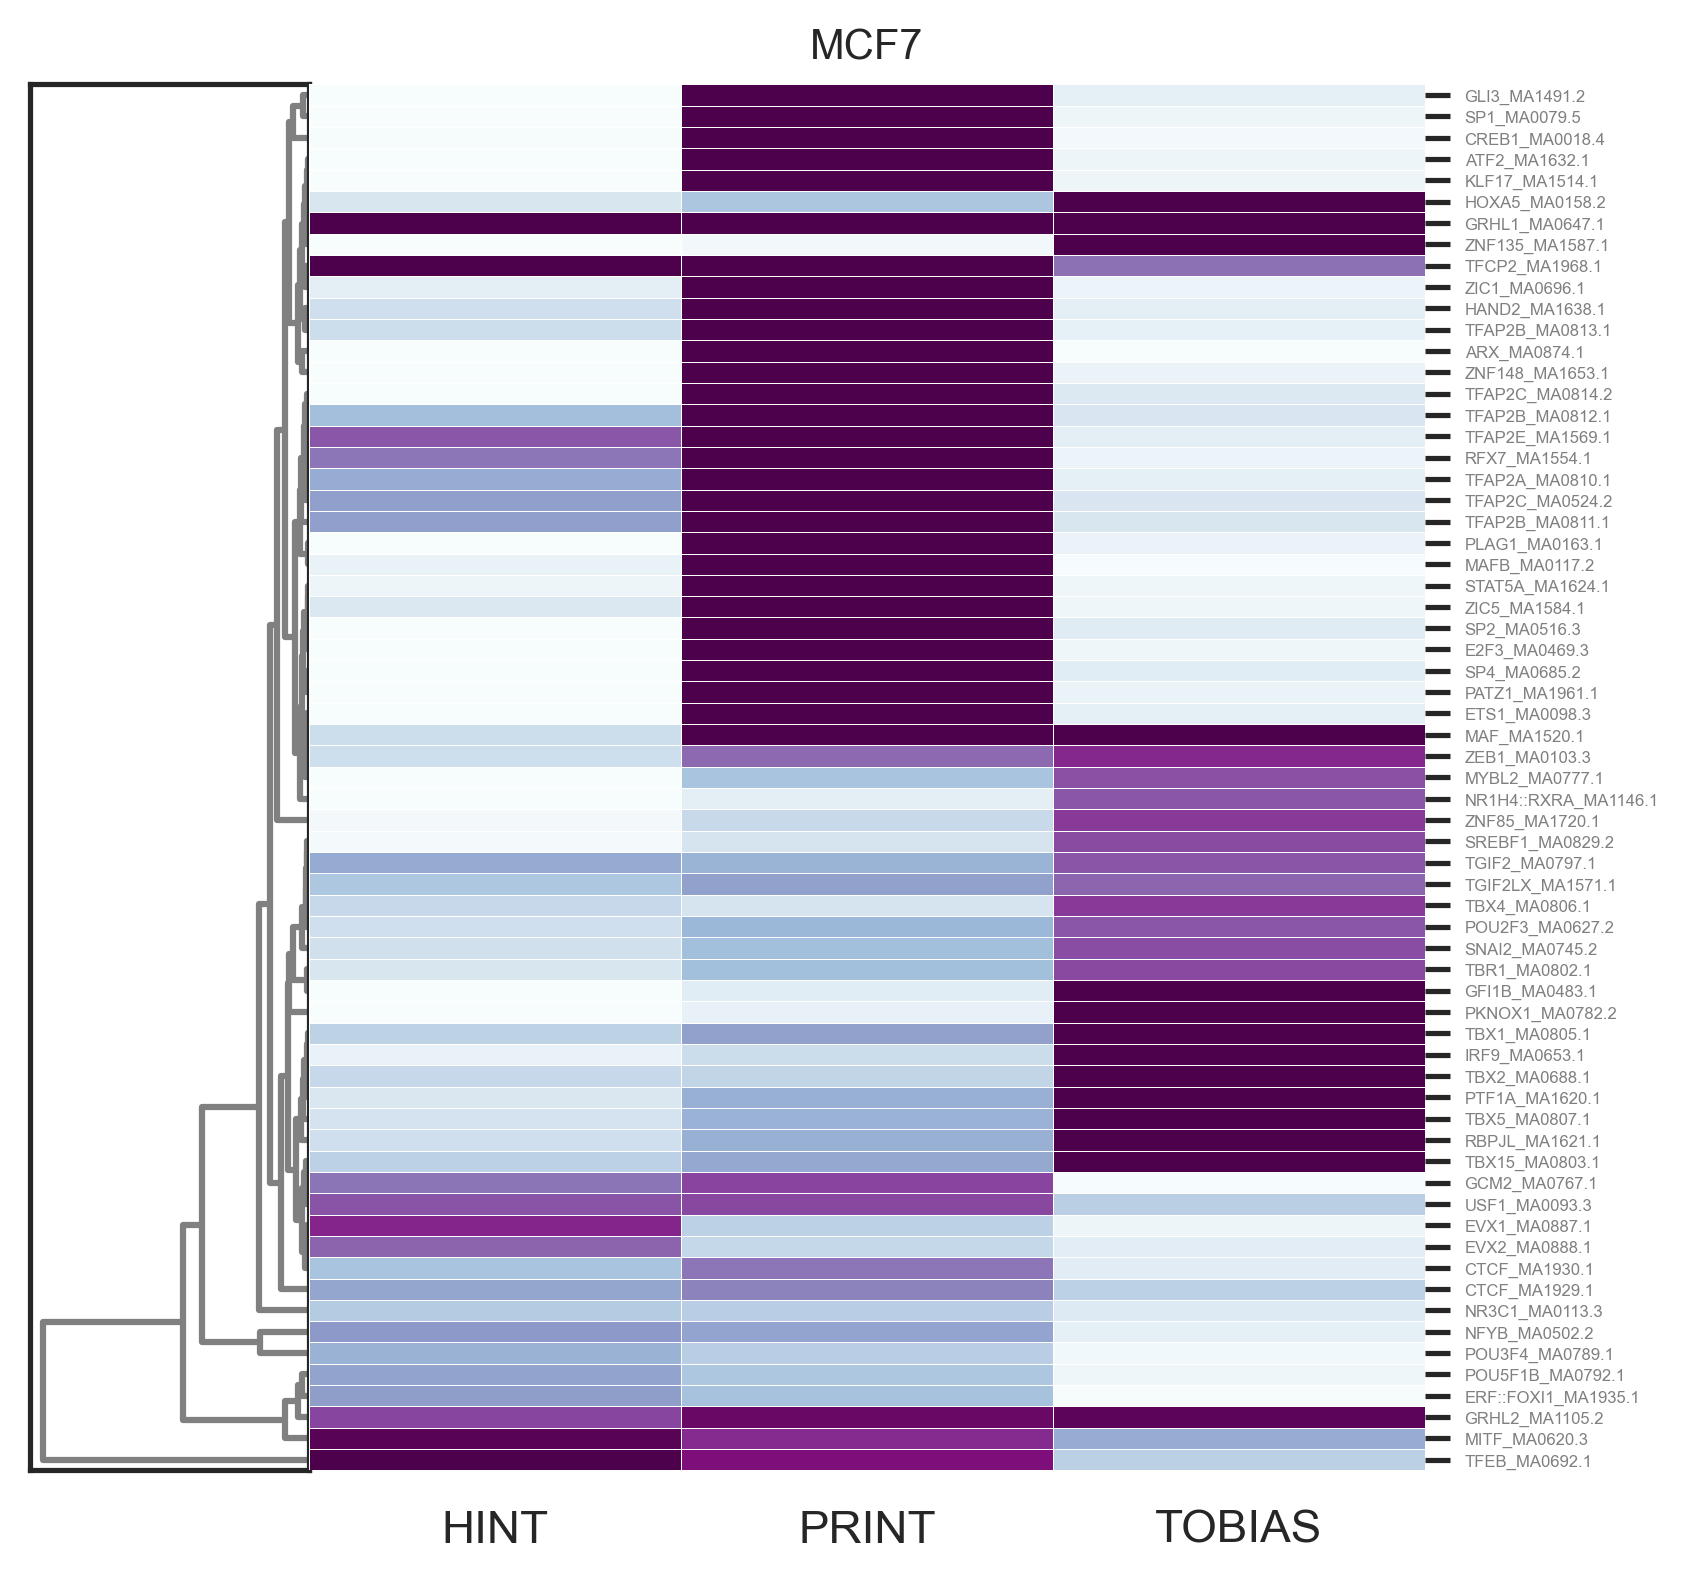

In [150]:
# knowngenes = pd.read_csv("../06_dataquality/MCF7_genes.txt", sep="\t", comment="#", names=["tf","support"], header=1)
# knowngenes = knowngenes.drop_duplicates(subset=['tf'], keep='first')

_plotDendrogram(observed_df, "MCF7", [], add_related=False)

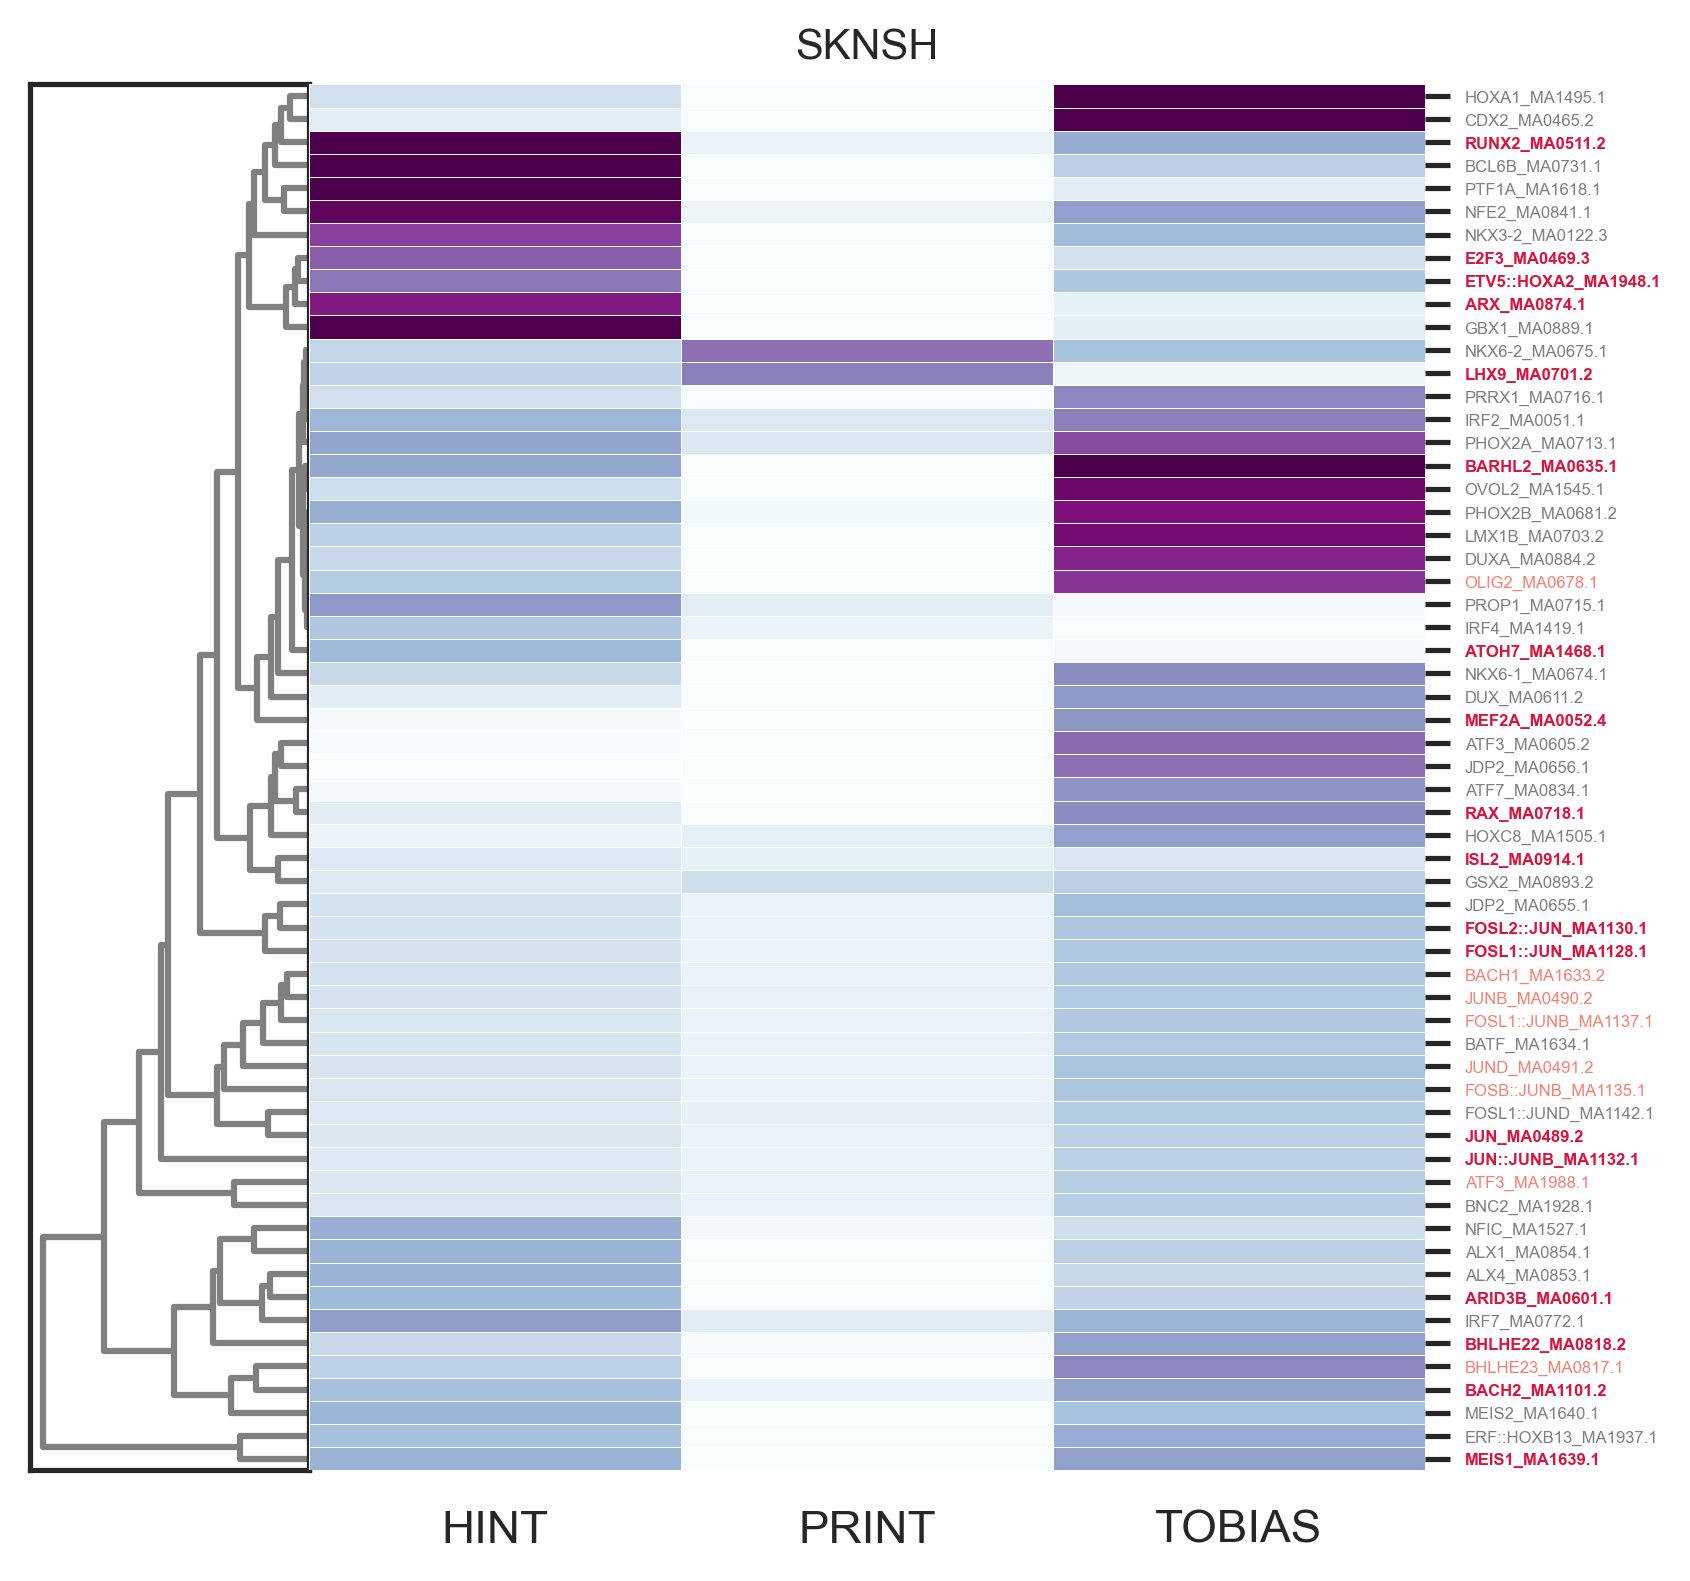

In [151]:
knowngenes = pd.read_csv("../06_dataquality/SKNSH_genes.txt", sep="\t", comment="#", names=["tf","support"], header=1)
knowngenes = knowngenes.drop_duplicates(subset=['tf'], keep='first')

_plotDendrogram(observed_df, "SKNSH", knowngenes.tf)

In [152]:
print("How correlated are the o-e values and the gene expression values?")
observed_df.groupby(["cell_line", "tool"]).apply(lambda group: group["o-e"].corr(group["RNA_expression"]), include_groups=False)


How correlated are the o-e values and the gene expression values?


cell_line  tool  
HEPG2      hint      0.076977
           print     0.055303
           tobias    0.032249
K562       hint      0.019269
           print     0.050645
           tobias   -0.009357
MCF7       hint           NaN
           print          NaN
           tobias         NaN
SKNSH      hint           NaN
           print          NaN
           tobias         NaN
dtype: float64

In [153]:
print("What is the permutation statistic & pvalue given the group sizes?")

def _permtest(group):
    group1 = group[group["RNA_expression_bool"] == "expressed"]["o-e"].values
    group2 = group[group["RNA_expression_bool"] == "not_expressed"]["o-e"].values
    
    if len(group1) == 0:
        return 0
    
    res = permutation_test((group1, group2), 
                       statistic=lambda x, y: np.mean(x) - np.mean(y), 
                       n_resamples=10000, alternative='greater')
    
    return res.statistic, res.pvalue

observed_df.groupby(["cell_line", "tool"]).apply(_permtest, include_groups=False)


What is the permutation statistic & pvalue given the group sizes?


cell_line  tool  
HEPG2      hint      (1.7720848109091436, 9.999000099990002e-05)
           print       (0.15628570816894274, 0.0560943905609439)
           tobias       (0.0641286936766371, 0.5123487651234877)
K562       hint       (0.05638399792106452, 0.41505849415058493)
           print      (0.02745933007485224, 0.34806519348065196)
           tobias     (-0.32770235817520377, 0.8558144185581442)
MCF7       hint                                                0
           print                                               0
           tobias                                              0
SKNSH      hint                                                0
           print                                               0
           tobias                                              0
dtype: object

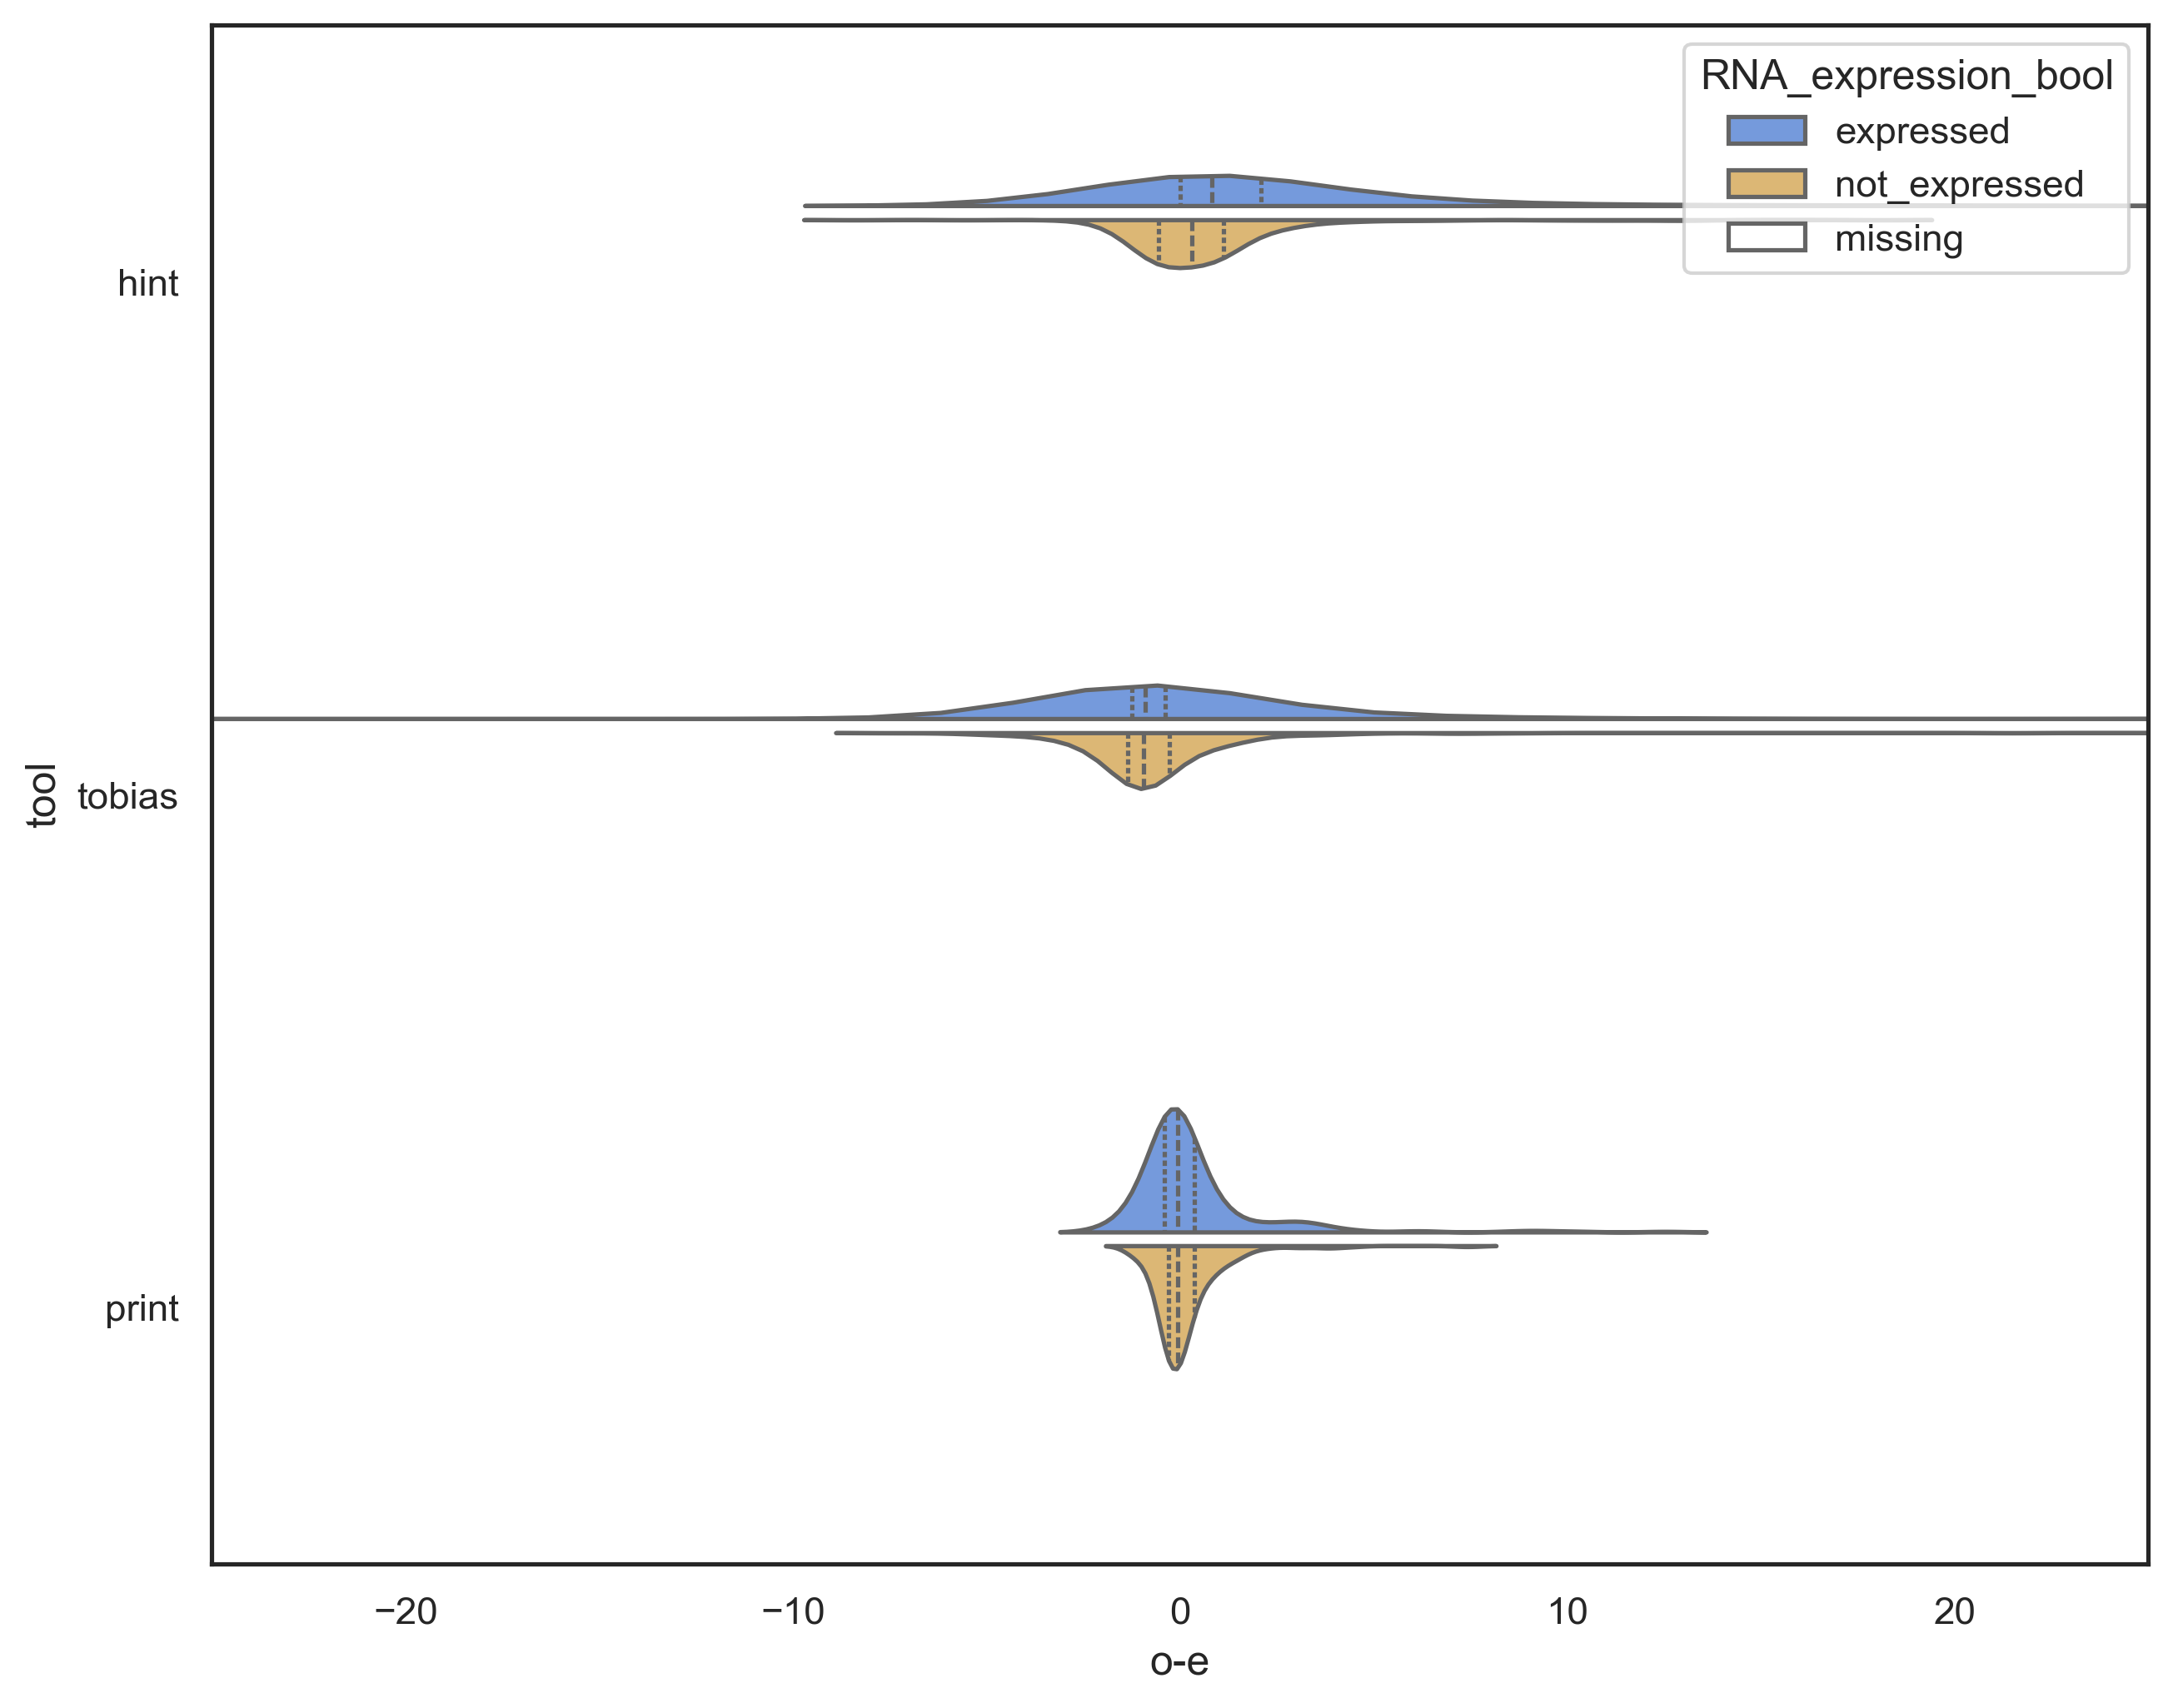

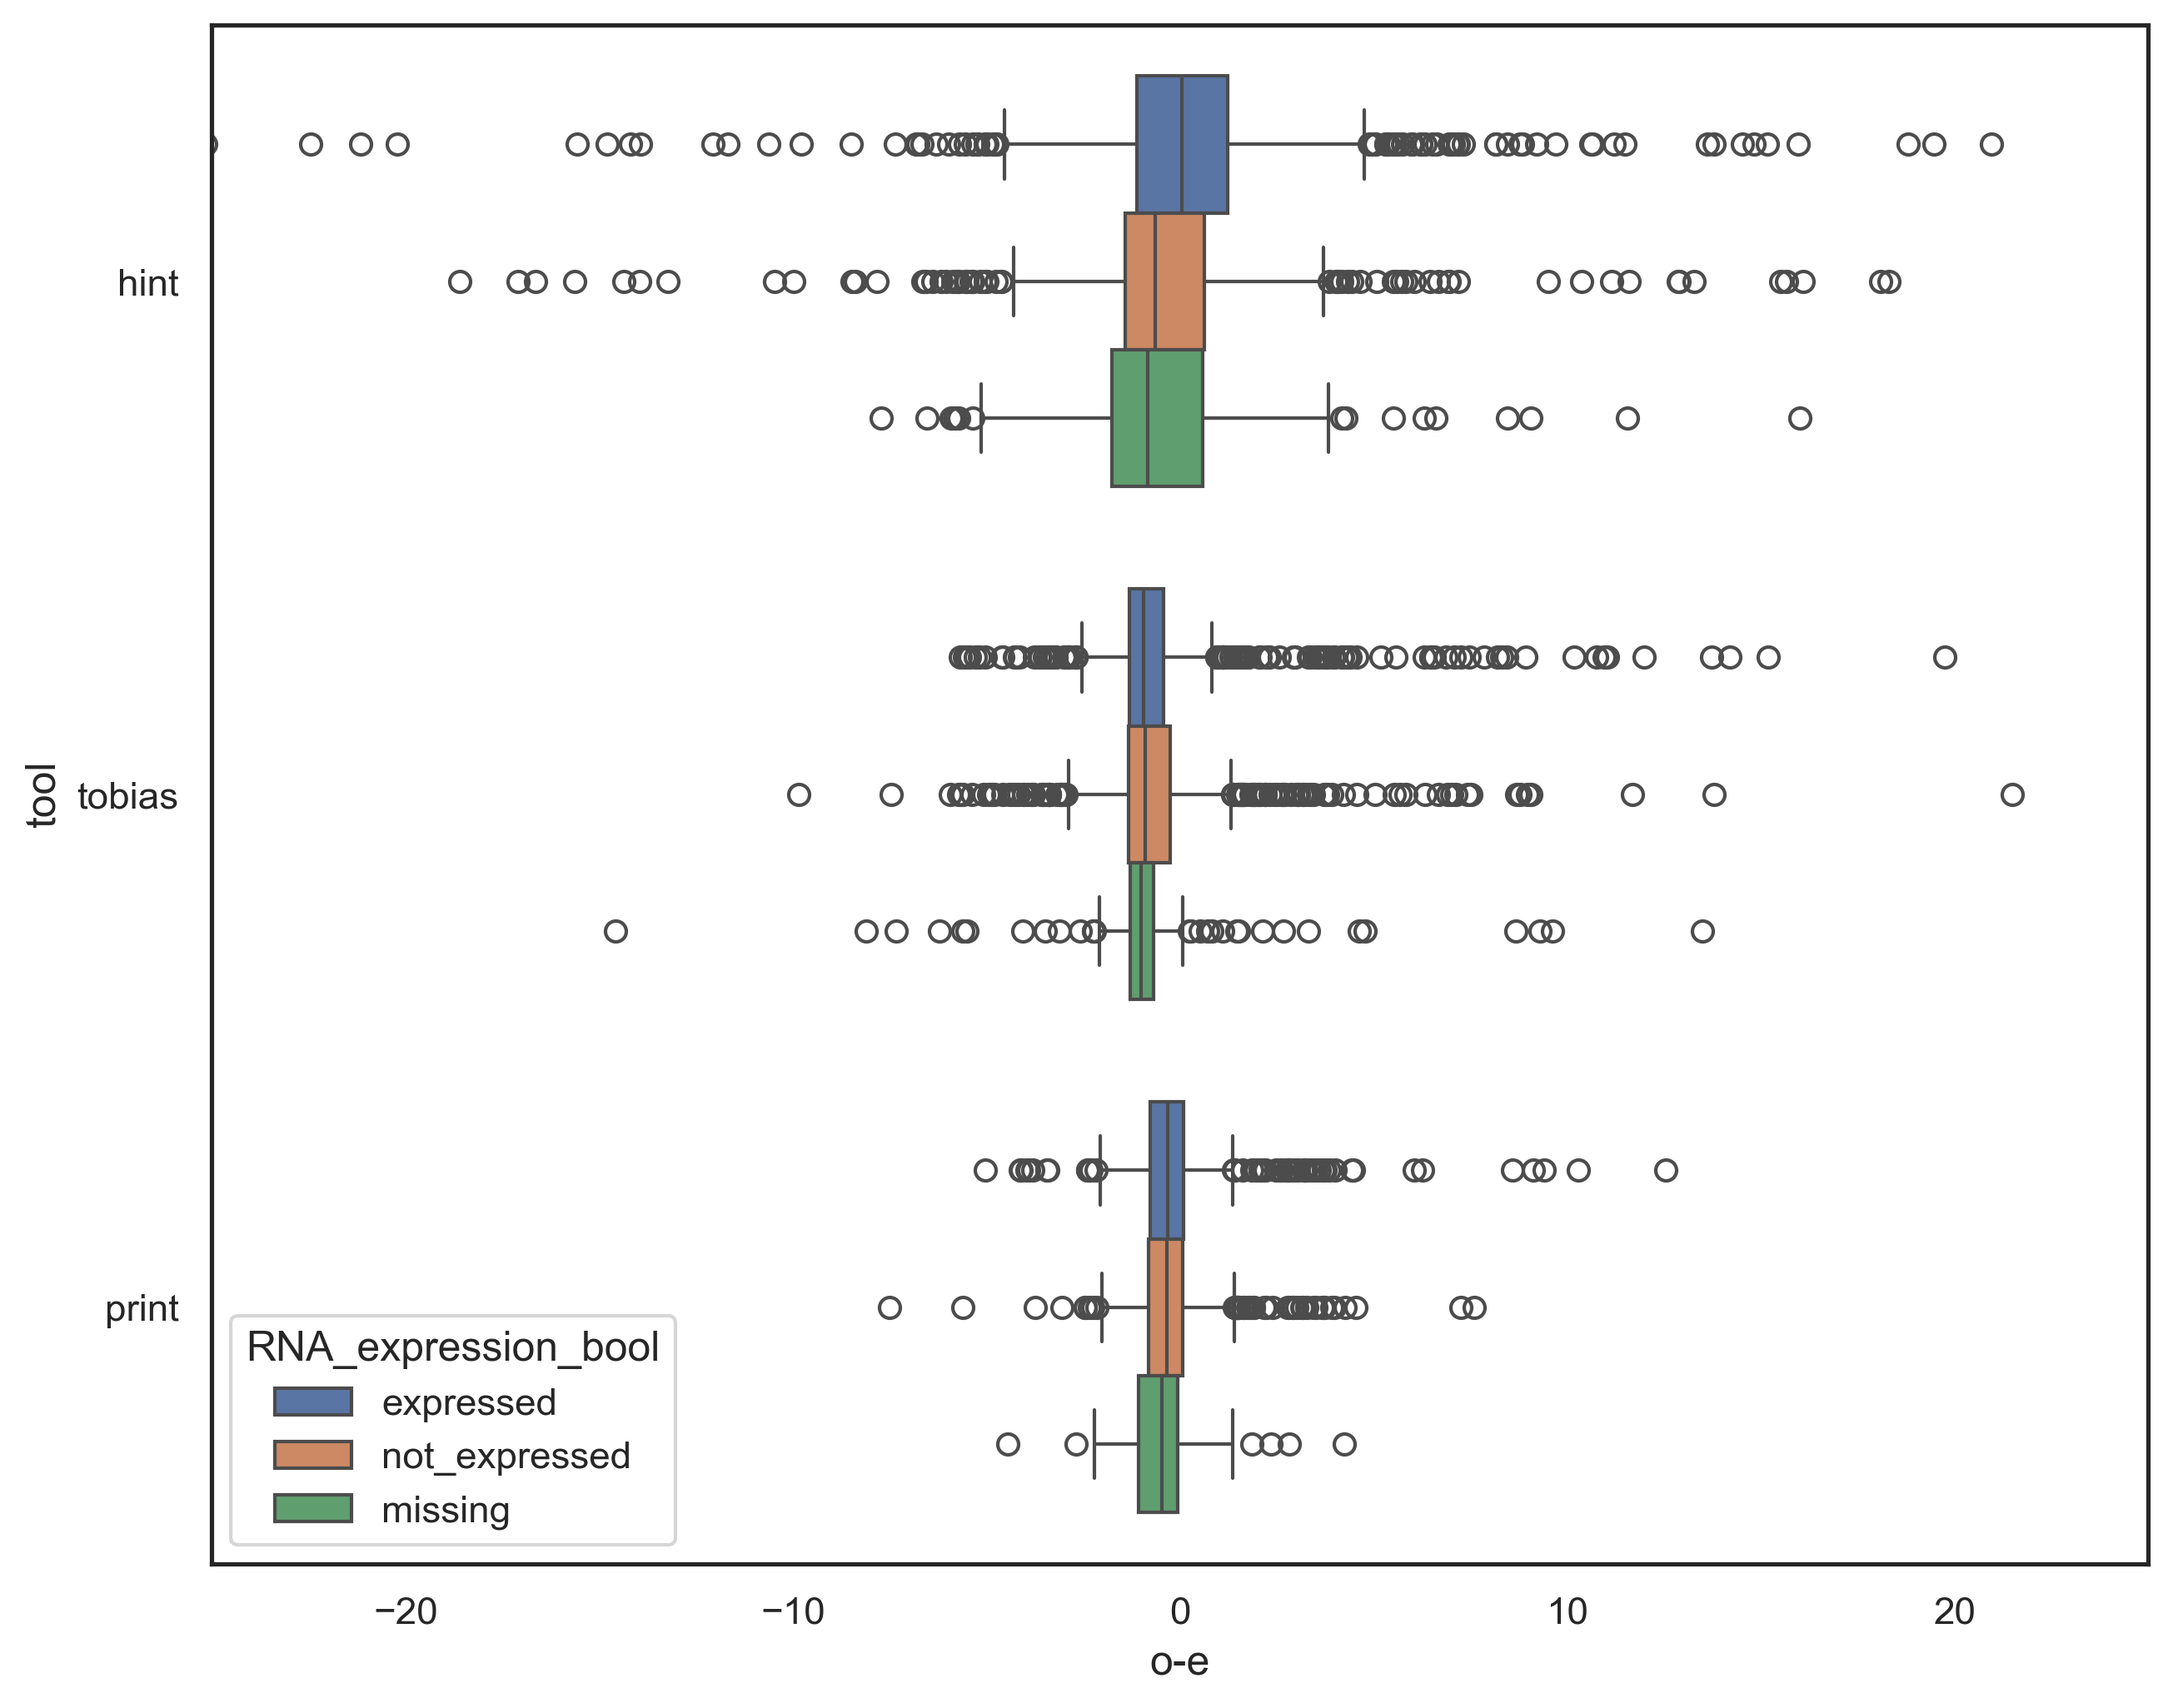

In [157]:
sns.set(font_scale=1, style='white')
fig = plt.figure(figsize=(10,8))
gs = GridSpec(1, 1, figure=fig, hspace=0.5)

ax = fig.add_subplot(gs[0])

tmp = observed_df[(observed_df["RNA_expression_bool"].isin(["not_expressed", "expressed"])) & 
                  (observed_df["cell_line"] == "HEPG2")]
sns.violinplot(data=tmp, 
               x="o-e", 
               y="tool", palette={"expressed":"#6495ED", "not_expressed":"#EDBC64", "missing":"white"},
               hue="RNA_expression_bool", split=True, gap=.1, inner="quart", ax = ax)

ax.set_xlim(-25,25)
plt.show()

sns.set(font_scale=1, style='white')
fig = plt.figure(figsize=(10,8))
gs = GridSpec(1, 1, figure=fig, hspace=0.5)

ax = fig.add_subplot(gs[0])
sns.boxplot(data=observed_df[(observed_df["cell_line"].isin(["HEPG2", "K562"]))], 
               x="o-e", 
               y="tool", 
               hue="RNA_expression_bool", ax=ax)

ax.set_xlim(-25,25)
plt.show()

## 5.2 by kendall-tau rank <a class="anchor" id="fifth2-bullet"></a>

In [3]:
genome_wide_PWM = pd.read_csv("baseline_pwmdf.csv", index_col=0)

#create random shuffle of #footprints
genome_wide_PWM['#footprints_shuffled'] = (
    genome_wide_PWM.groupby(["tool", "cell_line"])['#footprints']
      .transform(lambda x: np.random.permutation(x.values))
)

#gather pct occupied instead of footprints
pwm_values = genome_wide_PWM[genome_wide_PWM["tool"] == "pwm"].set_index(["TF", "cell_line"])["#footprints"]
genome_wide_PWM["pwm_ref"] = genome_wide_PWM.set_index(["TF", "cell_line"]).index.map(pwm_values)
genome_wide_PWM["pct_occupied"] = (genome_wide_PWM["#footprints"] / genome_wide_PWM["pwm_ref"]) * 100

#create random shuffle of that
genome_wide_PWM['pct_occupied_shuffled'] = (
    genome_wide_PWM.groupby(["tool", "cell_line"])['pct_occupied']
      .transform(lambda x: np.random.permutation(x.values))
)

genome_wide_PWM.index = genome_wide_PWM.TF
display(genome_wide_PWM)

,TF,#footprints,tool,cell_line,#footprints_shuffled,pwm_ref,pct_occupied,pct_occupied_shuffled
TF,,,,,,,,
BATF::JUN_MA0462.2,BATF::JUN_MA0462.2,13253,hint,HEPG2,43293,547468,2.420781,2.232061
BATF_MA1634.1,BATF_MA1634.1,13409,hint,HEPG2,8739,569718,2.353621,0.524490
FOSB::JUNB_MA1135.1,FOSB::JUNB_MA1135.1,15636,hint,HEPG2,39167,260314,6.006592,3.330970
FOSL2::JUNB_MA1138.1,FOSL2::JUNB_MA1138.1,15616,hint,HEPG2,6948,241153,6.475557,1.812097
FOSL2::JUND_MA1144.1,FOSL2::JUND_MA1144.1,15660,hint,HEPG2,10226,260231,6.017730,0.143887
...,...,...,...,...,...,...,...,...
ZSCAN31_MA1722.1,ZSCAN31_MA1722.1,5085,pwm,SKNSH,968487,5085,100.000000,100.000000
REST_MA0138.2,REST_MA0138.2,50388,pwm,SKNSH,340341,50388,100.000000,100.000000
RREB1_MA0073.1,RREB1_MA0073.1,552041,pwm,SKNSH,440746,552041,100.000000,100.000000


In [4]:
def _KT_AcrossTools(df, 
                    cell_lines = ["HEPG2", "MCF7", "K562", "SKNSH"], 
                    tools = ["pwm", "hint","tobias", "print"], 
                    rankby="#footprints"):
    
    from scipy.stats import kendalltau, weightedtau
    
    results=list()
    for cl in cell_lines:
        for t1, t2 in list(combinations(tools, 2)):
            sorted_motifs_list1=df.loc[(df.cell_line == cl) & (df.tool==t1)].sort_values(by=rankby, ascending=False).index
            sorted_motifs_list2=df.loc[(df.cell_line == cl) & (df.tool==t2)].sort_values(by=rankby, ascending=False).index
            
            rank_map = {char: rank for rank, char in enumerate(sorted_motifs_list1)}
            ranked_motifs_list1 = [rank_map[char] for char in sorted_motifs_list1]
            ranked_motifs_list2 = [rank_map[char] for char in sorted_motifs_list2]

            kt_cor, pval = kendalltau(ranked_motifs_list1, ranked_motifs_list2) #identical to weightedtau(ranked_list1, ranked_list2, weigher=lambda x: 1)
            wkt_cor = weightedtau(ranked_motifs_list1, ranked_motifs_list2)
            results.append([cl, t1, t2, kt_cor, wkt_cor.statistic])

    tau_df = pd.DataFrame(results, columns = ['CellLine', 'tool1', 'tool2', 'kendall_tau', 'kendall_tau_weighted']) 
    tau_df["tools"] = tau_df["tool1"] + ":" + tau_df["tool2"]
    return tau_df

tmp1 = _KT_AcrossTools(genome_wide_PWM, rankby="#footprints")
tmp1["comparison"] = "Number Footprints"

tmp2 = _KT_AcrossTools(genome_wide_PWM, rankby="#footprints_shuffled")
tmp2["comparison"] = "Number Footprints: Shuffled"

tmp3 = _KT_AcrossTools(genome_wide_PWM, 
                       tools=["hint","tobias","print"], 
                       rankby="pct_occupied")
tmp3["comparison"] = "% Occupied TFBS"

tmp4 = _KT_AcrossTools(genome_wide_PWM, 
                       tools=["hint","tobias","print"], 
                       rankby="pct_occupied_shuffled")
tmp4["comparison"] = "% Occupied TFBS: Shuffled"


tau_df = pd.concat([tmp1, tmp2, tmp3, tmp4])
tau_df_grouped = pd.DataFrame({'mean' : tau_df.groupby(["tools", "comparison"])['kendall_tau_weighted'].mean(),
                               'sd'   : tau_df.groupby(["tools", "comparison"])['kendall_tau_weighted'].std()}).reset_index()
tau_df_grouped["labels"] = tau_df_grouped.apply(lambda row: f"{row['mean']:.2f} ± {row['sd']:.2f}", axis=1)

display(tau_df_grouped)

,tools,comparison,mean,sd,labels
0,hint:print,% Occupied TFBS,0.917624,0.010868,0.92 ± 0.01
1,hint:print,% Occupied TFBS: Shuffled,0.019449,0.097728,0.02 ± 0.10
2,hint:print,Number Footprints,0.868963,0.020261,0.87 ± 0.02
3,hint:print,Number Footprints: Shuffled,0.053586,0.069082,0.05 ± 0.07
4,hint:tobias,% Occupied TFBS,0.892215,0.011408,0.89 ± 0.01
5,hint:tobias,% Occupied TFBS: Shuffled,-0.049362,0.111858,-0.05 ± 0.11
6,hint:tobias,Number Footprints,0.795347,0.031558,0.80 ± 0.03
7,hint:tobias,Number Footprints: Shuffled,0.001007,0.064247,0.00 ± 0.06
8,pwm:hint,Number Footprints,0.509431,0.023718,0.51 ± 0.02
9,pwm:hint,Number Footprints: Shuffled,-0.054278,0.043377,-0.05 ± 0.04


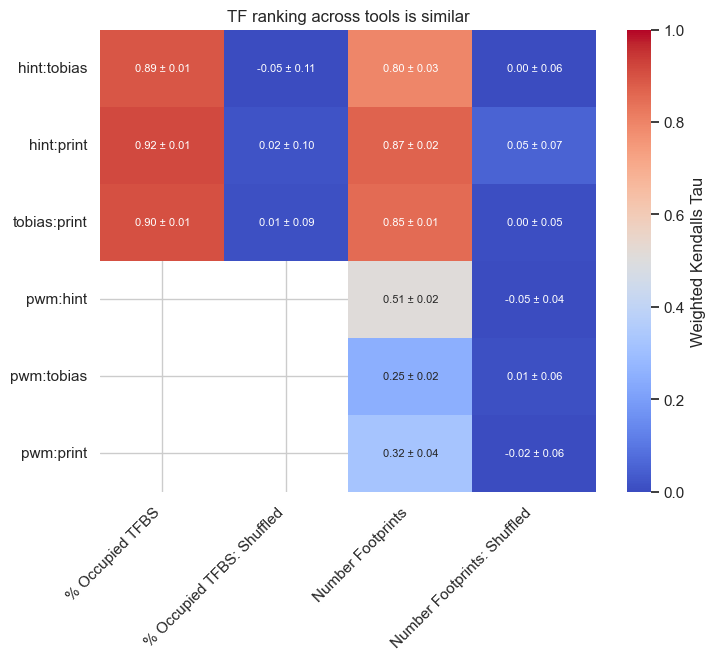

In [5]:
toplot = tau_df_grouped.pivot(index='tools', columns='comparison', values='mean')
labels = tau_df_grouped.pivot(index='tools', columns='comparison', values='labels')

ylabel_order = ['hint:tobias', 'hint:print', 'tobias:print', 'pwm:hint', 'pwm:tobias', 'pwm:print']

plt.figure(figsize=(8, 6))
sns.heatmap(toplot.loc[ylabel_order],
            annot = labels.loc[ylabel_order], 
            fmt = '', annot_kws={"size": 8},
            vmin=0, vmax=1,
            cmap="coolwarm", cbar_kws={"label": "Weighted Kendalls Tau"})
plt.ylabel(""); plt.xlabel("")
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0) 
plt.title("TF ranking across tools is similar")
plt.show()

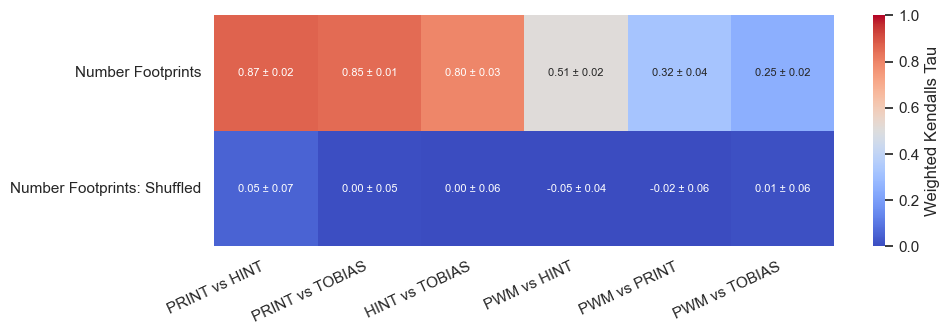

In [6]:
toplot = tau_df_grouped[tau_df_grouped.comparison.isin(["Number Footprints", "Number Footprints: Shuffled"])].pivot(index='comparison', columns='tools', values='mean')
labels = tau_df_grouped[tau_df_grouped.comparison.isin(["Number Footprints", "Number Footprints: Shuffled"])].pivot(index='comparison', columns='tools', values='labels')


xlabel_order = ['hint:print', 'tobias:print', 'hint:tobias', 'pwm:hint', 'pwm:print', 'pwm:tobias']
xlabel_pretty = ['PRINT vs HINT', 'PRINT vs TOBIAS', 'HINT vs TOBIAS', 'PWM vs HINT', 'PWM vs PRINT', 'PWM vs TOBIAS']


plt.figure(figsize=(10, 3))
sns.heatmap(toplot[xlabel_order],
            annot = labels[xlabel_order], 
            xticklabels=xlabel_pretty,
            fmt = '', annot_kws={"size": 8},
            vmin=0, vmax=1,
            cmap="coolwarm", cbar_kws={"label": "Weighted Kendalls Tau"})
plt.ylabel(""); plt.xlabel("")
plt.xticks(rotation=25, ha='right'); plt.yticks(rotation=0) 

plt.show()



In [7]:
def _KT_AcrossCellLines(df, 
                        cell_lines = ["HEPG2", "MCF7", "K562", "SKNSH"], 
                        tools = ["pwm", "hint","tobias", "print"],
                        rankby="#footprints"):
    
    from scipy.stats import kendalltau, weightedtau
    
    results=list()
    for t in tools:
        for cl1, cl2 in list(combinations(cell_lines, 2)):
            sorted_motifs_list1=df.loc[(df.cell_line == cl1) & (df.tool==t)].sort_values(by=rankby, ascending=False).index
            sorted_motifs_list2=df.loc[(df.cell_line == cl2) & (df.tool==t)].sort_values(by=rankby, ascending=False).index
            
            rank_map = {char: rank for rank, char in enumerate(sorted_motifs_list1)}
            ranked_motifs_list1 = [rank_map[char] for char in sorted_motifs_list1]
            ranked_motifs_list2 = [rank_map[char] for char in sorted_motifs_list2]

            kt_cor, pval = kendalltau(ranked_motifs_list1, ranked_motifs_list2) #identical to weightedtau(ranked_list1, ranked_list2, weigher=lambda x: 1)
            wkt_cor = weightedtau(ranked_motifs_list1, ranked_motifs_list2)
            results.append([t, cl1, cl2, kt_cor, wkt_cor.statistic])

    tau_df = pd.DataFrame(results, columns = ['tool', 'cell_line1', 'cell_line2', 'kendall_tau', 'kendall_tau_weighted']) 
    tau_df["cell_lines"] = tau_df['cell_line1'] + ":" + tau_df['cell_line2']
    return tau_df

tmp1 = _KT_AcrossCellLines(genome_wide_PWM, rankby="#footprints")
tmp1["comparison"] = "Number Footprints"

tmp2 = _KT_AcrossCellLines(genome_wide_PWM, rankby="#footprints_shuffled")
tmp2["comparison"] = "Number Footprints: Shuffled"

tmp3 = _KT_AcrossCellLines(genome_wide_PWM, 
                       tools=["hint","tobias","print"], 
                       rankby="pct_occupied")
tmp3["comparison"] = "% Occupied TFBS"

tmp4 = _KT_AcrossCellLines(genome_wide_PWM, 
                       tools=["hint","tobias","print"], 
                       rankby="pct_occupied_shuffled")
tmp4["comparison"] = "% Occupied TFBS: Shuffled"

tau_df = pd.concat([tmp1, tmp2, tmp3, tmp4])
tau_df_grouped = pd.DataFrame({'mean' : tau_df.groupby(["tool", "comparison"])['kendall_tau_weighted'].mean(),
                               'sd'   : tau_df.groupby(["tool", "comparison"])['kendall_tau_weighted'].std()}).reset_index()
tau_df_grouped["labels"] = tau_df_grouped.apply(lambda row: f"{row['mean']:.2f} ± {row['sd']:.2f}", axis=1)

display(tau_df_grouped)

,tool,comparison,mean,sd,labels
0,hint,% Occupied TFBS,0.960049,0.005542,0.96 ± 0.01
1,hint,% Occupied TFBS: Shuffled,0.021494,0.052175,0.02 ± 0.05
2,hint,Number Footprints,0.927837,0.016577,0.93 ± 0.02
3,hint,Number Footprints: Shuffled,-0.030972,0.073692,-0.03 ± 0.07
4,print,% Occupied TFBS,0.935618,0.009198,0.94 ± 0.01
5,print,% Occupied TFBS: Shuffled,0.018770,0.096092,0.02 ± 0.10
6,print,Number Footprints,0.915969,0.010867,0.92 ± 0.01
7,print,Number Footprints: Shuffled,0.022928,0.048757,0.02 ± 0.05
8,pwm,Number Footprints,0.980264,0.005899,0.98 ± 0.01
9,pwm,Number Footprints: Shuffled,-0.072041,0.058203,-0.07 ± 0.06


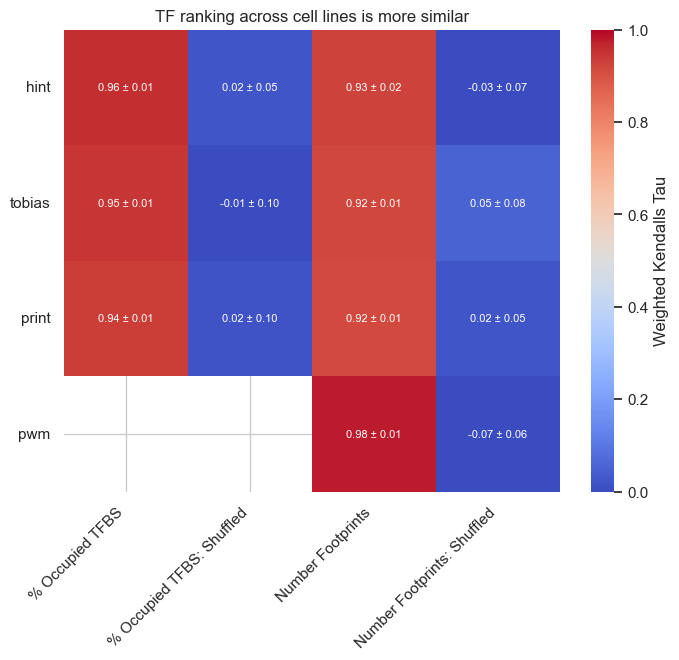

In [8]:
toplot = tau_df_grouped.pivot(index='tool', columns='comparison', values='mean')
labels = tau_df_grouped.pivot(index='tool', columns='comparison', values='labels')

ylabel_order = ["hint","tobias", "print", "pwm"]

plt.figure(figsize=(8, 6))
sns.heatmap(toplot.loc[ylabel_order],
            annot = labels.loc[ylabel_order], 
            fmt = '', annot_kws={"size": 8},
            vmin=0, vmax=1,
            cmap="coolwarm", cbar_kws={"label": "Weighted Kendalls Tau"})
plt.ylabel(""); plt.xlabel("")
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0) 
plt.title("TF ranking across cell lines is more similar")
plt.show()

### This means that tools are more similar across biological contexts instead? Should this be worrisome? How similar are the bams to begin with? 

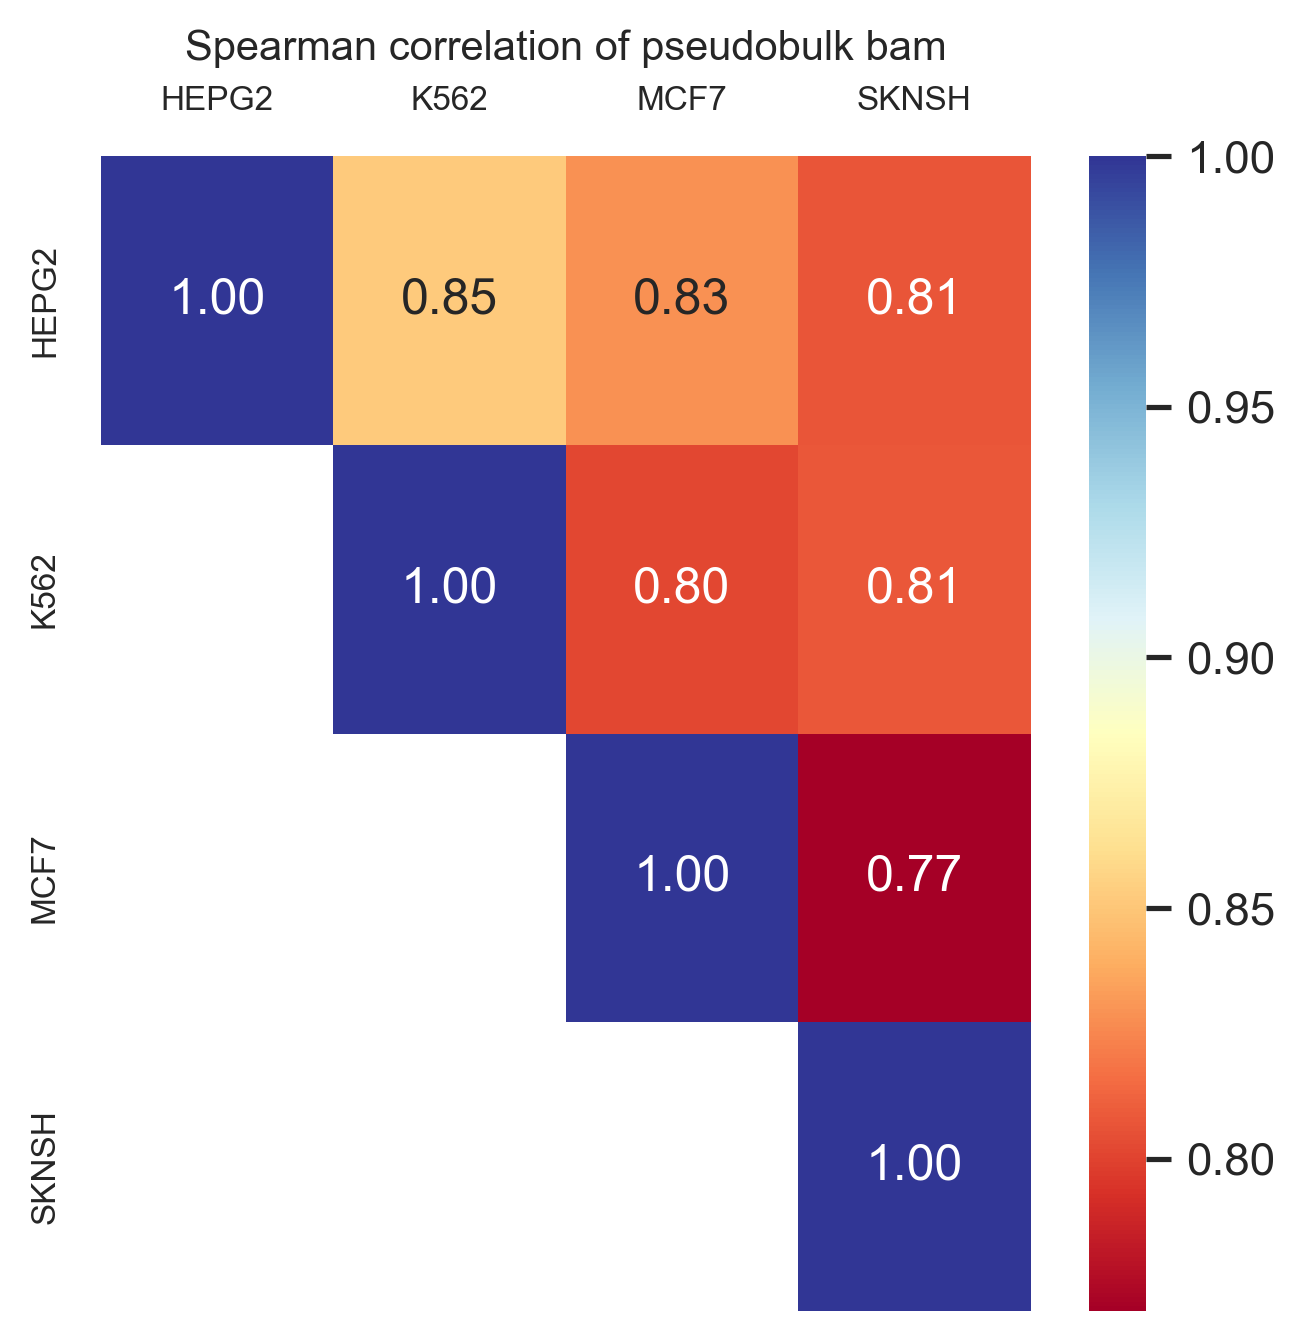

In [174]:
cormat = pd.read_csv("deeptools_spearman_cormat.txt", sep="\t", comment="#", index_col=0)
cormat.index = [ i.replace("'", "") for i in cormat.index ]
cormat.columns = [ i.replace("'", "") for i in cormat.columns ]
mask = np.triu(np.ones_like(cormat, dtype=bool))

sns.set(font_scale=1, style='white')
fig = plt.figure(figsize=(5,5))
gs = GridSpec(1, 1, figure=fig, wspace=0.25, hspace=0.45)

ax = fig.add_subplot(gs[0])
sns.heatmap(cormat, mask=~mask, annot=True, fmt=".2f", cmap="RdYlBu", ax=ax)
ax.set_title("Spearman correlation of pseudobulk bam", fontsize=10)
plt.tick_params(axis='both', which='major', labelsize=8, 
                labelbottom = False, bottom=False, top = False, labeltop=True)
plt.show()



## 5.2.2 include motif enrichment <a class="anchor" id="fifth22-bullet"></a>

In [9]:
##WHAT ABOUT MOTIF ENRICHMENT

def _formatEnrichment(value_column = '# of Target Sequences with Motif'):
    allcolnames = ['Motif Name', 'Consensus', 'P-value', 'Log P-value',
                   'q-value (Benjamini)', '# of Target Sequences with Motif',
                   '% of Target Sequences with Motif',
                   '# of Background Sequences with Motif',
                   '% of Background Sequences with Motif', 
                   "NumForegroundSeq", "NumBackgroundSeq"]
    
    df_list = list()
    for cl in ["HEPG2", "MCF7", "K562", "SKNSH"]:
        df = pd.read_table(f"../09_simPWMs/03_enrichment/{cl}/gc_corrected/jaspar/knownResults.txt")
        
        match = re.search(r"\(of (\d+)\)", df.columns[5])
        df["NumForegroundSeq"] = int(match.group(1))
        
        match = re.search(r"\(of (\d+)\)", df.columns[7])
        df["NumBackgroundSeq"] = int(match.group(1))
        
        df.columns = allcolnames
        df["cell_line"] = cl    
        df_list.append(df)
    
        
    df = pd.concat(df_list)
    df['% of Target Sequences with Motif'] = [i[:-1] for i in df['% of Target Sequences with Motif']]
    df['% of Background Sequences with Motif'] = [i[:-1] for i in df['% of Background Sequences with Motif']]
    
    num_cols = ['P-value', 'Log P-value',
           'q-value (Benjamini)', '# of Target Sequences with Motif',
           '% of Target Sequences with Motif',
           '# of Background Sequences with Motif',
           '% of Background Sequences with Motif', 'NumForegroundSeq',
           'NumBackgroundSeq']
    
    df[num_cols] = df[num_cols].apply(pd.to_numeric)
    
    df[['motif', 'TF']] = df["Motif Name"].str.split(':::', expand=True)
    df['motif'] = df['motif'].str.upper()
    df['TF'] = df['TF'].str.upper()
    df["motif_name"] = df["TF"] + "_" + df["motif"]
    df["tool"] = "homer"
    
    if value_column == 'Log P-value':
        df["value"] = 1 - df['Log P-value']
        value_column = "value"
        
    tmp = df[["motif_name", "cell_line", "tool",  value_column]].copy()
    tmp.columns = ["motif", "cell_line", "tool",  "value"]
    return tmp

#'# of Target Sequences with Motif'  low=bad so ascending = False
#'P-value'  low=good so ascending = True
# why you added a 1- flag in the code above. 

In [10]:
df = _formatEnrichment(value_column = 'Log P-value')

genome_wide_PWM = pd.read_csv("baseline_pwmdf.csv", index_col=0)
genome_wide_PWM.columns = ["motif", "value", "tool", "cell_line"]

final_df = pd.concat([df, genome_wide_PWM], axis=0)

#create random shuffle of value
final_df['value_shuffled'] = (
    final_df.groupby(["tool", "cell_line"])['value']
      .transform(lambda x: np.random.permutation(x.values))
)

final_df.index = final_df.motif
display(final_df)

,motif,cell_line,tool,value,value_shuffled
motif,,,,,
CTCF_MA0139.1,CTCF_MA0139.1,HEPG2,homer,23811.0,2.860
CTCF_MA1929.1,CTCF_MA1929.1,HEPG2,homer,9896.0,8.928
CTCF_MA1930.1,CTCF_MA1930.1,HEPG2,homer,8987.0,1059.000
FOS::JUND_MA1141.1,FOS::JUND_MA1141.1,HEPG2,homer,4819.0,10.419
FOS::JUNB_MA1134.1,FOS::JUNB_MA1134.1,HEPG2,homer,4789.0,6.553
...,...,...,...,...,...
ZSCAN31_MA1722.1,ZSCAN31_MA1722.1,SKNSH,pwm,5085.0,729705.000
REST_MA0138.2,REST_MA0138.2,SKNSH,pwm,50388.0,832187.000
RREB1_MA0073.1,RREB1_MA0073.1,SKNSH,pwm,552041.0,495280.000


In [11]:
tmp1 = _KT_AcrossTools(final_df, 
                       tools = ["pwm", "hint","tobias", "print", "homer"],
                       rankby="value")
tmp1["comparison"] = "Metric"

tmp2 = _KT_AcrossTools(final_df, 
                       tools = ["pwm", "hint","tobias", "print", "homer"],
                       rankby="value_shuffled")
tmp2["comparison"] = "Metric: Shuffled"

tau_df = pd.concat([tmp1, tmp2])
tau_df_grouped = pd.DataFrame({'mean' : tau_df.groupby(["tools", "comparison"])['kendall_tau_weighted'].mean(),
                               'sd'   : tau_df.groupby(["tools", "comparison"])['kendall_tau_weighted'].std()}).reset_index()
tau_df_grouped["labels"] = tau_df_grouped.apply(lambda row: f"{row['mean']:.2f} ± {row['sd']:.2f}", axis=1)

display(tau_df_grouped)


,tools,comparison,mean,sd,labels
0,hint:homer,Metric,0.275635,0.135178,0.28 ± 0.14
1,hint:homer,Metric: Shuffled,-0.045890,0.066452,-0.05 ± 0.07
2,hint:print,Metric,0.868963,0.020261,0.87 ± 0.02
3,hint:print,Metric: Shuffled,-0.004444,0.096395,-0.00 ± 0.10
4,hint:tobias,Metric,0.795347,0.031558,0.80 ± 0.03
5,hint:tobias,Metric: Shuffled,-0.027518,0.079235,-0.03 ± 0.08
6,print:homer,Metric,0.359612,0.101764,0.36 ± 0.10
7,print:homer,Metric: Shuffled,0.036879,0.082877,0.04 ± 0.08
8,pwm:hint,Metric,0.509431,0.023718,0.51 ± 0.02
9,pwm:hint,Metric: Shuffled,0.025973,0.024132,0.03 ± 0.02


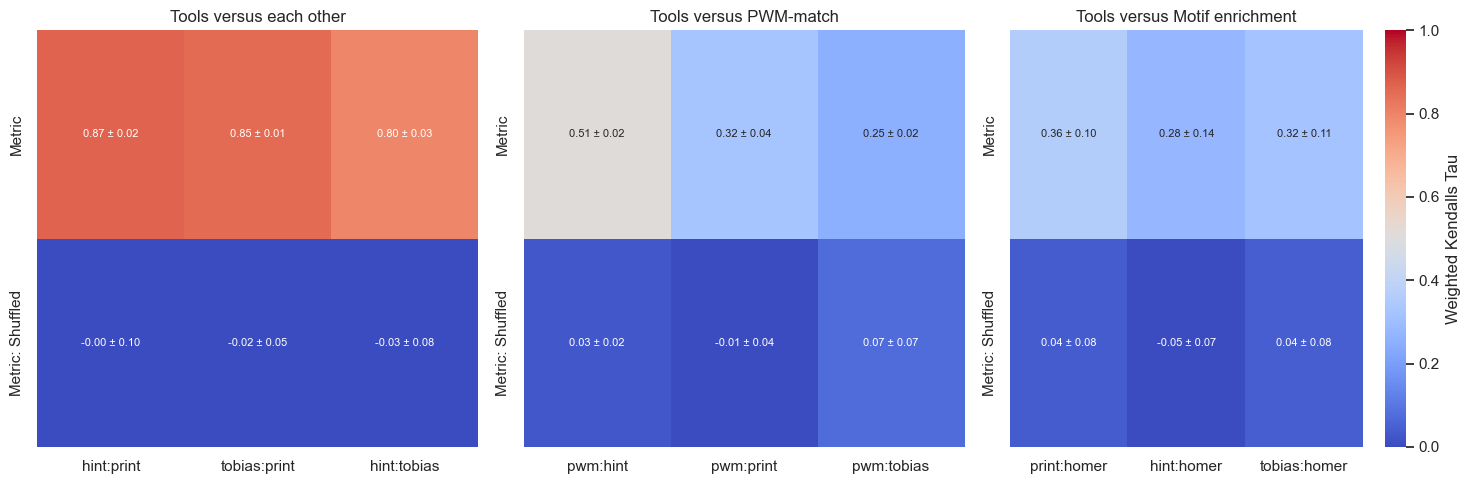

In [12]:
toplot = tau_df_grouped.pivot(index='comparison', columns='tools', values='mean')
labels = tau_df_grouped.pivot(index='comparison', columns='tools', values='labels')


fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 1 row, 3 columns

vals = ['hint:print', 'tobias:print', 'hint:tobias']
sns.heatmap(toplot[vals],
            annot = labels[vals], annot_kws={"size": 8}, fmt='',
            ax=axes[0], 
            cbar=False, cmap="coolwarm",
            vmin=0, vmax=1)
axes[0].set_title('Tools versus each other')
axes[0].set_ylabel(""); axes[0].set_xlabel("")

vals = ['pwm:hint', 'pwm:print', 'pwm:tobias']
sns.heatmap(toplot[vals], 
            annot = labels[vals], annot_kws={"size": 8}, fmt='',
            ax=axes[1], 
            cbar=False, cmap="coolwarm",
            vmin=0, vmax=1)
axes[1].set_title('Tools versus PWM-match')
axes[1].set_ylabel(""); axes[1].set_xlabel("")

vals = ['print:homer', 'hint:homer', 'tobias:homer']
sns.heatmap(toplot[vals], 
            annot = labels[vals], annot_kws={"size": 8}, fmt='',
            ax=axes[2], 
            cbar=True, cmap="coolwarm", cbar_kws={"label": "Weighted Kendalls Tau"},
            vmin=0, vmax=1)
axes[2].set_title('Tools versus Motif enrichment')
axes[2].set_ylabel(""); axes[2].set_xlabel("")

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
gray_to_blue = LinearSegmentedColormap.from_list("gray_blue", ["gray", "blue"])

palette = sns.color_palette(gray_to_blue(np.linspace(0, 1, 10)))


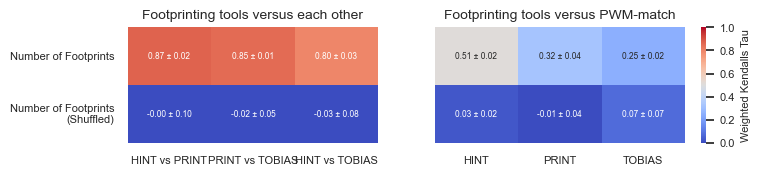

In [64]:
from matplotlib.colors import LinearSegmentedColormap
toplot = tau_df_grouped.pivot(index='comparison', columns='tools', values='mean')
labels = tau_df_grouped.pivot(index='comparison', columns='tools', values='labels')

fig, axes = plt.subplots(1, 2, figsize=(8, 1.5), width_ratios=(4,5))  

vals = ['hint:print', 'tobias:print', 'hint:tobias']
pal = "coolwarm"

sns.heatmap(toplot[vals],
            annot = labels[vals], annot_kws={"size": 6}, fmt='',
            ax=axes[0], 
            cbar=False, cmap=pal,
            vmin=0, vmax=1)

vals = ['pwm:hint', 'pwm:print', 'pwm:tobias']
g = sns.heatmap(toplot[vals], 
            annot = labels[vals], annot_kws={"size": 6}, fmt='',
            ax=axes[1], 
            cbar=True, cmap=pal,
            vmin=0, vmax=1)

axes[0].set_title('Footprinting tools versus each other', fontsize=10)
axes[1].set_title('Footprinting tools versus PWM-match', fontsize=10)
axes[0].set_xticklabels(['HINT vs PRINT', 'PRINT vs TOBIAS', 'HINT vs TOBIAS'], fontsize=8)
axes[1].set_xticklabels(['HINT', 'PRINT', 'TOBIAS'], rotation=0, fontsize=8)

axes[0].set_ylabel(""); axes[0].set_xlabel("")
axes[1].set_ylabel(""); axes[1].set_xlabel("")

axes[0].set_yticklabels(["Number of Footprints", "Number of Footprints\n(Shuffled)"], rotation=0, fontsize=8)
axes[1].set_yticklabels("")

colorbar = g.collections[0].colorbar
colorbar.ax.tick_params(labelsize=8)
colorbar.ax.set_ylabel(ylabel = "Weighted Kendalls Tau", fontsize=8)

plt.show()

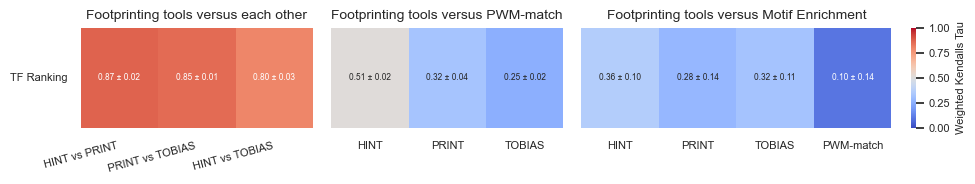

In [74]:
toplot = tau_df_grouped.pivot(index='comparison', columns='tools', values='mean')
labels = tau_df_grouped.pivot(index='comparison', columns='tools', values='labels')
toplot = toplot.loc[["Metric"]]
labels = labels .loc[["Metric"]]

fig, axes = plt.subplots(1, 3, figsize=(10, 2), width_ratios=(3,3,5))  

vals = ['hint:print', 'tobias:print', 'hint:tobias']
sns.heatmap(toplot[vals],
            annot = labels[vals], annot_kws={"size": 6}, fmt='',
            ax=axes[0], 
            cbar=False, cmap="coolwarm",
            vmin=0, vmax=1)

vals = ['pwm:hint', 'pwm:print', 'pwm:tobias']
sns.heatmap(toplot[vals], 
            annot = labels[vals], annot_kws={"size": 6}, fmt='',
            ax=axes[1], 
            cbar=False, cmap="coolwarm",
            vmin=0, vmax=1)


vals = ['print:homer', 'hint:homer', 'tobias:homer', 'pwm:homer']
g= sns.heatmap(toplot[vals], 
            annot = labels[vals], annot_kws={"size": 6}, fmt='',
            ax=axes[2], 
            cbar=True, cmap="coolwarm",
            vmin=0, vmax=1)


axes[0].set_ylabel(""); axes[0].set_xlabel("")
axes[1].set_ylabel(""); axes[1].set_xlabel("")
axes[2].set_ylabel(""); axes[2].set_xlabel("")

axes[0].set_title('Footprinting tools versus each other', fontsize=10)
axes[1].set_title('Footprinting tools versus PWM-match', fontsize=10)
axes[2].set_title('Footprinting tools versus Motif Enrichment', fontsize=10)

axes[0].set_yticklabels(["TF Ranking"], rotation=0, fontsize=8)
axes[1].set_yticklabels("")
axes[2].set_yticklabels("")

axes[0].set_xticklabels(['HINT vs PRINT', 'PRINT vs TOBIAS', 'HINT vs TOBIAS'], rotation=15, ha="right", fontsize=8)
axes[1].set_xticklabels(['HINT', 'PRINT', 'TOBIAS'], rotation=0, fontsize=8)
axes[2].set_xticklabels(['HINT', 'PRINT', 'TOBIAS', "PWM-match"], rotation=0, fontsize=8)

colorbar = g.collections[0].colorbar
colorbar.ax.tick_params(labelsize=8)
colorbar.ax.set_ylabel(ylabel = "Weighted Kendalls Tau", fontsize=8)

plt.tight_layout()
plt.show()

## 5.3 across downsampling <a class="anchor" id="fifth3-bullet"></a>

In [245]:
def process_chunk(file, _):
    tmp = pd.read_csv(file, index_col=0) #have to be in same column order already
    column_sums = tmp.sum(axis=0).to_dict()
    column_sums["file"] = re.sub('-cellFilt|.mat','', os.path.basename(file))
    return column_sums
    

import multiprocessing as mp

def main():
    for tool in ["tobias", "print", "hint"]:
        print(tool)
        mat_dir = f"../06_dataquality/{tool}/mats/"
        all_mats = [(f"{mat_dir}{x}", 1) for x in os.listdir(mat_dir) if x.endswith(".mat")]
    
        with mp.Pool(processes=20) as pool:
            results = pool.starmap(process_chunk, all_mats)

        df = pd.DataFrame(results)
        df.set_index("file", inplace=True)
        df = df.T
        df.to_csv(f"{tool}_PWM_sums_all.csv")
        
#main()

In [ ]:
#we have sums per file. We want mean per condition
#save that for each tool: cellline in a dictionary. 
#then make a relative dictionary that is those df divided by the number of TFBS. 

In [175]:
def quick(tool):
    df = pd.read_csv(f"../08_acrosstools/{tool}_PWM_sums_all.csv", index_col=0) 
    df["motif"] = df.index
    melted_df = pd.melt(df, id_vars=['motif'], var_name='file', value_name='NumFoot')
    melted_df[['cell_line', 'cond', 'rep']] = melted_df['file'].str.split('_', expand=True)
    tmp = pd.DataFrame(melted_df.groupby(["motif", "cell_line","cond"])["NumFoot"].mean())
    tmp.columns = [tool]
    return tmp
    
df1 = pd.concat([quick("hint"), quick("tobias"), quick("print")], axis=1, join='outer')
df1 = df1.reset_index()
df1 = df1[df1["cell_line"] != "GM12878"]


dd = "../06_dataquality/pwm/mats"
pwm_dict = {"HEPG2": pd.read_csv(f"{dd}/HEPG2-cellFilt.mat", index_col=0).sum(axis=0).to_dict(),
            "K562": pd.read_csv(f"{dd}/K562-cellFilt.mat", index_col=0).sum(axis=0).to_dict(),
            "MCF7": pd.read_csv(f"{dd}/MCF7-cellFilt.mat", index_col=0).sum(axis=0).to_dict(),
            "SKNSH": pd.read_csv(f"{dd}/SKNSH-cellFilt.mat", index_col=0).sum(axis=0).to_dict()}

tmp = pd.DataFrame(pwm_dict)
tmp["motif"] = tmp.index
pwm_df = pd.melt(tmp, id_vars=['motif'], var_name='cell_line', value_name='pwm')

df = df1.merge(pwm_df, on=["motif", "cell_line"])
display(df)

,motif,cell_line,cond,hint,tobias,print,pwm
0,AHR::ARNT_MA0006.1,HEPG2,c1000,6364.333333,21462.666667,519.666667,749324
1,AHR::ARNT_MA0006.1,HEPG2,c10000,8790.666667,6056.333333,2598.333333,749324
2,AHR::ARNT_MA0006.1,HEPG2,c20000,8494.333333,6456.333333,3309.666667,749324
3,AHR::ARNT_MA0006.1,HEPG2,c2500,7710.333333,19709.666667,1223.000000,749324
4,AHR::ARNT_MA0006.1,HEPG2,c5000,8484.333333,16320.000000,1894.333333,749324
...,...,...,...,...,...,...,...
72321,ZSCAN4_MA1155.1,SKNSH,r1e7,8481.000000,21393.000000,103.666667,35459
72322,ZSCAN4_MA1155.1,SKNSH,r1e8,15654.333333,5251.333333,1036.333333,35459
72323,ZSCAN4_MA1155.1,SKNSH,r5e6,6398.000000,16811.333333,28.666667,35459
72324,ZSCAN4_MA1155.1,SKNSH,r5e7,13549.333333,18168.666667,655.666667,35459


In [375]:
#### ONLY IF YOU WANT RELATIVE VALUES
df[["hint", "tobias", "print"]] = df[["hint", "tobias", "print"]].div(df["pwm"], axis=0)
display(df)

,motif,cell_line,cond,hint,tobias,print,pwm
0,AHR::ARNT_MA0006.1,HEPG2,c1000,0.008493,0.028643,0.000694,749324
1,AHR::ARNT_MA0006.1,HEPG2,c10000,0.011731,0.008082,0.003468,749324
2,AHR::ARNT_MA0006.1,HEPG2,c20000,0.011336,0.008616,0.004417,749324
3,AHR::ARNT_MA0006.1,HEPG2,c2500,0.010290,0.026303,0.001632,749324
4,AHR::ARNT_MA0006.1,HEPG2,c5000,0.011323,0.021780,0.002528,749324
...,...,...,...,...,...,...,...
72321,ZSCAN4_MA1155.1,SKNSH,r1e7,0.239178,0.603317,0.002924,35459
72322,ZSCAN4_MA1155.1,SKNSH,r1e8,0.441477,0.148096,0.029226,35459
72323,ZSCAN4_MA1155.1,SKNSH,r5e6,0.180434,0.474106,0.000808,35459
72324,ZSCAN4_MA1155.1,SKNSH,r5e7,0.382113,0.512385,0.018491,35459


In [376]:
from scipy.stats import kendalltau, weightedtau

def _kendalltau(group):
    res = {}
    for t1, t2 in [["hint","tobias"], ["hint","print"], ["tobias", "print"]]:
        sorted_motifs_list1=group.sort_values(by=t1, ascending=False).motif
        sorted_motifs_list2=group.sort_values(by=t2, ascending=False).motif

        rank_map = {char: rank for rank, char in enumerate(sorted_motifs_list1)}
        ranked_motifs_list1 = [rank_map[char] for char in sorted_motifs_list1]
        ranked_motifs_list2 = [rank_map[char] for char in sorted_motifs_list2]

        kt_cor, pval = kendalltau(ranked_motifs_list1, ranked_motifs_list2) #identical to weightedtau(ranked_list1, ranked_list2, weigher=lambda x: 1)
        wkt_cor = weightedtau(ranked_motifs_list1, ranked_motifs_list2)
        res[f"{t1}:{t2}"] = [kt_cor, wkt_cor.statistic]
    return res

tmp = df.groupby(["cell_line", "cond"]).apply(_kendalltau, include_groups=False).apply(pd.Series)
tmp = tmp.reset_index()

tmp2 = pd.melt(tmp, id_vars=['cell_line', 'cond'], var_name='tools', value_name='list')

kt_df = pd.concat([tmp2.drop(columns=["list"]), tmp2['list'].apply(pd.Series)], ignore_index=True, axis=1)
kt_df.columns = ["cell_line", "cond", "tools", "kendall_tau", "weighted_kendalls_tau"]
display(kt_df)

,cell_line,cond,tools,kendall_tau,weighted_kendalls_tau
0,HEPG2,c1000,hint:tobias,0.822530,0.926051
1,HEPG2,c10000,hint:tobias,0.768705,0.902539
2,HEPG2,c20000,hint:tobias,0.772906,0.904446
3,HEPG2,c2500,hint:tobias,0.818442,0.924381
4,HEPG2,c5000,hint:tobias,0.814648,0.923111
...,...,...,...,...,...
253,SKNSH,r1e7,tobias:print,0.715537,0.867106
254,SKNSH,r1e8,tobias:print,0.840864,0.915697
255,SKNSH,r5e6,tobias:print,0.713029,0.862158
256,SKNSH,r5e7,tobias:print,0.798981,0.901918


In [377]:
kt_df_grouped = pd.DataFrame({'mean' : kt_df.groupby(["cond", "tools"])['weighted_kendalls_tau'].mean(),
                               'sd'  : kt_df.groupby(["cond", "tools"])['weighted_kendalls_tau'].std()}).reset_index()
kt_df_grouped["labels"] = kt_df_grouped.apply(lambda row: f"{row['mean']:.2f} ± {row['sd']:.2f}", axis=1)
display(kt_df_grouped)

,cond,tools,mean,sd,labels
0,c1000,hint:print,0.843341,0.021211,0.84 ± 0.02
1,c1000,hint:tobias,0.919085,0.006917,0.92 ± 0.01
2,c1000,tobias:print,0.858532,0.012643,0.86 ± 0.01
3,c10000,hint:print,0.891966,0.014340,0.89 ± 0.01
4,c10000,hint:tobias,0.885547,0.016056,0.89 ± 0.02
...,...,...,...,...,...
64,r5e7,hint:tobias,0.916213,0.010727,0.92 ± 0.01
65,r5e7,tobias:print,0.886592,0.020033,0.89 ± 0.02
66,r5e8,hint:print,0.903062,0.010024,0.90 ± 0.01
67,r5e8,hint:tobias,0.891392,0.012721,0.89 ± 0.01


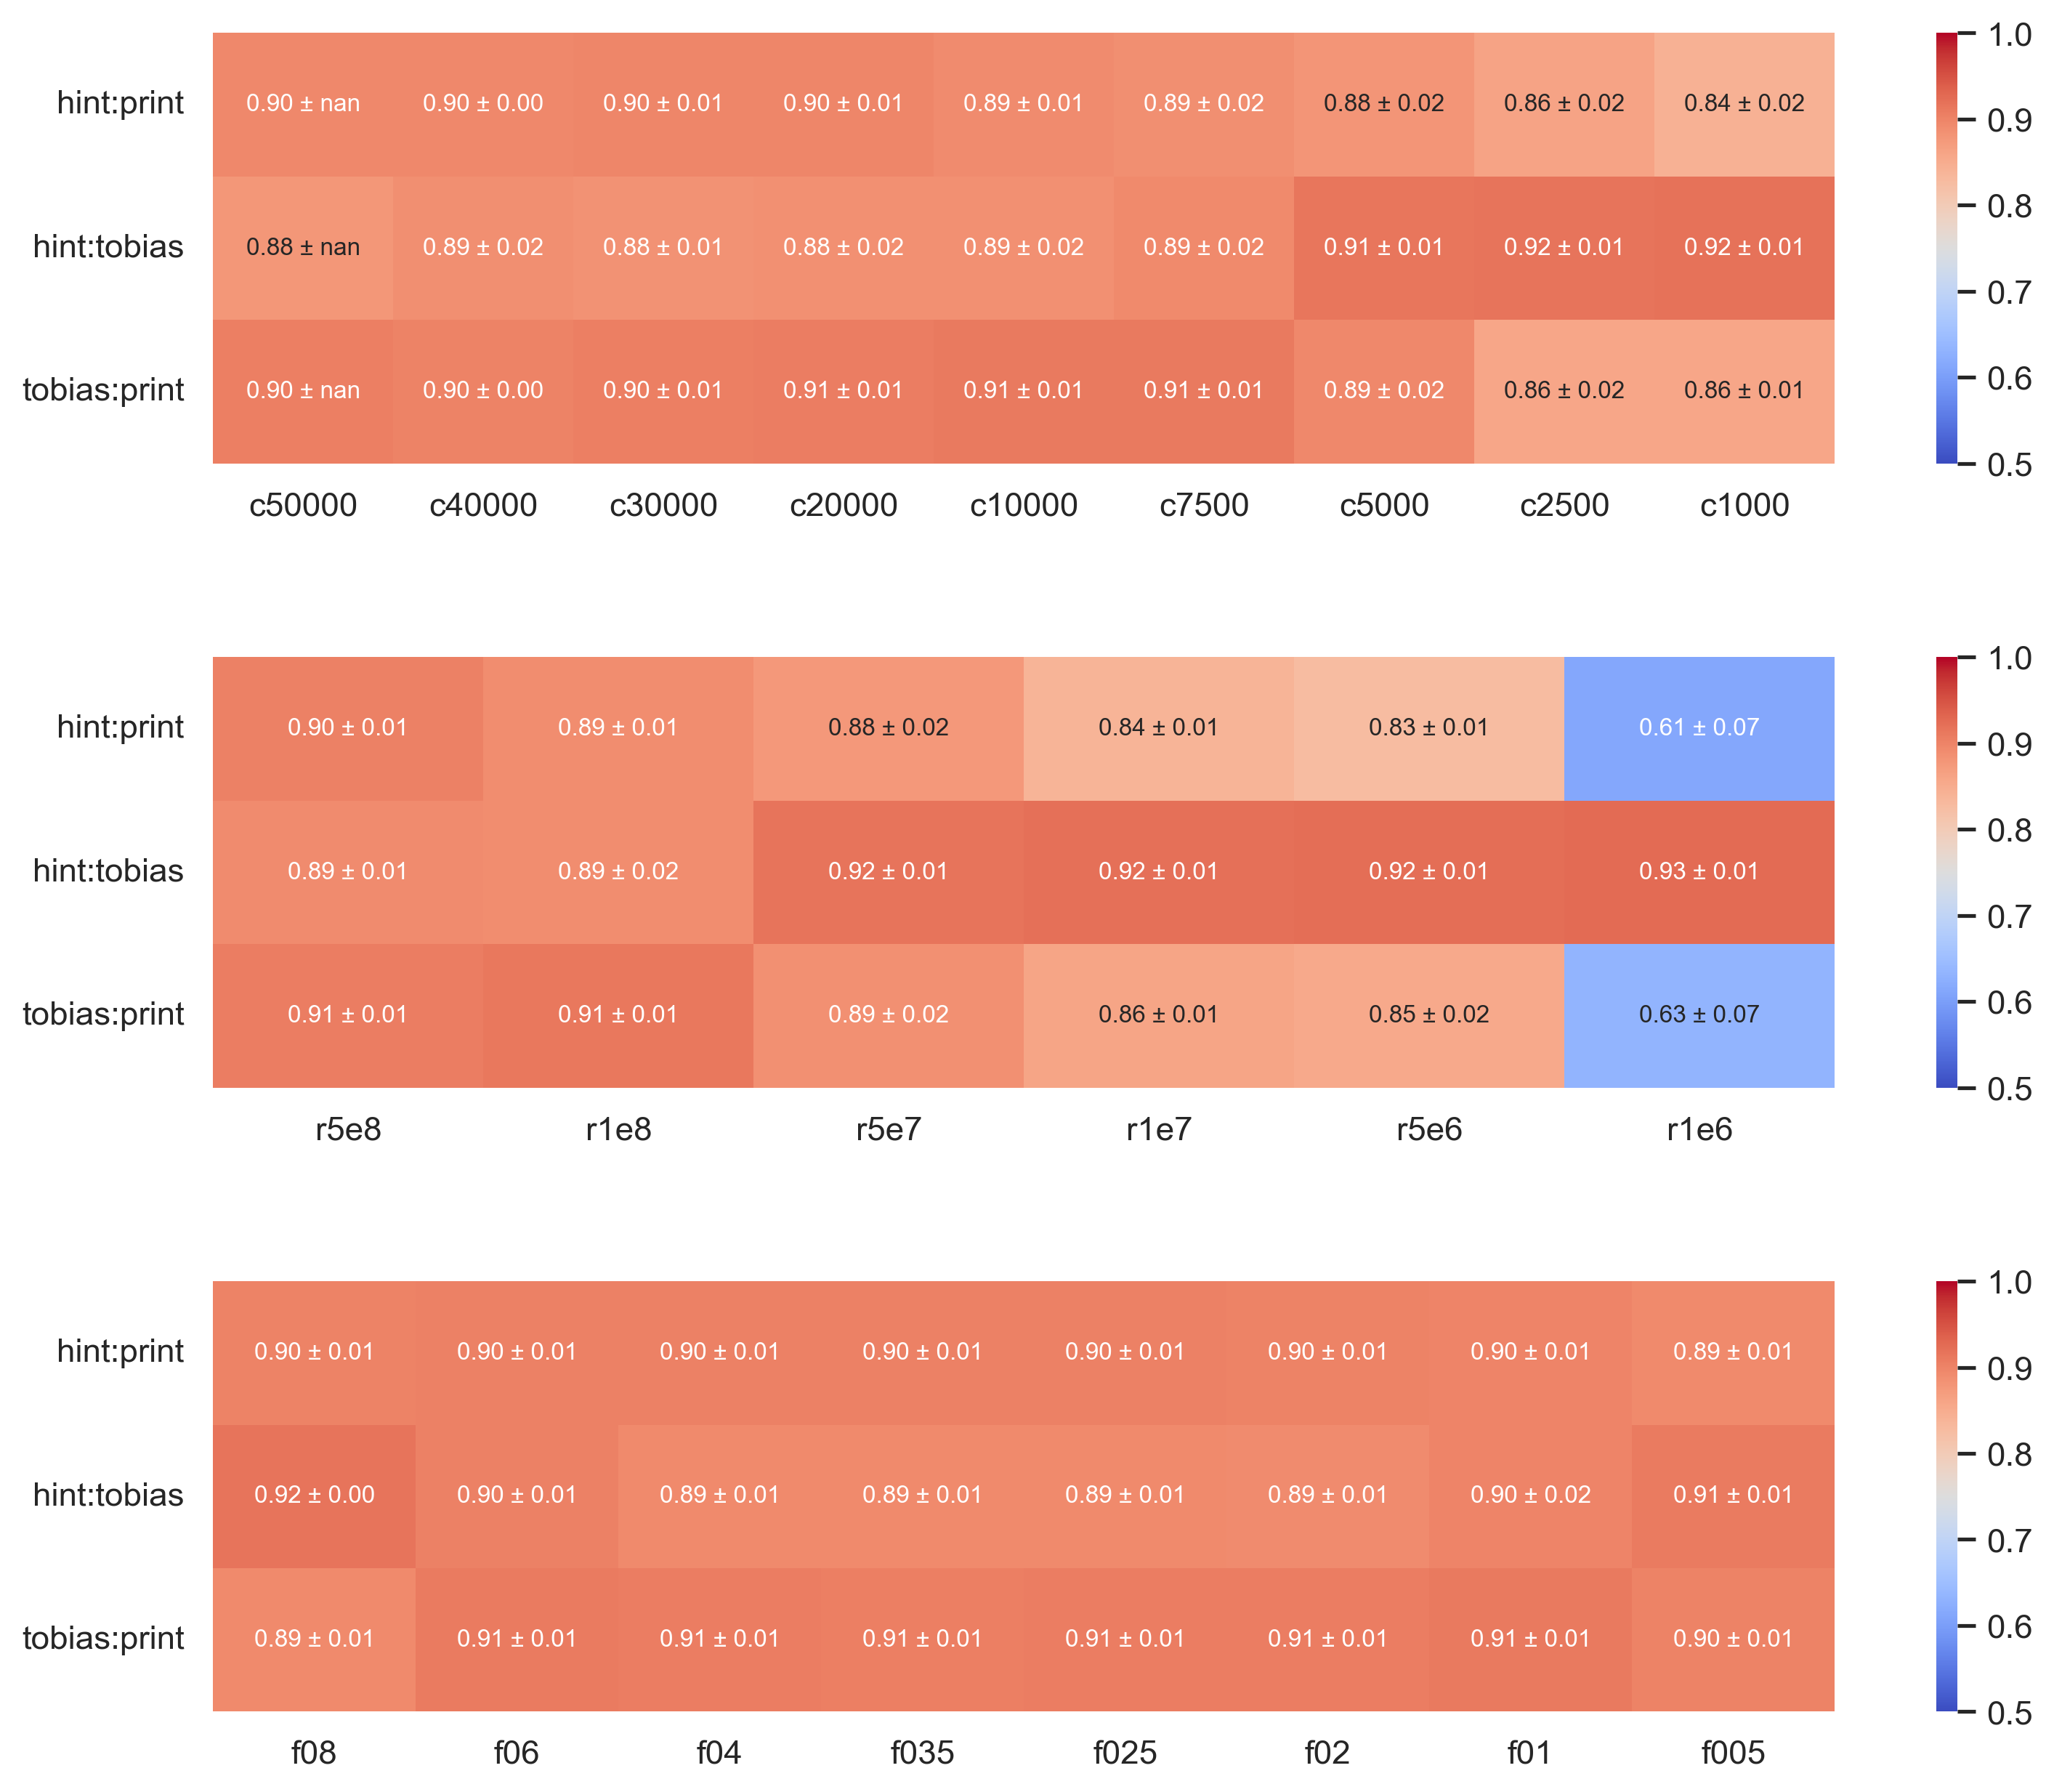

In [378]:
sns.set(font_scale=1, style='white')
fig = plt.figure(figsize=(12,10))
gs = GridSpec(3, 1, figure=fig, wspace=0.25, hspace=0.45)

toplot = kt_df_grouped.pivot(index='tools', columns='cond', values='mean')
labels = kt_df_grouped.pivot(index='tools', columns='cond', values='labels')

ax0 = fig.add_subplot(gs[0])
xlabel_order = ['c50000', 'c40000', 'c30000', 'c20000', 'c10000', 'c7500', 'c5000', 'c2500', 'c1000']
sns.heatmap(toplot[xlabel_order],
            annot = labels[xlabel_order], 
            fmt = '', 
            annot_kws={"size": 8},
            vmin=0.5, vmax=1,
            cmap="coolwarm", 
            #bar_kws={"label": "Weighted Kendalls Tau"},
            ax = ax0)

ax1 = fig.add_subplot(gs[1])
xlabel_order = ['r5e8', 'r1e8', 'r5e7', 'r1e7', 'r5e6', 'r1e6']
sns.heatmap(toplot[xlabel_order],
            annot = labels[xlabel_order], 
            fmt = '', 
            annot_kws={"size": 8},
            vmin=0.5, vmax=1,
            cmap="coolwarm", 
            #bar_kws={"label": "Weighted Kendalls Tau"},
            ax = ax1)

ax2 = fig.add_subplot(gs[2])
xlabel_order = ['f08', 'f06', 'f04', 'f035', 'f025', 'f02', 'f01', 'f005']
sns.heatmap(toplot[xlabel_order],
            annot = labels[xlabel_order], 
            fmt = '', 
            annot_kws={"size": 8},
            vmin=0.5, vmax=1,
            cmap="coolwarm", 
            #bar_kws={"label": "Weighted Kendalls Tau"},
            ax = ax2)

ax0.set_ylabel(""); ax1.set_ylabel(""); ax2.set_ylabel("");
ax0.set_xlabel(""); ax1.set_xlabel(""); ax2.set_xlabel("")
plt.show()


# 6. Properties of top PWMs <a class="anchor" id="sixth-bullet"></a>

In [ ]:
#make df with all the info of interest. 

#IC/GC content
pwm_metrics = pd.read_csv("../09_simPWMs/00_constructing_PWMs/jaspar2022_ICcontent.csv")
pwm_metrics[["base1", "base2"]] = pwm_metrics.TF.str.split('_', expand=True)

#USFs
usf = pd.read_csv("../05_footprinting/program_input_files/USF_list.csv", header=None)
usfs = usf[0].tolist()
pwm_metrics["USF"] = 0
pwm_metrics.loc[pwm_metrics.base1.isin(usfs), "USF"] = 1

#JASPAR CLUSTER
jaspar_clusters = pd.read_table("../05_footprinting/program_input_files/jaspar2022_motifs_to_clusters.txt", sep=" ", header=None, names=["motif","cluster"])
jaspar_clusters.columns = ["TF", "jaspar_cluster"]
pwm_metrics = pwm_metrics.merge(jaspar_clusters, on="TF", how="left")

#DNA BINDING DOMAIN
jaspar_dbd = pd.read_table("../05_footprinting/program_input_files/fixed.csv", sep=",", 
                               header=None, names=["motif_id", "tf", "tf1_class","tf2_class","tf1_family", "tf2_family"])
columns_to_convert = {"motif_id":str, "tf":str, "tf1_class":str,"tf1_family":str,"tf2_class":str, "tf2_family":str}
jaspar_dbd = jaspar_dbd.astype(columns_to_convert)
jaspar_dbd["tf"] = [x.upper() for x in jaspar_dbd["tf"].values] 
jaspar_dbd["TF"] = jaspar_dbd["tf"] + '_' + jaspar_dbd["motif_id"]
pwm_metrics = pwm_metrics.merge(jaspar_dbd, on="TF")
#pwm_metrics[pwm_metrics.isna().any(axis=1)]

#PRINT CATEGORIES
#TO ADD

pwm_metrics.drop(["base1", "base2"], inplace=True, axis=1)
print(pwm_metrics.shape)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr, pointbiserialr

results = []
allmetrics = ["GC_content", "Repeat_content", "IC", "len", "USF", "chr10_prevalence"]

for i, tool in enumerate(["hint", "tobias", "print"]):
    subset = mean_zscore_df_info[(mean_zscore_df_info["prog"] == tool) & (mean_zscore_df_info["sampling_type"] == "r")]
    for val in allmetrics:
        X = subset[[val]].values.flatten()
        Y = subset[['mean']].values.flatten()
        if val == 'USF': corr, p_value = pointbiserialr(X, Y)
        else: corr, p_value = pearsonr(X,Y)
        
        results.append([tool, val, corr, p_value])
    
# Show results
df_results = pd.DataFrame(results, columns=['Tool', 'Metric', "R", "pval"])
display(df_results.sort_values("R", ascending=False)[:15])

In [ ]:
res = {}
for i in ["HEPG2","K562", "MCF7", "SKNSH"]:
    f = f"../06_dataquality/pwm/mats/{i}-cellFilt.mat"
    pwm_mat = pd.read_table(f, sep=",", index_col=0)
    res[i] = pwm_mat.sum(axis=0)

peak_prevalence = pd.DataFrame.from_dict(res, orient='index').T
peak_prevalence["PWM_prevalence_mean"] = peak_prevalence.mean(axis=1)
peak_prevalence["PWM_prevalence_sd"] = peak_prevalence.std(axis=1)
display(peak_prevalence)

results = []
for tool in ["hint", "tobias", "print"]:
    tmp = zscore_dict[tool]
    subset = tmp[tmp["group"] == "r"]
    for cl, group in subset.groupby("cell_line"):
        subset_full = pd.merge(group, peak_prevalence[[cl]], left_on="TF", right_index=True, how='inner')
        corr, p_value = pearsonr(subset_full[[cl]].values.flatten(),
                                 subset_full[['mean']].values.flatten())
        
        results.append([tool, cl, corr, p_value])
    
# Show results
df_results = pd.DataFrame(results, columns=['Tool', 'cell_line', "R", "pval"])
display(df_results.sort_values("R", ascending=False)[:15])